In [1]:
# ============================================================
# Cell 1: Top-level imports + module reload
# ============================================================

import re
import gc
import json
import time
import random
import hashlib
import importlib
from dataclasses import asdict, is_dataclass
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import torch
except ImportError:
    torch = None

import config
import metrics
import model_loader
import modes
import workloads
import benchmark_modes
import reporter
import controller
import controller.features as controller_features
import controller.classifier as controller_classifier
import controller.router as controller_router
import runner

for module in [
    config,
    metrics,
    model_loader,
    modes,
    workloads,
    controller_features,
    controller_classifier,
    controller_router,
    controller,
    runner,
    benchmark_modes,
    reporter,
]:
    importlib.reload(module)

from config import CONFIG, RAW_RESULTS_DIR, BENCHMARK_DATA_DIR
from modes import build_runtime_mode_by_name
from workloads import (
    build_runtime_workload_by_name,
    build_runtime_workloads_for_name,
)
from runner import run_single_benchmark
from benchmark_modes import (
    save_results_json,
    save_results_csv,
    save_summary_csv,
    build_aggregate_rows,
    build_comparison_rows,
    save_aggregate_csv,
    apply_external_score_sidecar,
    annotate_results_with_baseline_similarity,
)
from reporter import generate_full_report
from controller import classify_request, route_request, route_runtime_workload
from controller.features import RequestFeatures

print("Project root:", Path.cwd())
print("RAW_RESULTS_DIR:", RAW_RESULTS_DIR)
print("BENCHMARK_DATA_DIR:", BENCHMARK_DATA_DIR)

Project root: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM
RAW_RESULTS_DIR: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw
BENCHMARK_DATA_DIR: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/benchmark_data


In [2]:
# from pathlib import Path
# import json
# import pandas as pd

# RAW_RESULTS_DIR = Path("/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw")

# partials = sorted(
#     RAW_RESULTS_DIR.glob("dense_final_partial_*.json"),
#     key=lambda p: p.stat().st_mtime,
# )

# print("Found partial checkpoints:", len(partials))

# for p in partials[-10:]:
#     print(p, "size_MB=", round(p.stat().st_size / 1e6, 2))

In [3]:
# latest_partial = partials[-2]
# print("Latest partial:", latest_partial)

# with open(latest_partial, "r", encoding="utf-8") as f:
#     rows = json.load(f)

# print("Recovered rows:", len(rows))

# pd.DataFrame(rows)[["mode_name", "workload_name", "trial_index", "success"]].tail(20)

In [4]:
# ============================================================
# Cell 2: Notebook helpers
# ============================================================

def resolve_runtime_mode(mode_name: str):
    return build_runtime_mode_by_name(mode_name)


def resolve_runtime_workload(workload_name: str):
    return build_runtime_workload_by_name(workload_name)


def expand_workload_group_names(workload_group_names):
    expanded = []

    for workload_name in workload_group_names:
        if re.fullmatch(r"shared_prefix_chat_v\d+", workload_name):
            expanded.append(workload_name)
            continue

        runtime_rows = build_runtime_workloads_for_name(workload_name)
        expanded.extend([row.name for row in runtime_rows])

    return list(dict.fromkeys(expanded))


def canonical_workload_group_name(expanded_workload_name: str) -> str:
    name = str(expanded_workload_name)

    # benchmark examples:
    # gsm8k_eval__gsm8k_0012 -> gsm8k_eval
    if "__" in name:
        name = name.split("__", 1)[0]

    # synthetic variants:
    # short_prompt_short_output_v37 -> short_prompt_short_output
    name = re.sub(r"_v[0-9]+$", "", name)

    return name


def run_one(mode_name: str, workload_name: str, trial_index: int = 0):
    runtime_mode = resolve_runtime_mode(mode_name)
    runtime_workload = resolve_runtime_workload(workload_name)

    return run_single_benchmark(
        runtime_mode=runtime_mode,
        workload=runtime_workload,
        trial_index=trial_index,
    )


def fmt_num(x, decimals=2):
    if x is None or pd.isna(x):
        return "NA"
    return f"{x:.{decimals}f}"


def count_jsonl_rows(path: Path) -> int:
    if not path.exists():
        return 0

    n = 0
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                n += 1

    return n


def preview_jsonl(path: Path, n=2):
    print("\nPreview:", path)

    if not path.exists():
        print("Missing file.")
        return

    with open(path, "r", encoding="utf-8") as f:
        for idx, line in enumerate(f):
            if idx >= n:
                break
            print(line.strip())

In [5]:
# ============================================================
# Checkpoint / resume helpers
# ============================================================

def json_safe_value(value):
    """
    Convert common Python/numpy objects into JSON-safe values.
    """
    if isinstance(value, dict):
        return {str(k): json_safe_value(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe_value(v) for v in value]
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    return value


def result_to_plain_dict(result):
    """
    Convert a BenchmarkResult/dataclass/object/dict into a plain dict.
    """
    if isinstance(result, dict):
        raw = result
    elif is_dataclass(result):
        raw = asdict(result)
    elif hasattr(result, "__dict__"):
        raw = dict(vars(result))
    else:
        raise TypeError(f"Cannot serialize result of type {type(result)}")

    return json_safe_value(raw)


def load_json_rows(path):
    path = Path(path)
    if not path.exists():
        return []

    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    if isinstance(data, list):
        return data
    if isinstance(data, dict) and "results" in data:
        return data["results"]

    raise ValueError(f"Unexpected JSON checkpoint format: {path}")


def find_latest_json_checkpoint(directory, patterns):
    candidates = []
    for pattern in patterns:
        candidates.extend(Path(directory).glob(pattern))

    candidates = [p for p in candidates if p.exists()]
    if not candidates:
        return None

    return sorted(candidates, key=lambda p: p.stat().st_mtime)[-1]


def run_key_from_row(row):
    """
    Key used to decide whether a run has already completed.
    """
    mode_name = row.get("mode_name")
    workload_name = row.get("workload_name")
    trial_index = row.get("trial_index")

    if mode_name is None or workload_name is None or trial_index is None:
        return None

    return (str(mode_name), str(workload_name), int(trial_index))


def dedupe_rows_by_run_key(rows):
    """
    Keep the latest row for each mode/workload/trial key.
    """
    keyed_rows = {}
    unkeyed_rows = []

    for row in rows:
        key = run_key_from_row(row)
        if key is None:
            unkeyed_rows.append(row)
        else:
            keyed_rows[key] = row

    return unkeyed_rows + list(keyed_rows.values())


def save_resume_checkpoint(existing_raw_rows, new_result_objects, json_path, csv_path):
    """
    Save existing checkpoint rows + new in-memory result objects.
    Uses atomic temp-file replacement so crashes do not corrupt the checkpoint.
    """
    new_raw_rows = [result_to_plain_dict(result) for result in new_result_objects]
    combined_rows = dedupe_rows_by_run_key(existing_raw_rows + new_raw_rows)

    json_path = Path(json_path)
    csv_path = Path(csv_path)

    json_path.parent.mkdir(parents=True, exist_ok=True)
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    tmp_json_path = json_path.with_suffix(json_path.suffix + ".tmp")
    tmp_csv_path = csv_path.with_suffix(csv_path.suffix + ".tmp")

    with open(tmp_json_path, "w", encoding="utf-8") as f:
        json.dump(combined_rows, f, indent=2, ensure_ascii=False)

    pd.DataFrame(combined_rows).to_csv(tmp_csv_path, index=False)

    tmp_json_path.replace(json_path)
    tmp_csv_path.replace(csv_path)

    return combined_rows

In [6]:
# ============================================================
# Cell 3: Verify benchmark sidecars
# ============================================================

SIDECARE_FILES = {
    "mmlu_pro_eval": "mmlu_pro_eval.jsonl",
    "gsm8k_eval": "gsm8k_eval.jsonl",
    "truthfulqa_eval": "truthfulqa_eval.jsonl",
    "gpqa_eval": "gpqa_eval.jsonl",
    "mlu_eval": "mlu_eval.jsonl",
}

sidecar_rows = []

for group_name, filename in SIDECARE_FILES.items():
    path = BENCHMARK_DATA_DIR / filename
    sidecar_rows.append({
        "workload_group": group_name,
        "path": str(path),
        "exists": path.exists(),
        "rows": count_jsonl_rows(path),
    })

sidecar_df = pd.DataFrame(sidecar_rows)
display(sidecar_df)

missing = sidecar_df[~sidecar_df["exists"]]
if len(missing) > 0:
    raise FileNotFoundError("Missing sidecars:\n" + "\n".join(missing["path"].tolist()))

for group_name, filename in SIDECARE_FILES.items():
    preview_jsonl(BENCHMARK_DATA_DIR / filename, n=1)

,workload_group,path,exists,rows
0,mmlu_pro_eval,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,True,1000
1,gsm8k_eval,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,True,1000
2,truthfulqa_eval,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,True,817
3,gpqa_eval,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,True,546
4,mlu_eval,/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM...,True,1000



Preview: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/benchmark_data/mmlu_pro_eval.jsonl
{"id": "mmlu_pro_0001", "prompt": "Question: Which of the following was not cited as evidence for life in the martian meteorite ALH84001?\nA. Amino acids with a preferred orientation or \"chirality\"\nB. Magnetite grains similar to those formed by bacteria on Earth\nC. Methane traces within the meteorite\nD. High levels of sulfur, indicating a possible volcanic origin\nE. Detection of radio signals from the meteorite\nF. Carbonate minerals indicating a thicker warmer Martian atmosphere\nG. Presence of water-ice in the meteorite\nH. Presence of olivine, a common mineral in Martian meteorites\nI. Fossilized microbial life forms within the meteorite\nJ. Complex organic molecules specifically PAHs\nAnswer with the correct letter only.", "reference": "A", "valid_labels": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"], "benchmark_suite": "mmlu_pro", "benchmark_subset": "physics", "benchmark_langua

In [7]:
# ============================================================
# Cell 4: Final sweep configuration
# ============================================================
RUN_EXTERNAL_JUDGE_WORKLOADS = False

STANDARD_DENSE_MODES = [
    "fp16_baseline",
    "gptq_4bit",
    "int8_quant",
    "speculative_decoding",
    "gptq_plus_prefix_caching",
    "int8_plus_continuous_batching",
    "prefix_caching",
    "continuous_batching",
]

BENCHMARK_DENSE_MODES = [
    "fp16_baseline",
    "gptq_4bit",
    "int8_quant",
    "speculative_decoding",
    "prefix_caching",
]

NORMAL_WORKLOAD_GROUPS = {
    "short_prompt_short_output",
    "short_prompt_long_output",
    "long_prompt_short_output",
    "long_prompt_long_output",
    "shared_prefix_chat",
    "memory_pressure_long_context",
}

AUTOMATIC_ACCURACY_WORKLOAD_GROUPS = {
    "mmlu_pro_eval",
    "gsm8k_eval",
    "truthfulqa_eval",
    "gpqa_eval",
    "mlu_eval",
}

EXTERNAL_JUDGE_WORKLOAD_GROUPS = {
}

BENCHMARK_WORKLOAD_GROUPS = (
    AUTOMATIC_ACCURACY_WORKLOAD_GROUPS
)

FINAL_DENSE_WORKLOAD_GROUPS = [
    "short_prompt_short_output",
    "short_prompt_long_output",
    "long_prompt_short_output",
    "long_prompt_long_output",
    "shared_prefix_chat",
    "memory_pressure_long_context",
    "mmlu_pro_eval",
    "gsm8k_eval",
    "truthfulqa_eval",
    "gpqa_eval",
    "mlu_eval",
]

# Normal fixed workloads get repeated trials.
NORMAL_NUM_TRIALS = 5 

# Benchmark-style workloads use many unique prompts and only one generation per prompt/mode.
BENCHMARK_NUM_TRIALS = 1

# Random prompt caps per benchmark group.
WORKLOAD_SAMPLE_LIMITS = {
    "mmlu_pro_eval": 100,
    "gsm8k_eval": 100,
    "truthfulqa_eval": 100,
    "gpqa_eval": 100,
    "mlu_eval": 100,
}

WORKLOAD_SAMPLE_SEED = 42

STANDARD_DENSE_MODES = list(dict.fromkeys(STANDARD_DENSE_MODES))
BENCHMARK_DENSE_MODES = list(dict.fromkeys(BENCHMARK_DENSE_MODES))
FINAL_DENSE_WORKLOAD_GROUPS = list(dict.fromkeys(FINAL_DENSE_WORKLOAD_GROUPS))

def trials_for_workload(expanded_workload_name: str) -> int:
    group_name = canonical_workload_group_name(expanded_workload_name)

    if group_name in BENCHMARK_WORKLOAD_GROUPS:
        return BENCHMARK_NUM_TRIALS

    return NORMAL_NUM_TRIALS


def modes_for_workload(expanded_workload_name: str):
    group_name = canonical_workload_group_name(expanded_workload_name)

    if group_name in BENCHMARK_WORKLOAD_GROUPS:
        return BENCHMARK_DENSE_MODES

    return STANDARD_DENSE_MODES


def sample_expanded_workloads_for_group(group_name: str):
    expanded = expand_workload_group_names([group_name])
    expanded = list(dict.fromkeys(expanded))

    limit = WORKLOAD_SAMPLE_LIMITS.get(group_name)

    if limit is None or len(expanded) <= limit:
        return expanded

    stable_digest = hashlib.md5(group_name.encode("utf-8")).hexdigest()
    stable_offset = int(stable_digest[:8], 16)
    rng = random.Random(WORKLOAD_SAMPLE_SEED + stable_offset)
    sampled = rng.sample(expanded, k=limit)

    return sorted(sampled)

In [8]:
# ============================================================
# Cell 5: Expand sampled final workload plan
# ============================================================

expanded_workloads = []

for group_name in FINAL_DENSE_WORKLOAD_GROUPS:
    expanded_workloads.extend(sample_expanded_workloads_for_group(group_name))

FINAL_DENSE_WORKLOADS = list(dict.fromkeys(expanded_workloads))

TOTAL_DENSE_RUNS = sum(
    len(modes_for_workload(workload_name)) * trials_for_workload(workload_name)
    for workload_name in FINAL_DENSE_WORKLOADS
)

plan_rows = []

for workload_name in FINAL_DENSE_WORKLOADS:
    group_name = canonical_workload_group_name(workload_name)

    for mode_name in modes_for_workload(workload_name):
        plan_rows.append({
            "mode_name": mode_name,
            "workload_name": workload_name,
            "workload_group": group_name,
            "trials": trials_for_workload(workload_name),
        })

plan_df = pd.DataFrame(plan_rows)

group_plan_df = (
    plan_df
    .groupby("workload_group", as_index=False)
    .agg(
        num_expanded_workloads=("workload_name", "nunique"),
        num_modes=("mode_name", "nunique"),
        trials_per_pair=("trials", "max"),
        planned_runs=("trials", "sum"),
    )
)

print("Standard dense modes:")
for mode_name in STANDARD_DENSE_MODES:
    print(" -", mode_name)

print("\nBenchmark-safe dense modes:")
for mode_name in BENCHMARK_DENSE_MODES:
    print(" -", mode_name)

print("\nTotal expanded workloads:", len(FINAL_DENSE_WORKLOADS))
print("Total planned runs:", TOTAL_DENSE_RUNS)

display(group_plan_df)
display(plan_df.head(30))
display(plan_df.tail(30))

Standard dense modes:
 - fp16_baseline
 - gptq_4bit
 - int8_quant
 - speculative_decoding
 - gptq_plus_prefix_caching
 - int8_plus_continuous_batching
 - prefix_caching
 - continuous_batching

Benchmark-safe dense modes:
 - fp16_baseline
 - gptq_4bit
 - int8_quant
 - speculative_decoding
 - prefix_caching

Total expanded workloads: 1100
Total planned runs: 26500


,workload_group,num_expanded_workloads,num_modes,trials_per_pair,planned_runs
0,gpqa_eval,100,5,1,500
1,gsm8k_eval,100,5,1,500
2,long_prompt_long_output,100,8,5,4000
3,long_prompt_short_output,100,8,5,4000
4,memory_pressure_long_context,100,8,5,4000
5,mlu_eval,100,5,1,500
6,mmlu_pro_eval,100,5,1,500
7,shared_prefix_chat,100,8,5,4000
8,short_prompt_long_output,100,8,5,4000
9,short_prompt_short_output,100,8,5,4000


,mode_name,workload_name,workload_group,trials
0,fp16_baseline,short_prompt_short_output_v0,short_prompt_short_output,5
1,gptq_4bit,short_prompt_short_output_v0,short_prompt_short_output,5
2,int8_quant,short_prompt_short_output_v0,short_prompt_short_output,5
3,speculative_decoding,short_prompt_short_output_v0,short_prompt_short_output,5
4,gptq_plus_prefix_caching,short_prompt_short_output_v0,short_prompt_short_output,5
5,int8_plus_continuous_batching,short_prompt_short_output_v0,short_prompt_short_output,5
6,prefix_caching,short_prompt_short_output_v0,short_prompt_short_output,5
7,continuous_batching,short_prompt_short_output_v0,short_prompt_short_output,5
8,fp16_baseline,short_prompt_short_output_v1,short_prompt_short_output,5
9,gptq_4bit,short_prompt_short_output_v1,short_prompt_short_output,5


,mode_name,workload_name,workload_group,trials
7270,fp16_baseline,mlu_eval__mlu_0925,mlu_eval,1
7271,gptq_4bit,mlu_eval__mlu_0925,mlu_eval,1
7272,int8_quant,mlu_eval__mlu_0925,mlu_eval,1
7273,speculative_decoding,mlu_eval__mlu_0925,mlu_eval,1
7274,prefix_caching,mlu_eval__mlu_0925,mlu_eval,1
7275,fp16_baseline,mlu_eval__mlu_0932,mlu_eval,1
7276,gptq_4bit,mlu_eval__mlu_0932,mlu_eval,1
7277,int8_quant,mlu_eval__mlu_0932,mlu_eval,1
7278,speculative_decoding,mlu_eval__mlu_0932,mlu_eval,1
7279,prefix_caching,mlu_eval__mlu_0932,mlu_eval,1


In [9]:
# ============================================================
# Cell 6: Resolve and inspect final mode set
# ============================================================

ALL_FINAL_DENSE_MODES = list(dict.fromkeys(STANDARD_DENSE_MODES + BENCHMARK_DENSE_MODES))

resolved_dense_rows = []

for mode_name in ALL_FINAL_DENSE_MODES:
    mode = resolve_runtime_mode(mode_name)
    resolved_dense_rows.append({
        "mode_name": mode.name,
        "backend": mode.backend,
        "quantization": mode.quantization,
        "prefix_caching": mode.prefix_caching,
        "continuous_batching": mode.continuous_batching,
        "speculative_decoding": mode.speculative_decoding,
        "primary_phase": mode.primary_phase,
        "notes": mode.notes,
    })

resolved_dense_df = pd.DataFrame(resolved_dense_rows)
display(resolved_dense_df)

,mode_name,backend,quantization,prefix_caching,continuous_batching,speculative_decoding,primary_phase,notes
0,fp16_baseline,vllm,None,False,False,False,both,standard mode
1,gptq_4bit,vllm,gptq,False,False,False,decode,quantization=gptq
2,int8_quant,vllm,compressed-tensors,False,False,False,decode,quantization=compressed-tensors
3,speculative_decoding,vllm,None,False,False,True,decode,speculative decoding enabled
4,gptq_plus_prefix_caching,vllm,gptq,True,False,False,both,quantization=gptq; prefix caching enabled
5,int8_plus_continuous_batching,vllm,compressed-tensors,False,True,False,decode,quantization=compressed-tensors; continuous ba...
6,prefix_caching,vllm,None,True,False,False,prefill,prefix caching enabled
7,continuous_batching,vllm,None,False,True,False,decode,continuous batching benchmark uses a multi-req...


In [ ]:
# ============================================================
# Cell 7: Execute final sweep (reuse loaded bundle per mode)
# ============================================================

from model_loader import load_model_for_mode, unload_model

dense_results = []
dense_error_rows = []

dense_run_stamp = time.strftime("%Y%m%d_%H%M%S")
dense_partial_json_path = RAW_RESULTS_DIR / f"dense_final_partial_{dense_run_stamp}.json"
dense_partial_csv_path = RAW_RESULTS_DIR / f"dense_final_partial_{dense_run_stamp}.csv"

RESUME_DENSE_SWEEP = False
DENSE_RESUME_JSON_PATH = None

dense_existing_raw_rows = []
dense_completed_keys = set()

if RESUME_DENSE_SWEEP:
    if DENSE_RESUME_JSON_PATH is None:
        DENSE_RESUME_JSON_PATH = find_latest_json_checkpoint(
            RAW_RESULTS_DIR,
            patterns=[
                "dense_final_partial_*.json",
                "dense_final_prejudge_results_*.json",
                "dense_final_results_*.json",
            ],
        )

    if DENSE_RESUME_JSON_PATH is not None:
        dense_existing_raw_rows = load_json_rows(DENSE_RESUME_JSON_PATH)
        dense_completed_keys = {
            key
            for key in (run_key_from_row(row) for row in dense_existing_raw_rows)
            if key is not None
        }

        print("Resuming dense sweep from:", DENSE_RESUME_JSON_PATH)
        print("Previously completed dense runs:", len(dense_completed_keys))
    else:
        print("No dense checkpoint found. Starting dense sweep from scratch.")

run_counter = len(dense_completed_keys)

# Build the full expected run plan, then keep ONLY missing rows.
expected_run_rows = []

for workload_name in FINAL_DENSE_WORKLOADS:
    for mode_name in modes_for_workload(workload_name):
        for trial_index in range(trials_for_workload(workload_name)):
            expected_run_rows.append({
                "mode_name": mode_name,
                "workload_name": workload_name,
                "trial_index": trial_index,
            })

expected_run_df = pd.DataFrame(expected_run_rows)

missing_run_df = expected_run_df[
    ~expected_run_df.apply(
        lambda r: (
            str(r["mode_name"]),
            str(r["workload_name"]),
            int(r["trial_index"]),
        ) in dense_completed_keys,
        axis=1,
    )
].reset_index(drop=True)

print("Expected total runs:", len(expected_run_df))
print("Completed runs in checkpoint:", len(dense_completed_keys))
print("Missing runs to execute now:", len(missing_run_df))
display(missing_run_df)

MAX_ALLOWED_MISSING_RUNS = 1000000

if len(missing_run_df) > MAX_ALLOWED_MISSING_RUNS:
    raise RuntimeError(
        f"Refusing to continue because {len(missing_run_df)} runs are missing. "
        f"This is above MAX_ALLOWED_MISSING_RUNS={MAX_ALLOWED_MISSING_RUNS}. "
        "Inspect missing_run_df before continuing."
    )

# Build per-mode workload list using ONLY missing rows so we do not load every mode again.
mode_to_workloads = {}
for mode_name in ALL_FINAL_DENSE_MODES:
    if len(missing_run_df) == 0:
        mode_to_workloads[mode_name] = []
    else:
        mode_to_workloads[mode_name] = (
            missing_run_df[missing_run_df["mode_name"] == mode_name]["workload_name"]
            .drop_duplicates()
            .tolist()
        )

try:
    for mode_name in ALL_FINAL_DENSE_MODES:
        runtime_mode = resolve_runtime_mode(mode_name)
        relevant_workloads = mode_to_workloads[mode_name]
        if len(relevant_workloads) == 0:
            print(f"Skipping mode with no missing runs: {mode_name}")
            continue
            
        print("\n" + "#" * 120)
        print(f"LOADING MODE ONCE: {mode_name}")
        print(f"Missing workloads for this mode: {len(relevant_workloads)}")
        print("#" * 120)

        bundle = None

        try:
            bundle = load_model_for_mode(runtime_mode)

            for workload_name in relevant_workloads:
                n_trials = trials_for_workload(workload_name)
                runtime_workload = resolve_runtime_workload(workload_name)

                missing_trials_for_workload = set(
                    missing_run_df[
                        (missing_run_df["mode_name"] == mode_name)
                        & (missing_run_df["workload_name"] == workload_name)
                    ]["trial_index"].astype(int).tolist()
                )

                print("\n" + "=" * 120)
                print(f"MODE: {mode_name}")
                print(f"WORKLOAD: {workload_name}")
                print(f"WORKLOAD GROUP: {canonical_workload_group_name(workload_name)}")
                print(f"MISSING TRIALS: {sorted(missing_trials_for_workload)}")
                print("=" * 120)

                for trial_index in range(n_trials):
                    if trial_index not in missing_trials_for_workload:
                        continue
                    run_key = (mode_name, workload_name, trial_index)

                    if run_key in dense_completed_keys:
                        continue
                    run_counter += 1

                    try:
                        result = run_single_benchmark(
                            runtime_mode=runtime_mode,
                            workload=runtime_workload,
                            trial_index=trial_index,
                            preloaded_bundle=bundle,
                        )

                        dense_results.append(result)
                        dense_completed_keys.add(run_key)

                        print(
                            f"[{run_counter}/{TOTAL_DENSE_RUNS}] "
                            f"{mode_name:28s} | {workload_name:48s} | trial={trial_index:02d} | "
                            f"success={result.success} | "
                            f"ttft={fmt_num(result.ttft_ms)} ms | "
                            f"lat={fmt_num(result.total_latency_ms)} ms | "
                            f"tps={fmt_num(result.tokens_per_second)} | "
                            f"J/tok={fmt_num(result.energy_per_token_j, 3)} | "
                            f"gpu={fmt_num(result.peak_gpu_memory_mb)} MB"
                        )

                    except KeyboardInterrupt:
                        print("\nInterrupted by user. Saving partial outputs before raising.")
                        if dense_existing_raw_rows or dense_results:
                            save_resume_checkpoint(
                                dense_existing_raw_rows,
                                dense_results,
                                dense_partial_json_path,
                                dense_partial_csv_path,
                            )
                            print("Partial JSON:", dense_partial_json_path)
                            print("Partial CSV:", dense_partial_csv_path)
                        raise

                    except Exception as exc:
                        dense_error_rows.append({
                            "mode_name": mode_name,
                            "workload_name": workload_name,
                            "trial_index": trial_index,
                            "error": str(exc),
                        })

                        print(
                            f"[{run_counter}/{TOTAL_DENSE_RUNS}] "
                            f"{mode_name:28s} | {workload_name:48s} | trial={trial_index:02d} | "
                            f"ERROR={exc}"
                        )

                    if run_counter % 25 == 0 and (dense_existing_raw_rows or dense_results):
                        save_resume_checkpoint(
                            dense_existing_raw_rows,
                            dense_results,
                            dense_partial_json_path,
                            dense_partial_csv_path,
                        )
                        print(f"Checkpoint saved -> {dense_partial_json_path}")
                        print(f"Checkpoint saved -> {dense_partial_csv_path}")

                    if run_counter % 10 == 0:
                        gc.collect()
                        if torch is not None and torch.cuda.is_available():
                            torch.cuda.empty_cache()

        finally:
            if bundle is not None:
                unload_model(bundle)
                gc.collect()
                if torch is not None and torch.cuda.is_available():
                    torch.cuda.empty_cache()

finally:
    print(f"\nCollected {len(dense_results)} new dense result objects this session.")
    print(f"Previously loaded dense rows: {len(dense_existing_raw_rows)}")
    print(f"Logged {len(dense_error_rows)} hard errors outside result objects.")

dense_json_path = RAW_RESULTS_DIR / f"dense_final_prejudge_results_{dense_run_stamp}.json"
dense_csv_path = RAW_RESULTS_DIR / f"dense_final_prejudge_results_{dense_run_stamp}.csv"

if dense_existing_raw_rows or dense_results:
    combined_dense_rows = save_resume_checkpoint(
        dense_existing_raw_rows,
        dense_results,
        dense_json_path,
        dense_csv_path,
    )
    print("Saved final JSON:", dense_json_path)
    print("Saved final CSV:", dense_csv_path)
    print("Total saved dense rows:", len(combined_dense_rows))

if dense_error_rows:
    dense_error_csv_path = RAW_RESULTS_DIR / f"dense_final_errors_{dense_run_stamp}.csv"
    pd.DataFrame(dense_error_rows).to_csv(dense_error_csv_path, index=False)
    print("Saved error CSV:", dense_error_csv_path)

Checkpoint saved -> /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_partial_20260508_145059.json
Checkpoint saved -> /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_partial_20260508_145059.csv

MODE: int8_plus_continuous_batching
WORKLOAD: long_prompt_short_output_v50
WORKLOAD GROUP: long_prompt_short_output
MISSING TRIALS: [0, 1, 2, 3, 4]
[18251/26500] int8_plus_continuous_batching | long_prompt_short_output_v50                     | trial=00 | success=True | ttft=308.81 ms | lat=679.05 ms | tps=188.50 | J/tok=1.214 | gpu=33247.14 MB
[18252/26500] int8_plus_continuous_batching | long_prompt_short_output_v50                     | trial=01 | success=True | ttft=277.43 ms | lat=648.47 ms | tps=197.39 | J/tok=1.360 | gpu=33247.14 MB
[18253/26500] int8_plus_continuous_batching | long_prompt_short_output_v50                     | trial=02 | success=True | ttft=279.70 ms | lat=649.11 ms | tps=197.19 | J/tok=1.256 | gpu=33247.14 MB
[18254/26500] i

In [ ]:
# # ============================================================
# # Recovery Cell: Continue dense sweep from recovered partial
# # ============================================================

# from pathlib import Path
# import json
# import time
# import gc
# import pandas as pd
# from dataclasses import asdict, is_dataclass

# from model_loader import load_model_for_mode, unload_model

# # Use the recovered file you inspected
# RECOVERED_DENSE_JSON = Path(
#     "/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_partial_20260505_040549.json"
# )

# with open(RECOVERED_DENSE_JSON, "r", encoding="utf-8") as f:
#     recovered_rows = json.load(f)

# print("Recovered rows:", len(recovered_rows))


# def result_to_dict(result):
#     if isinstance(result, dict):
#         return result
#     if is_dataclass(result):
#         return asdict(result)
#     if hasattr(result, "__dict__"):
#         return dict(vars(result))
#     raise TypeError(f"Cannot convert result type: {type(result)}")


# def run_key(row):
#     return (
#         str(row["mode_name"]),
#         str(row["workload_name"]),
#         int(row["trial_index"]),
#     )


# completed_keys = {
#     run_key(row)
#     for row in recovered_rows
#     if row.get("mode_name") is not None
#     and row.get("workload_name") is not None
#     and row.get("trial_index") is not None
# }

# print("Completed keys:", len(completed_keys))

# # Build the full expected run plan from your current config
# expected_rows = []

# for workload_name in FINAL_DENSE_WORKLOADS:
#     for mode_name in modes_for_workload(workload_name):
#         for trial_index in range(trials_for_workload(workload_name)):
#             expected_rows.append({
#                 "mode_name": mode_name,
#                 "workload_name": workload_name,
#                 "trial_index": trial_index,
#             })

# expected_df = pd.DataFrame(expected_rows)

# missing_df = expected_df[
#     ~expected_df.apply(
#         lambda r: (r["mode_name"], r["workload_name"], int(r["trial_index"])) in completed_keys,
#         axis=1,
#     )
# ].reset_index(drop=True)

# print("Expected total runs:", len(expected_df))
# print("Missing runs:", len(missing_df))
# display(missing_df)

# if len(missing_df) == 0:
#     print("Nothing missing. Recovered partial is already complete.")
# else:
#     continuation_results = []
#     continuation_errors = []

#     for mode_name, mode_df in missing_df.groupby("mode_name", sort=False):
#         runtime_mode = resolve_runtime_mode(mode_name)

#         print("\n" + "#" * 100)
#         print("Loading mode for recovery:", mode_name)
#         print("Runs to recover for this mode:", len(mode_df))
#         print("#" * 100)

#         bundle = None

#         try:
#             bundle = load_model_for_mode(runtime_mode)

#             for _, row in mode_df.iterrows():
#                 workload_name = row["workload_name"]
#                 trial_index = int(row["trial_index"])

#                 try:
#                     runtime_workload = resolve_runtime_workload(workload_name)

#                     result = run_single_benchmark(
#                         runtime_mode=runtime_mode,
#                         workload=runtime_workload,
#                         trial_index=trial_index,
#                         preloaded_bundle=bundle,
#                     )

#                     continuation_results.append(result)

#                     print(
#                         f"Recovered {mode_name} | {workload_name} | "
#                         f"trial={trial_index:02d} | success={result.success} | "
#                         f"lat={fmt_num(result.total_latency_ms)} ms"
#                     )

#                 except Exception as exc:
#                     continuation_errors.append({
#                         "mode_name": mode_name,
#                         "workload_name": workload_name,
#                         "trial_index": trial_index,
#                         "error": str(exc),
#                     })

#                     print(
#                         f"ERROR recovering {mode_name} | {workload_name} | "
#                         f"trial={trial_index:02d}: {exc}"
#                     )

#         finally:
#             if bundle is not None:
#                 unload_model(bundle)
#                 gc.collect()
#                 if torch is not None and torch.cuda.is_available():
#                     torch.cuda.empty_cache()

#     continuation_rows = [result_to_dict(r) for r in continuation_results]

#     # Combine old recovered rows + new continuation rows
#     combined_by_key = {}

#     for row in recovered_rows + continuation_rows:
#         key = run_key(row)
#         combined_by_key[key] = row

#     combined_rows = list(combined_by_key.values())

#     recovered_stamp = RECOVERED_DENSE_JSON.stem.replace("dense_final_partial_", "")
#     completed_json_path = RAW_RESULTS_DIR / f"dense_final_prejudge_results_{recovered_stamp}_completed.json"
#     completed_csv_path = RAW_RESULTS_DIR / f"dense_final_prejudge_results_{recovered_stamp}_completed.csv"

#     with open(completed_json_path, "w", encoding="utf-8") as f:
#         json.dump(combined_rows, f, indent=2, ensure_ascii=False)

#     pd.DataFrame(combined_rows).to_csv(completed_csv_path, index=False)

#     print("\nSaved completed dense JSON:", completed_json_path)
#     print("Saved completed dense CSV:", completed_csv_path)
#     print("Final combined rows:", len(combined_rows))

#     if continuation_errors:
#         error_path = RAW_RESULTS_DIR / f"dense_final_recovery_errors_{recovered_stamp}.csv"
#         pd.DataFrame(continuation_errors).to_csv(error_path, index=False)
#         print("Saved recovery errors:", error_path)

#     dense_json_path = completed_json_path
#     dense_csv_path = completed_csv_path

In [10]:
# ============================================================
# Recovery Cell A: Reattach to saved dense results
# ============================================================

import re
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import config
import reporter
from reporter import generate_full_report
from config import RAW_RESULTS_DIR

dense_json_path = Path(
    "/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_prejudge_results_20260508_145059.json"
)

if not dense_json_path.exists():
    raise FileNotFoundError(dense_json_path)

dense_final_stamp = "20260508_145059"

print("Using dense JSON:", dense_json_path)
print("Dense final stamp:", dense_final_stamp)

Using dense JSON: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_prejudge_results_20260508_145059.json
Dense final stamp: 20260508_145059


In [11]:
# ============================================================
# Cell 13: Generate final reporter bundle
# ============================================================

import reporter
reporter._MATPLOTLIB_AVAILABLE = False

full_candidate_jsons = sorted(
    list(RAW_RESULTS_DIR.glob("dense_final_results_*.json"))
    + list(RAW_RESULTS_DIR.glob("dense_final_prejudge_results_*.json")),
    key=lambda p: p.stat().st_mtime,
)

partial_candidate_jsons = sorted(
    list(RAW_RESULTS_DIR.glob("dense_final_partial_*.json")),
    key=lambda p: p.stat().st_mtime,
)

if full_candidate_jsons:
    dense_json_path = full_candidate_jsons[-1]
elif partial_candidate_jsons:
    dense_json_path = partial_candidate_jsons[-1]
    print("WARNING: Using a partial dense result file because no completed dense result file was found.")
else:
    raise FileNotFoundError(f"No dense final JSON files found in {RAW_RESULTS_DIR}")

dense_final_stamp = (
    dense_json_path.stem
    .replace("dense_final_results_", "")
    .replace("dense_final_prejudge_results_", "")
    .replace("dense_final_partial_", "")
)

print("Using dense JSON:", dense_json_path)
print("Dense final stamp:", dense_final_stamp)

dense_report_dir = generate_full_report(
    input_path=dense_json_path,
    output_dir=RAW_RESULTS_DIR / f"dense_final_report_{dense_final_stamp}",
    quality_metric="auto",
)

dense_report_dir = Path(dense_report_dir)

print("Dense report directory:", dense_report_dir)

dense_agg_df = pd.read_csv(dense_report_dir / "aggregated.csv")
dense_delta_df = pd.read_csv(dense_report_dir / "deltas.csv")
dense_phase_df = pd.read_csv(dense_report_dir / "phase_dominance.csv")
dense_failure_df = pd.read_csv(dense_report_dir / "failure_summary.csv")

print("Aggregated rows:", len(dense_agg_df))
print("Delta rows:", len(dense_delta_df))
print("Phase rows:", len(dense_phase_df))
print("Failure rows:", len(dense_failure_df))

Using dense JSON: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_prejudge_results_20260508_145059.json
Dense final stamp: 20260508_145059
Dense report directory: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_report_20260508_145059
Aggregated rows: 4825
Delta rows: 4220
Phase rows: 4825
Failure rows: 4825


In [12]:
# ============================================================
# Cell 13B: Collapse synthetic variants for reporting
# ============================================================
 
def collapse_report_workload_name(name):
    """
    Standalone workload-name collapse helper.
    Does not depend on Cell 2 being executed.

    Examples:
    - gsm8k_eval__gsm8k_0012 -> gsm8k_eval
    - short_prompt_short_output_v37 -> short_prompt_short_output
    - shared_prefix_chat_v17 -> shared_prefix_chat
    - memory_pressure_long_context_v03 -> memory_pressure_long_context
    """
    name = str(name)

    if "__" in name:
        name = name.split("__", 1)[0]

    name = re.sub(r"_v\d+$", "", name)

    return name

def collapse_metric_workload_names(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["workload_name"] = out["workload_name"].apply(collapse_report_workload_name)

    numeric_cols = out.select_dtypes(include=[np.number]).columns.tolist()

    sum_cols = [c for c in ["n", "failure_count"] if c in numeric_cols]
    mean_cols = [c for c in numeric_cols if c not in sum_cols]

    agg_map = {c: "mean" for c in mean_cols}
    agg_map.update({c: "sum" for c in sum_cols})

    non_numeric_keep = [
        c for c in out.columns
        if c not in numeric_cols and c not in ["mode_name", "workload_name"]
    ]
    for c in non_numeric_keep:
        agg_map[c] = "first"

    group_cols = ["mode_name", "workload_name"]
    if "system_condition" in out.columns:
        group_cols.append("system_condition")

    collapsed = out.groupby(group_cols, as_index=False).agg(agg_map)

    return collapsed

dense_agg_df = collapse_metric_workload_names(dense_agg_df)
dense_phase_df = collapse_metric_workload_names(dense_phase_df)

print("Collapsed aggregated rows:", len(dense_agg_df))
print("Collapsed phase rows:", len(dense_phase_df))
display(dense_agg_df.head())

Collapsed aggregated rows: 73
Collapsed phase rows: 73


,mode_name,workload_name,failure_rate,num_requests_in_batch_mean,prompt_tokens_target_mean,max_new_tokens_mean,ttft_ms_mean,ttft_ms_std,ttft_ms_median,ttft_ms_p95,...,workload_cell,system_condition,backend,benchmark_suite,benchmark_subset,benchmark_language,evaluation_mode,benchmark_primary_metric_name,repeated_prefix,memory_pressure
0,continuous_batching,long_prompt_long_output,0.0,4.0,1024.0,128.0,397.526752,NaN,NaN,NaN,...,LL,baseline,vllm,None,None,None,None,None,False,False
1,continuous_batching,long_prompt_short_output,0.0,4.0,1024.0,32.0,397.330413,NaN,NaN,NaN,...,LS,baseline,vllm,None,None,None,None,None,False,False
2,continuous_batching,memory_pressure_long_context,0.0,4.0,2048.0,128.0,403.956203,NaN,NaN,NaN,...,LL,mem_pressure_50,vllm,None,None,None,None,None,False,True
3,continuous_batching,shared_prefix_chat,0.0,4.0,1024.0,128.0,430.797603,NaN,NaN,NaN,...,LL,baseline,vllm,None,None,None,None,None,True,False
4,continuous_batching,short_prompt_long_output,0.0,4.0,128.0,128.0,94.666642,NaN,NaN,NaN,...,SL,baseline,vllm,None,None,None,None,None,False,False


In [13]:
# ============================================================
# Cell 14: Tables + plotting setup
# ============================================================

PLOT_DIR = RAW_RESULTS_DIR.parent / "plots" / f"dense_final_plots_{dense_final_stamp}"
TABLE_DIR = RAW_RESULTS_DIR.parent / "processed" / f"dense_final_tables_{dense_final_stamp}"

PLOT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

MODE_ORDER = [
    "fp16_baseline",
    "gptq_4bit",
    "speculative_decoding",
    "gptq_plus_prefix_caching",
    "int8_plus_continuous_batching",
    "prefix_caching",
    "continuous_batching",
    "int8_quant",
]
MODE_ORDER = [m for m in MODE_ORDER if m in set(dense_agg_df["mode_name"])]

BENCHMARK_MODE_ORDER = [
    "fp16_baseline",
    "gptq_4bit",
    "int8_quant",
    "speculative_decoding",
    "prefix_caching",
]

BENCHMARK_MODE_ORDER = [m for m in BENCHMARK_MODE_ORDER if m in set(dense_agg_df["mode_name"])]

WORKLOAD_ORDER_REPORT = [
    "short_prompt_short_output",
    "short_prompt_long_output",
    "long_prompt_short_output",
    "long_prompt_long_output",
    "shared_prefix_chat",
    "memory_pressure_long_context",
    "mmlu_pro_eval",
    "gsm8k_eval",
    "truthfulqa_eval",
    "gpqa_eval",
    "mlu_eval",
]
WORKLOAD_ORDER_REPORT = [w for w in WORKLOAD_ORDER_REPORT if w in set(dense_agg_df["workload_name"])]

AUTOMATIC_BENCHMARK_DISPLAY_ORDER = [
    "mmlu_pro_eval",
    "gsm8k_eval",
    "truthfulqa_eval",
    "gpqa_eval",
    "mlu_eval",
]
AUTOMATIC_BENCHMARK_DISPLAY_ORDER = [
    w for w in AUTOMATIC_BENCHMARK_DISPLAY_ORDER
    if w in set(dense_agg_df["workload_name"])
]

JUDGE_BENCHMARK_DISPLAY_ORDER = []

BENCHMARK_LABELS = {
    "mmlu_pro_eval": "MMLU-Pro",
    "gsm8k_eval": "GSM8K",
    "truthfulqa_eval": "TruthfulQA",
    "gpqa_eval": "GPQA",
    "mlu_eval": "MLU/MMMLU",
}

def save_table(df, name):
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    print("Saved:", path)
    return path

def plot_annotated_heatmap(
    df_matrix,
    title,
    cbar_label,
    fmt="{:.1f}",
    figsize=(12, 6),
    cmap="viridis",
    save_name=None,
):
    matrix = df_matrix.values.astype(float)

    if not np.isfinite(matrix).any():
        print(f"Skipping empty heatmap: {title}")
        return None, None

    fig, ax = plt.subplots(figsize=figsize)
    masked = np.ma.masked_invalid(matrix)

    im = ax.imshow(masked, aspect="auto", cmap=cmap)

    ax.set_title(title)
    ax.set_xticks(np.arange(df_matrix.shape[1]))
    ax.set_xticklabels(df_matrix.columns, rotation=30, ha="right")
    ax.set_yticks(np.arange(df_matrix.shape[0]))
    ax.set_yticklabels(df_matrix.index)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    for i in range(df_matrix.shape[0]):
        for j in range(df_matrix.shape[1]):
            value = df_matrix.iloc[i, j]
            label = "–" if pd.isna(value) else fmt.format(value)
            ax.text(j, i, label, ha="center", va="center", fontsize=8)

    plt.tight_layout()

    if save_name is not None:
        save_path = PLOT_DIR / save_name
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()
    return fig, ax

def plot_bar_metric(df, x_col, y_col, title, ylabel, save_name=None, rotation=25, ylim=None):
    fig, ax = plt.subplots(figsize=(9, 4.5))

    x = np.arange(len(df))
    y = df[y_col].values

    ax.bar(x, y)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(df[x_col].values, rotation=rotation, ha="right")

    if ylim is not None:
        ax.set_ylim(*ylim)

    for i, value in enumerate(y):
        if pd.notna(value):
            ax.text(i, value, f"{value:.2f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()

    if save_name is not None:
        save_path = PLOT_DIR / save_name
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()
    return fig, ax

print("Plot dir:", PLOT_DIR)
print("Table dir:", TABLE_DIR)

Plot dir: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260508_145059
Table dir: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059


In [14]:
# ============================================================
# Cell 15: Performance table with baseline ratios
# ============================================================

needed_cols = [
    "mode_name",
    "workload_name",
    "system_condition",
    "n",
    "failure_count",
    "ttft_ms_mean",
    "avg_tbt_ms_mean",
    "total_latency_ms_mean",
    "tokens_per_second_mean",
    "peak_gpu_memory_mb_mean",
    "energy_per_token_j_mean",
    "benchmark_primary_metric_value_mean",
    "reference_rouge_l_f1_mean",
]
needed_cols = [c for c in needed_cols if c in dense_agg_df.columns]

dense_perf_df = dense_agg_df[needed_cols].copy()

baseline_df = (
    dense_perf_df[dense_perf_df["mode_name"] == "fp16_baseline"]
    [
        [
            "workload_name",
            "total_latency_ms_mean",
            "tokens_per_second_mean",
            "energy_per_token_j_mean",
            "ttft_ms_mean",
            "avg_tbt_ms_mean",
        ]
    ]
    .rename(
        columns={
            "total_latency_ms_mean": "baseline_total_latency_ms_mean",
            "tokens_per_second_mean": "baseline_tokens_per_second_mean",
            "energy_per_token_j_mean": "baseline_energy_per_token_j_mean",
            "ttft_ms_mean": "baseline_ttft_ms_mean",
            "avg_tbt_ms_mean": "baseline_avg_tbt_ms_mean",
        }
    )
)

dense_perf_df = dense_perf_df.merge(baseline_df, on="workload_name", how="left")

dense_perf_df["latency_speedup_vs_baseline"] = (
    dense_perf_df["baseline_total_latency_ms_mean"] / dense_perf_df["total_latency_ms_mean"]
)
dense_perf_df["throughput_ratio_vs_baseline"] = (
    dense_perf_df["tokens_per_second_mean"] / dense_perf_df["baseline_tokens_per_second_mean"]
)
dense_perf_df["energy_ratio_vs_baseline"] = (
    dense_perf_df["energy_per_token_j_mean"] / dense_perf_df["baseline_energy_per_token_j_mean"]
)
dense_perf_df["energy_reduction_pct_vs_baseline"] = (
    100.0 * (1.0 - dense_perf_df["energy_ratio_vs_baseline"])
)

dense_perf_df = dense_perf_df.sort_values(["workload_name", "total_latency_ms_mean"])

save_table(dense_perf_df, "dense_performance_with_baseline_ratios.csv")

display(dense_perf_df.head(30))

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/dense_performance_with_baseline_ratios.csv


,mode_name,workload_name,system_condition,n,failure_count,ttft_ms_mean,avg_tbt_ms_mean,total_latency_ms_mean,tokens_per_second_mean,peak_gpu_memory_mb_mean,...,reference_rouge_l_f1_mean,baseline_total_latency_ms_mean,baseline_tokens_per_second_mean,baseline_energy_per_token_j_mean,baseline_ttft_ms_mean,baseline_avg_tbt_ms_mean,latency_speedup_vs_baseline,throughput_ratio_vs_baseline,energy_ratio_vs_baseline,energy_reduction_pct_vs_baseline
40,int8_quant,gpqa_eval,baseline,100,0,36.355514,NaN,47.081414,21.504951,32859.311592,...,0.210000,53.434910,19.194061,8.612962,33.300281,NaN,1.134947,1.120396,0.793461,20.653930
6,fp16_baseline,gpqa_eval,baseline,100,0,33.300281,NaN,53.434910,19.194061,32685.919814,...,0.250000,53.434910,19.194061,8.612962,33.300281,NaN,1.000000,1.000000,1.000000,0.000000
51,prefix_caching,gpqa_eval,baseline,100,0,44.115686,NaN,58.631842,17.374559,32961.361162,...,0.260000,53.434910,19.194061,8.612962,33.300281,NaN,0.911363,0.905205,1.050419,-5.041948
17,gptq_4bit,gpqa_eval,baseline,100,0,54.726466,NaN,61.726297,16.483911,32985.884541,...,0.320000,53.434910,19.194061,8.612962,33.300281,NaN,0.865675,0.858803,1.053208,-5.320761
62,speculative_decoding,gpqa_eval,baseline,100,0,42.996394,NaN,77.626107,13.077558,32904.314883,...,0.250000,53.434910,19.194061,8.612962,33.300281,NaN,0.688363,0.681334,1.008698,-0.869786
18,gptq_4bit,gsm8k_eval,baseline,100,0,45.830005,6.895259,1098.567108,139.027978,32973.719038,...,0.016269,3149.641846,50.585721,3.628337,24.575803,19.735636,2.867045,2.748364,0.387133,61.286748
63,speculative_decoding,gsm8k_eval,baseline,100,0,34.178723,7.664759,1251.399517,128.351092,32892.846792,...,0.015889,3149.641846,50.585721,3.628337,24.575803,19.735636,2.516896,2.537299,0.412365,58.763479
41,int8_quant,gsm8k_eval,baseline,100,0,33.641451,10.664381,1641.224315,92.260630,32842.977632,...,0.016602,3149.641846,50.585721,3.628337,24.575803,19.735636,1.919081,1.823847,0.532589,46.741129
52,prefix_caching,gsm8k_eval,baseline,100,0,36.992720,14.516649,2360.263406,68.117585,32946.028022,...,0.015827,3149.641846,50.585721,3.628337,24.575803,19.735636,1.334445,1.346577,0.901776,9.822379
7,fp16_baseline,gsm8k_eval,baseline,100,0,24.575803,19.735636,3149.641846,50.585721,32669.478335,...,0.015984,3149.641846,50.585721,3.628337,24.575803,19.735636,1.000000,1.000000,1.000000,0.000000


In [15]:
# ============================================================
# Cell 16: Accuracy and judge-quality tables
# ============================================================

AUTOMATIC_BENCHMARK_METRIC_MAP = {
    "mmlu_pro_eval": "mmlu_pro_accuracy_mean",
    "gsm8k_eval": "gsm8k_exact_match_accuracy_mean",
    "truthfulqa_eval": "truthfulqa_accuracy_mean",
    "gpqa_eval": "gpqa_accuracy_mean",
    "mlu_eval": "mlu_accuracy_mean",
}

JUDGE_BENCHMARK_METRIC_MAP = {}

def build_benchmark_metric_table(metric_map, display_as_percent=True):
    rows = []

    for workload_name, metric_col in metric_map.items():
        if workload_name not in set(dense_agg_df["workload_name"]):
            print(f"Skipping {workload_name}: workload missing")
            continue

        if metric_col not in dense_agg_df.columns:
            print(f"Skipping {workload_name}: metric missing -> {metric_col}")
            continue

        sub = dense_agg_df[dense_agg_df["workload_name"] == workload_name].copy()
        sub["benchmark"] = workload_name
        sub["benchmark_label"] = sub["benchmark"].map(BENCHMARK_LABELS).fillna(sub["benchmark"])
        sub["metric_column"] = metric_col
        sub["metric_value"] = sub[metric_col]

        if display_as_percent:
            sub["metric_display_value"] = 100.0 * sub["metric_value"]
            sub["metric_display_unit"] = "%"
        else:
            sub["metric_display_value"] = sub["metric_value"]
            sub["metric_display_unit"] = "score"

        rows.append(
            sub[
                [
                    "benchmark",
                    "benchmark_label",
                    "mode_name",
                    "n",
                    "failure_count",
                    "total_latency_ms_mean",
                    "tokens_per_second_mean",
                    "energy_per_token_j_mean",
                    "benchmark_primary_metric_value_mean",
                    "metric_column",
                    "metric_value",
                    "metric_display_value",
                    "metric_display_unit",
                ]
            ]
        )

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    out = out.sort_values(
        ["benchmark", "metric_display_value", "total_latency_ms_mean"],
        ascending=[True, False, True],
    )
    return out

automatic_accuracy_df = build_benchmark_metric_table(
    AUTOMATIC_BENCHMARK_METRIC_MAP,
    display_as_percent=True,
)

judge_quality_df = build_benchmark_metric_table(
    JUDGE_BENCHMARK_METRIC_MAP,
    display_as_percent=False,
)

save_table(automatic_accuracy_df, "automatic_accuracy_table.csv")

print("Automatic accuracy:")
display(automatic_accuracy_df)

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/automatic_accuracy_table.csv
Automatic accuracy:


,benchmark,benchmark_label,mode_name,n,failure_count,total_latency_ms_mean,tokens_per_second_mean,energy_per_token_j_mean,benchmark_primary_metric_value_mean,metric_column,metric_value,metric_display_value,metric_display_unit
16,gpqa_eval,GPQA,gptq_4bit,100,0,61.726297,16.483911,9.071237,0.32,gpqa_accuracy_mean,0.32,32.0,%
18,gpqa_eval,GPQA,prefix_caching,100,0,58.631842,17.374559,9.047223,0.26,gpqa_accuracy_mean,0.26,26.0,%
15,gpqa_eval,GPQA,fp16_baseline,100,0,53.434910,19.194061,8.612962,0.25,gpqa_accuracy_mean,0.25,25.0,%
19,gpqa_eval,GPQA,speculative_decoding,100,0,77.626107,13.077558,8.687876,0.25,gpqa_accuracy_mean,0.25,25.0,%
17,gpqa_eval,GPQA,int8_quant,100,0,47.081414,21.504951,6.834047,0.21,gpqa_accuracy_mean,0.21,21.0,%
7,gsm8k_eval,GSM8K,int8_quant,100,0,1641.224315,92.260630,1.932411,0.87,gsm8k_exact_match_accuracy_mean,0.87,87.0,%
5,gsm8k_eval,GSM8K,fp16_baseline,100,0,3149.641846,50.585721,3.628337,0.83,gsm8k_exact_match_accuracy_mean,0.83,83.0,%
9,gsm8k_eval,GSM8K,speculative_decoding,100,0,1251.399517,128.351092,1.496200,0.82,gsm8k_exact_match_accuracy_mean,0.82,82.0,%
8,gsm8k_eval,GSM8K,prefix_caching,100,0,2360.263406,68.117585,3.271948,0.82,gsm8k_exact_match_accuracy_mean,0.82,82.0,%
6,gsm8k_eval,GSM8K,gptq_4bit,100,0,1098.567108,139.027978,1.404647,0.79,gsm8k_exact_match_accuracy_mean,0.79,79.0,%


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260508_145059/automatic_accuracy_heatmap.png


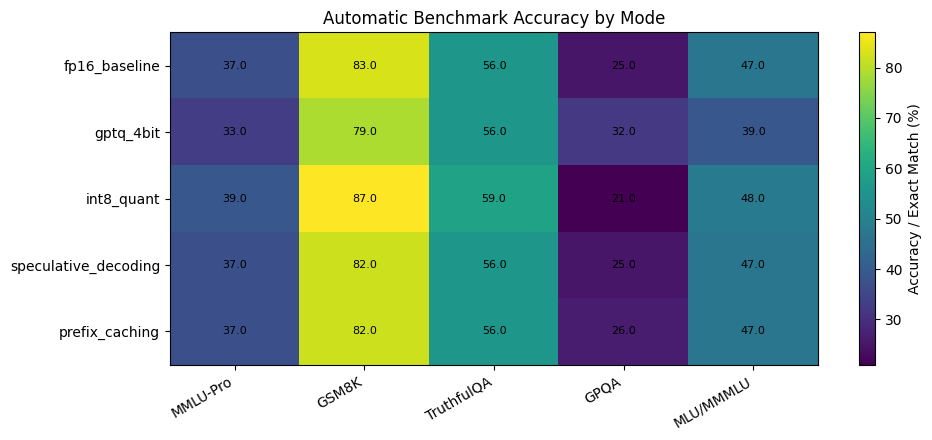

In [16]:
# ============================================================
# Cell 17: Accuracy Plot
# ============================================================

if len(automatic_accuracy_df) > 0:
    automatic_accuracy_matrix = (
        automatic_accuracy_df
        .pivot(index="mode_name", columns="benchmark_label", values="metric_display_value")
        .reindex(
            index=BENCHMARK_MODE_ORDER,
            columns=[
                BENCHMARK_LABELS[w]
                for w in AUTOMATIC_BENCHMARK_DISPLAY_ORDER
                if w in BENCHMARK_LABELS
            ],
        )
    )

    plot_annotated_heatmap(
        automatic_accuracy_matrix,
        title="Automatic Benchmark Accuracy by Mode",
        cbar_label="Accuracy / Exact Match (%)",
        fmt="{:.1f}",
        figsize=(10, 4.5),
        cmap="viridis",
        save_name="automatic_accuracy_heatmap.png",
    )

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260508_145059/total_latency_heatmap.png


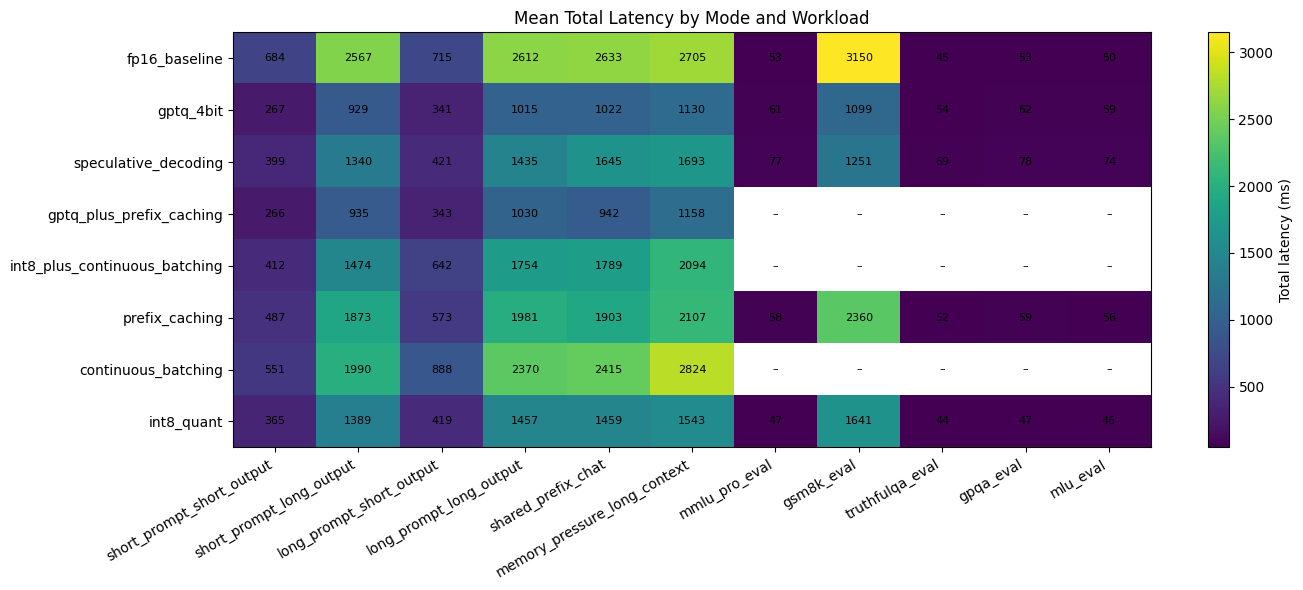

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260508_145059/throughput_heatmap.png


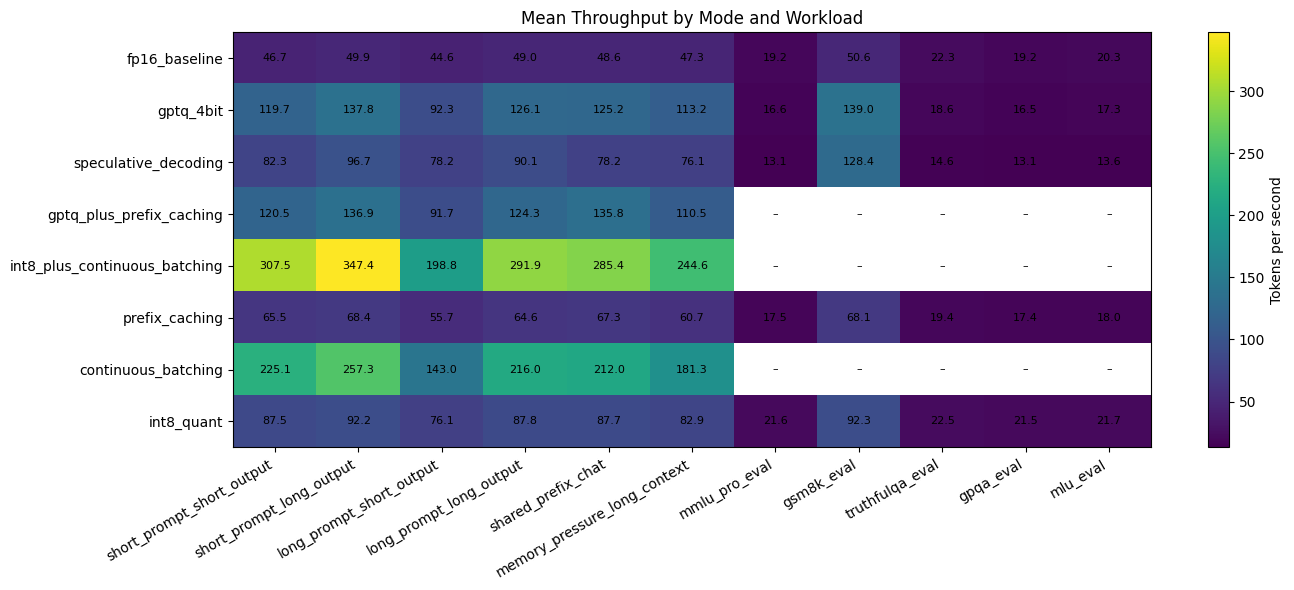

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260508_145059/energy_per_token_heatmap.png


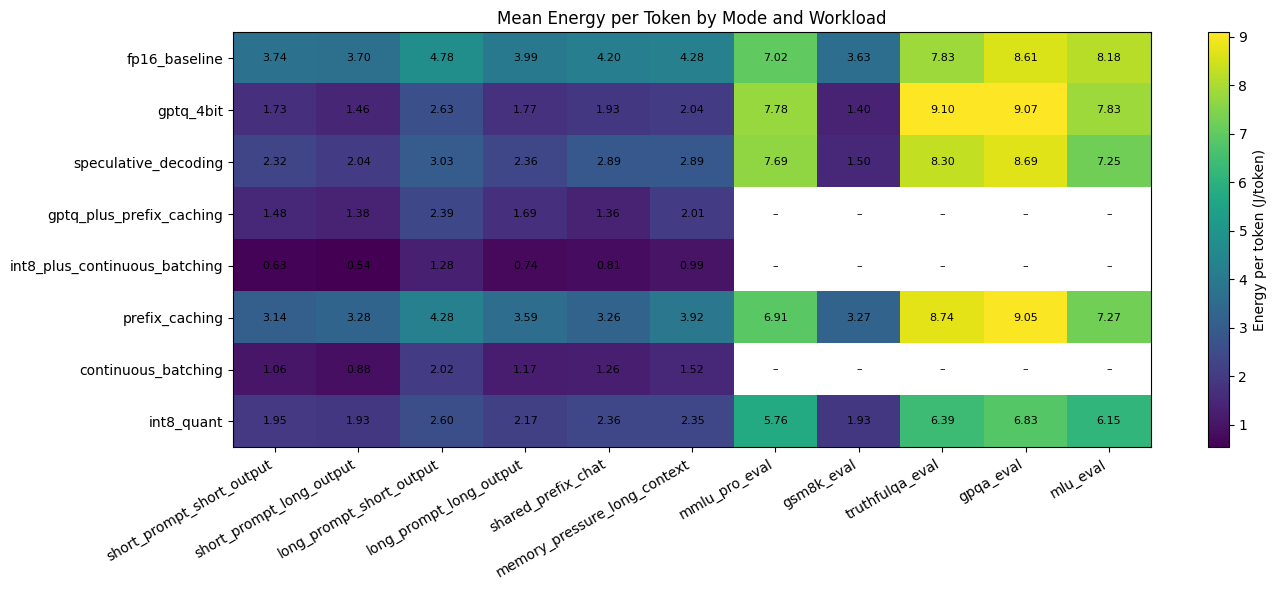

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260508_145059/peak_gpu_memory_heatmap.png


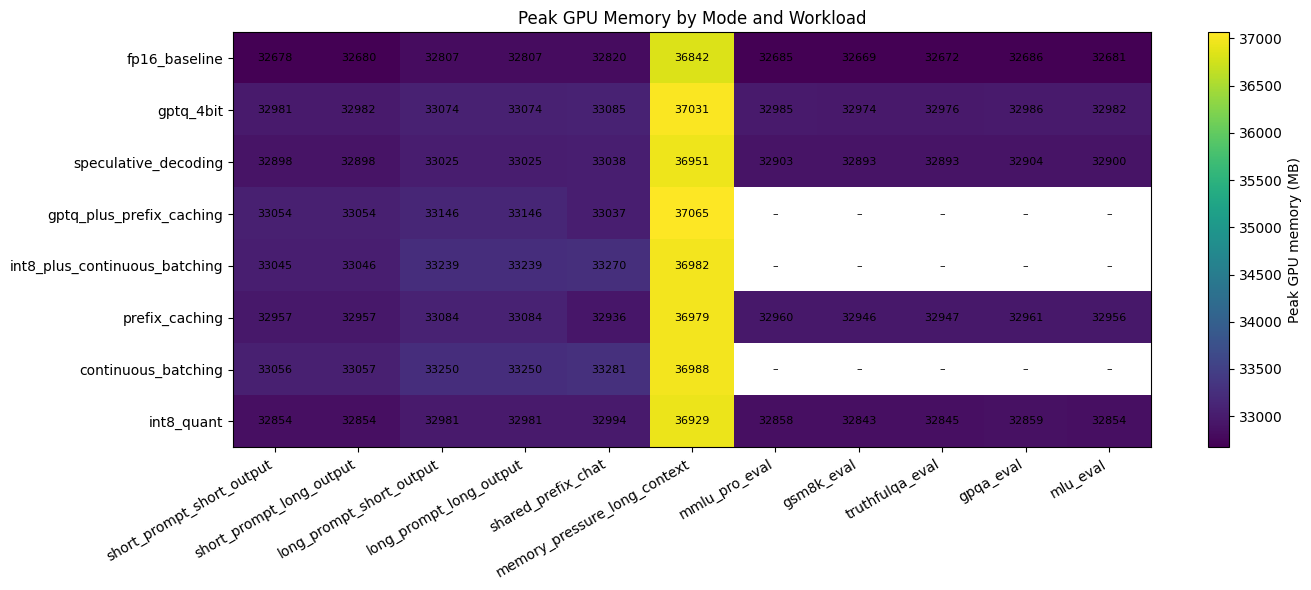

In [17]:
# ============================================================
# Cell 18: Performance heatmaps
# ============================================================

for value_col, title, cbar_label, fmt, save_name in [
    ("total_latency_ms_mean", "Mean Total Latency by Mode and Workload", "Total latency (ms)", "{:.0f}", "total_latency_heatmap.png"),
    ("tokens_per_second_mean", "Mean Throughput by Mode and Workload", "Tokens per second", "{:.1f}", "throughput_heatmap.png"),
    ("energy_per_token_j_mean", "Mean Energy per Token by Mode and Workload", "Energy per token (J/token)", "{:.2f}", "energy_per_token_heatmap.png"),
    ("peak_gpu_memory_mb_mean", "Peak GPU Memory by Mode and Workload", "Peak GPU memory (MB)", "{:.0f}", "peak_gpu_memory_heatmap.png"),
]:
    matrix = (
        dense_agg_df
        .pivot(index="mode_name", columns="workload_name", values=value_col)
        .reindex(index=MODE_ORDER, columns=WORKLOAD_ORDER_REPORT)
    )

    plot_annotated_heatmap(
        matrix,
        title=title,
        cbar_label=cbar_label,
        fmt=fmt,
        figsize=(14, 6),
        cmap="viridis",
        save_name=save_name,
    )

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260508_145059/latency_speedup_vs_baseline_heatmap.png


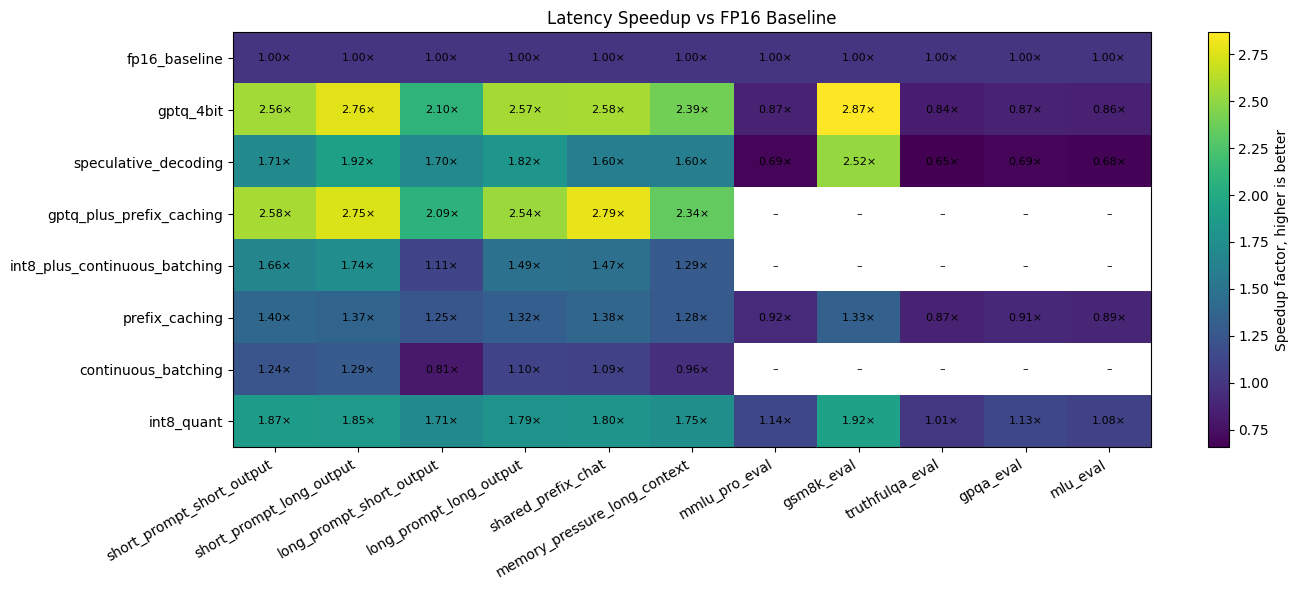

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260508_145059/energy_ratio_vs_baseline_heatmap.png


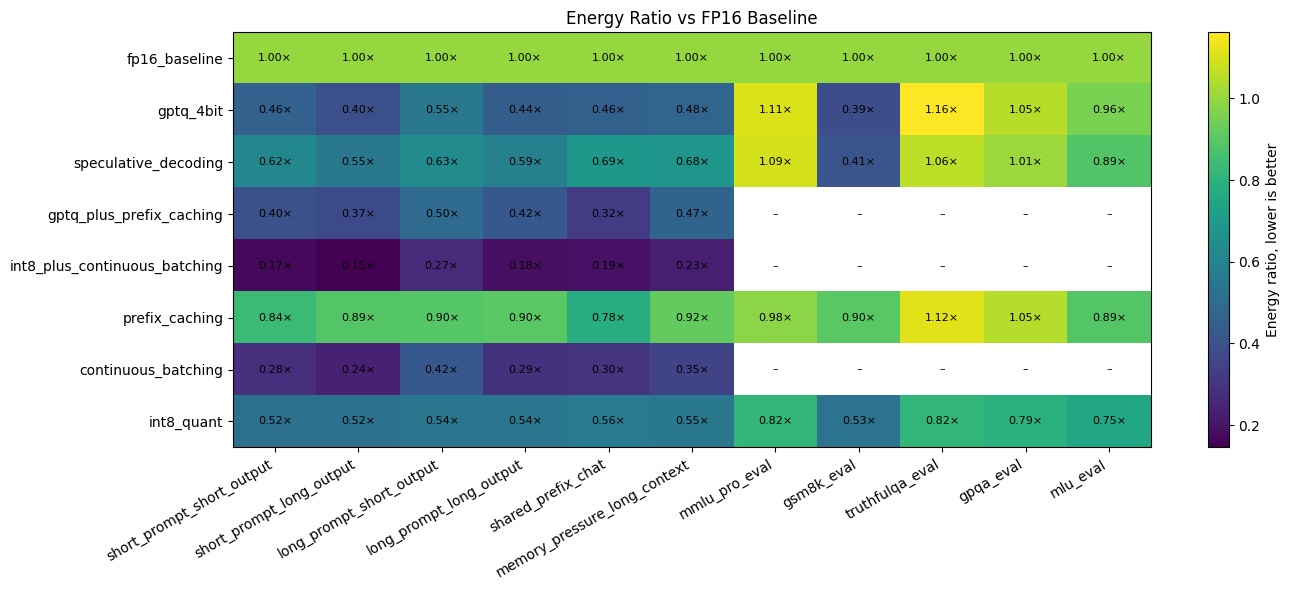

(<Figure size 1400x600 with 2 Axes>,
 <Axes: title={'center': 'Energy Ratio vs FP16 Baseline'}>)

In [18]:
# ============================================================
# Cell 19: Baseline ratio heatmaps
# ============================================================

speedup_matrix = (
    dense_perf_df
    .pivot(index="mode_name", columns="workload_name", values="latency_speedup_vs_baseline")
    .reindex(index=MODE_ORDER, columns=WORKLOAD_ORDER_REPORT)
)

plot_annotated_heatmap(
    speedup_matrix,
    title="Latency Speedup vs FP16 Baseline",
    cbar_label="Speedup factor, higher is better",
    fmt="{:.2f}×",
    figsize=(14, 6),
    cmap="viridis",
    save_name="latency_speedup_vs_baseline_heatmap.png",
)

energy_ratio_matrix = (
    dense_perf_df
    .pivot(index="mode_name", columns="workload_name", values="energy_ratio_vs_baseline")
    .reindex(index=MODE_ORDER, columns=WORKLOAD_ORDER_REPORT)
)

plot_annotated_heatmap(
    energy_ratio_matrix,
    title="Energy Ratio vs FP16 Baseline",
    cbar_label="Energy ratio, lower is better",
    fmt="{:.2f}×",
    figsize=(14, 6),
    cmap="viridis",
    save_name="energy_ratio_vs_baseline_heatmap.png",
)

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260508_145059/prefill_share_heatmap.png


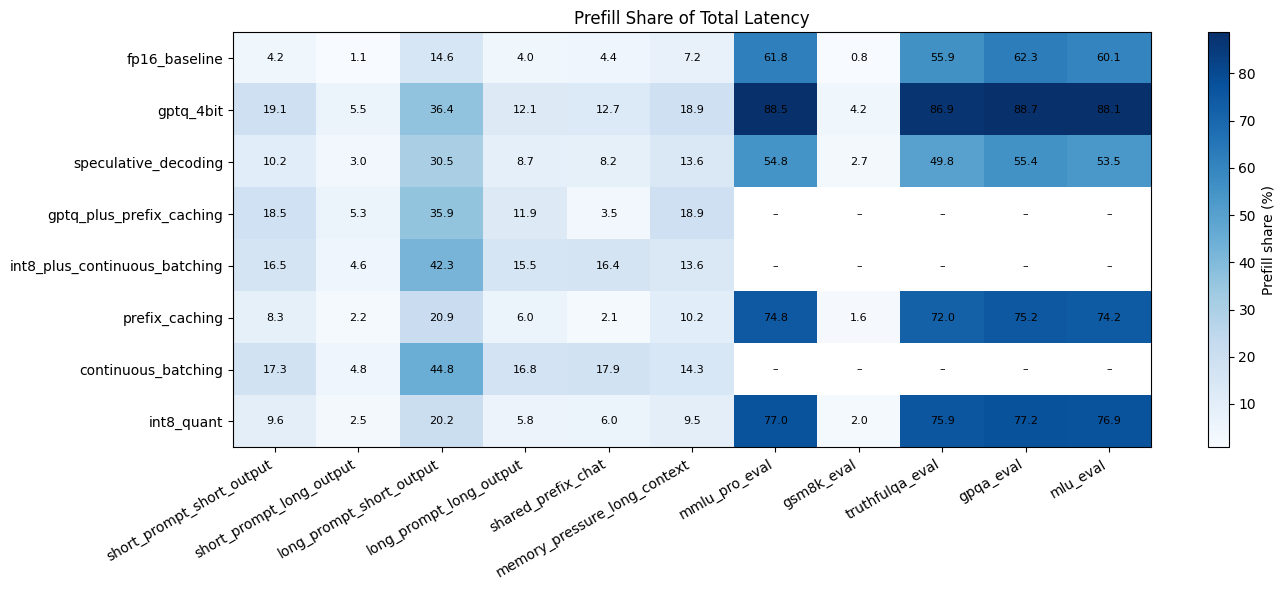

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260508_145059/decode_share_heatmap.png


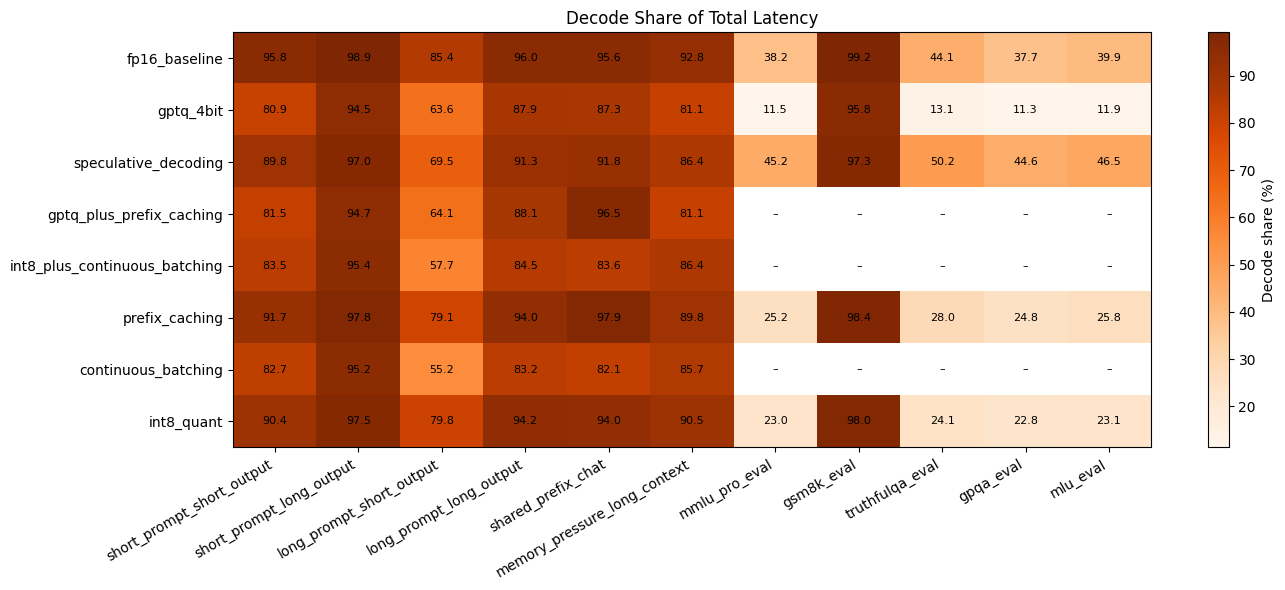

(<Figure size 1400x600 with 2 Axes>,
 <Axes: title={'center': 'Decode Share of Total Latency'}>)

In [19]:
# ============================================================
# Cell 20: Phase dominance heatmaps
# ============================================================

prefill_matrix = (
    dense_phase_df
    .pivot(index="mode_name", columns="workload_name", values="prefill_pct")
    .reindex(index=MODE_ORDER, columns=WORKLOAD_ORDER_REPORT)
)

decode_matrix = (
    dense_phase_df
    .pivot(index="mode_name", columns="workload_name", values="decode_pct")
    .reindex(index=MODE_ORDER, columns=WORKLOAD_ORDER_REPORT)
)

plot_annotated_heatmap(
    prefill_matrix,
    title="Prefill Share of Total Latency",
    cbar_label="Prefill share (%)",
    fmt="{:.1f}",
    figsize=(14, 6),
    cmap="Blues",
    save_name="prefill_share_heatmap.png",
)

plot_annotated_heatmap(
    decode_matrix,
    title="Decode Share of Total Latency",
    cbar_label="Decode share (%)",
    fmt="{:.1f}",
    figsize=(14, 6),
    cmap="Oranges",
    save_name="decode_share_heatmap.png",
)

In [20]:
# ============================================================
# Cell 21: Best mode tables
# ============================================================

best_latency_df = (
    dense_perf_df
    .sort_values(["workload_name", "total_latency_ms_mean"])
    .groupby("workload_name", as_index=False)
    .first()
)

best_energy_df = (
    dense_perf_df
    .sort_values(["workload_name", "energy_per_token_j_mean"])
    .groupby("workload_name", as_index=False)
    .first()
)

best_throughput_df = (
    dense_perf_df
    .sort_values(["workload_name", "tokens_per_second_mean"], ascending=[True, False])
    .groupby("workload_name", as_index=False)
    .first()
)

best_latency_df = best_latency_df[
    [
        "workload_name",
        "mode_name",
        "total_latency_ms_mean",
        "latency_speedup_vs_baseline",
        "tokens_per_second_mean",
        "energy_per_token_j_mean",
        "energy_ratio_vs_baseline",
        "peak_gpu_memory_mb_mean",
    ]
]

best_energy_df = best_energy_df[
    [
        "workload_name",
        "mode_name",
        "energy_per_token_j_mean",
        "energy_ratio_vs_baseline",
        "total_latency_ms_mean",
        "latency_speedup_vs_baseline",
        "tokens_per_second_mean",
        "peak_gpu_memory_mb_mean",
    ]
]

best_throughput_df = best_throughput_df[
    [
        "workload_name",
        "mode_name",
        "tokens_per_second_mean",
        "throughput_ratio_vs_baseline",
        "total_latency_ms_mean",
        "latency_speedup_vs_baseline",
        "energy_per_token_j_mean",
        "peak_gpu_memory_mb_mean",
    ]
]

save_table(best_latency_df, "best_mode_by_latency.csv")
save_table(best_energy_df, "best_mode_by_energy.csv")
save_table(best_throughput_df, "best_mode_by_throughput.csv")

print("Best by latency:")
display(best_latency_df)

print("Best by energy:")
display(best_energy_df)

print("Best by throughput:")
display(best_throughput_df)

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/best_mode_by_latency.csv
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/best_mode_by_energy.csv
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/best_mode_by_throughput.csv
Best by latency:


,workload_name,mode_name,total_latency_ms_mean,latency_speedup_vs_baseline,tokens_per_second_mean,energy_per_token_j_mean,energy_ratio_vs_baseline,peak_gpu_memory_mb_mean
0,gpqa_eval,int8_quant,47.081414,1.134947,21.504951,6.834047,0.793461,32859.311592
1,gsm8k_eval,gptq_4bit,1098.567108,2.867045,139.027978,1.404647,0.387133,32973.719038
2,long_prompt_long_output,gptq_4bit,1015.038485,2.573203,126.106630,1.769838,0.443712,33074.222656
3,long_prompt_short_output,gptq_4bit,341.256658,2.096238,92.273903,2.629973,0.550588,33074.238281
4,memory_pressure_long_context,gptq_4bit,1130.326824,2.393541,113.246896,2.036271,0.476173,37031.346958
5,mlu_eval,int8_quant,46.399557,1.084293,21.704204,6.153566,0.752073,32853.996328
6,mmlu_pro_eval,int8_quant,46.553259,1.136753,21.612970,5.758021,0.820088,32858.027686
7,shared_prefix_chat,gptq_plus_prefix_caching,942.477569,2.793471,135.814694,1.358716,0.323390,33037.405879
8,short_prompt_long_output,gptq_4bit,928.693210,2.763863,137.839146,1.460753,0.395317,32981.579800
9,short_prompt_short_output,gptq_plus_prefix_caching,265.543376,2.575588,120.544093,1.480005,0.395511,33054.003625


Best by energy:


,workload_name,mode_name,energy_per_token_j_mean,energy_ratio_vs_baseline,total_latency_ms_mean,latency_speedup_vs_baseline,tokens_per_second_mean,peak_gpu_memory_mb_mean
0,gpqa_eval,int8_quant,6.834047,0.793461,47.081414,1.134947,21.504951,32859.311592
1,gsm8k_eval,gptq_4bit,1.404647,0.387133,1098.567108,2.867045,139.027978,32973.719038
2,long_prompt_long_output,int8_plus_continuous_batching,0.737893,0.184996,1754.223952,1.488921,291.879044,33239.275332
3,long_prompt_short_output,int8_plus_continuous_batching,1.278258,0.267605,641.776817,1.114648,198.788109,33239.260879
4,memory_pressure_long_context,int8_plus_continuous_batching,0.987111,0.230831,2093.591856,1.292269,244.570091,36982.252222
5,mlu_eval,int8_quant,6.153566,0.752073,46.399557,1.084293,21.704204,32853.996328
6,mmlu_pro_eval,int8_quant,5.758021,0.820088,46.553259,1.136753,21.612970,32858.027686
7,shared_prefix_chat,int8_plus_continuous_batching,0.814293,0.193811,1788.931859,1.471707,285.364857,33270.162988
8,short_prompt_long_output,int8_plus_continuous_batching,0.536353,0.145151,1473.742872,1.741675,347.421308,33045.919854
9,short_prompt_short_output,int8_plus_continuous_batching,0.627877,0.167792,412.016308,1.659960,307.482616,33045.043213


Best by throughput:


,workload_name,mode_name,tokens_per_second_mean,throughput_ratio_vs_baseline,total_latency_ms_mean,latency_speedup_vs_baseline,energy_per_token_j_mean,peak_gpu_memory_mb_mean
0,gpqa_eval,int8_quant,21.504951,1.120396,47.081414,1.134947,6.834047,32859.311592
1,gsm8k_eval,gptq_4bit,139.027978,2.748364,1098.567108,2.867045,1.404647,32973.719038
2,long_prompt_long_output,int8_plus_continuous_batching,291.879044,5.955103,1754.223952,1.488921,0.737893,33239.275332
3,long_prompt_short_output,int8_plus_continuous_batching,198.788109,4.454564,641.776817,1.114648,1.278258,33239.260879
4,memory_pressure_long_context,int8_plus_continuous_batching,244.570091,5.168688,2093.591856,1.292269,0.987111,36982.252222
5,mlu_eval,int8_quant,21.704204,1.068941,46.399557,1.084293,6.153566,32853.996328
6,mmlu_pro_eval,int8_quant,21.612970,1.126415,46.553259,1.136753,5.758021,32858.027686
7,shared_prefix_chat,int8_plus_continuous_batching,285.364857,5.868691,1788.931859,1.471707,0.814293,33270.162988
8,short_prompt_long_output,int8_plus_continuous_batching,347.421308,6.963350,1473.742872,1.741675,0.536353,33045.919854
9,short_prompt_short_output,int8_plus_continuous_batching,307.482616,6.588814,412.016308,1.659960,0.627877,33045.043213


In [21]:
# ============================================================
# Cell 22: List saved plots and tables
# ============================================================

print("Saved plots:")
for path in sorted(PLOT_DIR.glob("*")):
    print(" -", path)

print("\nSaved tables:")
for path in sorted(TABLE_DIR.glob("*")):
    print(" -", path)

print("\nFinal dense result files:")
maybe_paths = [
    globals().get("dense_json_path"),
    globals().get("dense_csv_path"),
    globals().get("dense_summary_csv_path"),
    globals().get("dense_aggregate_csv_path"),
    globals().get("dense_comparison_csv_path"),
    globals().get("dense_error_csv_path"),
    globals().get("dense_report_dir"),
    globals().get("judge_sidecar_path"),
]

for path in maybe_paths:
    if path is not None:
        print(" -", path)

Saved plots:
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260508_145059/automatic_accuracy_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260508_145059/decode_share_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260508_145059/energy_per_token_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260508_145059/energy_ratio_vs_baseline_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260508_145059/highlight_figure_pack
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260508_145059/latency_speedup_vs_baseline_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_20260508_145059/peak_gpu_memory_heatmap.png
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/dense_final_plots_2026050

In [22]:
# ============================================================
# Cell 23: Offline controller routing from measured real modes
# ============================================================

CONTROLLER_WORKLOAD_FEATURES = {
    "short_prompt_short_output": dict(
        prompt_tokens=128,
        expected_output_tokens=32,
        shared_prefix=False,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="synthetic_interactive",
    ),
    "short_prompt_long_output": dict(
        prompt_tokens=128,
        expected_output_tokens=128,
        shared_prefix=False,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="synthetic_generation",
    ),
    "long_prompt_short_output": dict(
        prompt_tokens=1024,
        expected_output_tokens=32,
        shared_prefix=False,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="synthetic_interactive",
    ),
    "long_prompt_long_output": dict(
        prompt_tokens=1024,
        expected_output_tokens=128,
        shared_prefix=False,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="synthetic_generation",
    ),
    "shared_prefix_chat": dict(
        prompt_tokens=1024,
        expected_output_tokens=64,
        shared_prefix=True,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="chat_shared_prefix",
    ),
    "memory_pressure_long_context": dict(
        prompt_tokens=2048,
        expected_output_tokens=128,
        shared_prefix=False,
        memory_pressure=True,
        batch_pressure="normal",
        workload_tag="synthetic_long_context",
    ),
    "mmlu_pro_eval": dict(
        prompt_tokens=512,
        expected_output_tokens=8,
        shared_prefix=False,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="mmlu_pro",
    ),
    "gsm8k_eval": dict(
        prompt_tokens=512,
        expected_output_tokens=384,
        shared_prefix=False,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="gsm8k",
    ),
    "truthfulqa_eval": dict(
        prompt_tokens=512,
        expected_output_tokens=8,
        shared_prefix=False,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="truthfulqa",
    ),
    "gpqa_eval": dict(
        prompt_tokens=512,
        expected_output_tokens=8,
        shared_prefix=False,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="gpqa",
    ),
    "mlu_eval": dict(
        prompt_tokens=512,
        expected_output_tokens=8,
        shared_prefix=False,
        memory_pressure=False,
        batch_pressure="normal",
        workload_tag="mlu",
    ),
}

measured_workloads = set(dense_agg_df["workload_name"].dropna())
measured_pairs = set(zip(dense_agg_df["mode_name"], dense_agg_df["workload_name"]))

controller_route_rows = []

for workload_name in WORKLOAD_ORDER_REPORT:
    if workload_name not in measured_workloads:
        continue

    if workload_name not in CONTROLLER_WORKLOAD_FEATURES:
        print("Skipping missing controller features:", workload_name)
        continue

    feature_kwargs = CONTROLLER_WORKLOAD_FEATURES[workload_name]
    features = RequestFeatures(**feature_kwargs)
    classification = classify_request(features)
    decision = route_request(features)

    controller_route_rows.append({
        "workload_name": workload_name,
        "prompt_tokens": features.prompt_tokens,
        "expected_output_tokens": features.expected_output_tokens,
        "shared_prefix": features.shared_prefix,
        "memory_pressure": features.memory_pressure,
        "batch_pressure": features.batch_pressure,
        "workload_tag": features.workload_tag,
        "controller_phase_label": classification.label,
        "controller_estimated_prefill_share_pct": classification.estimated_prefill_share_pct,
        "controller_selected_mode_name": decision.selected_mode_name,
        "controller_route_reason": decision.reason,
        "selected_pair_available": (decision.selected_mode_name, workload_name) in measured_pairs,
    })

controller_routing_df = pd.DataFrame(controller_route_rows)

missing_controller_routes = controller_routing_df[~controller_routing_df["selected_pair_available"]]
if len(missing_controller_routes) > 0:
    display(missing_controller_routes)
    raise ValueError(
        "The controller selected modes that were not measured. "
        "Add those modes to STANDARD_DENSE_MODES or BENCHMARK_DENSE_MODES and rerun."
    )

print("Offline controller routing table:")
display(controller_routing_df)

Offline controller routing table:


,workload_name,prompt_tokens,expected_output_tokens,shared_prefix,memory_pressure,batch_pressure,workload_tag,controller_phase_label,controller_estimated_prefill_share_pct,controller_selected_mode_name,controller_route_reason,selected_pair_available
0,short_prompt_short_output,128,32,False,False,normal,synthetic_interactive,decode_heavy,0.0,speculative_decoding,Short interactive request: route to speculativ...,True
1,short_prompt_long_output,128,128,False,False,normal,synthetic_generation,decode_heavy,0.0,speculative_decoding,Decode-heavy long-generation workload: route t...,True
2,long_prompt_short_output,1024,32,False,False,normal,synthetic_interactive,decode_heavy,35.0,int8_quant,Long or prefill-heavy request without a reusab...,True
3,long_prompt_long_output,1024,128,False,False,normal,synthetic_generation,decode_heavy,0.0,speculative_decoding,Decode-heavy long-generation workload: route t...,True
4,shared_prefix_chat,1024,64,True,False,normal,chat_shared_prefix,chat_shared_prefix,0.0,gptq_plus_prefix_caching,Shared-prefix chat request: route to GPTQ + pr...,True
5,memory_pressure_long_context,2048,128,False,True,normal,synthetic_long_context,decode_heavy,0.0,gptq_4bit,Memory-pressure workload: route to GPTQ 4-bit ...,True
6,mmlu_pro_eval,512,8,False,False,normal,mmlu_pro,prefill_heavy,65.0,int8_quant,Automatically scored multiple-choice benchmark...,True
7,gsm8k_eval,512,384,False,False,normal,gsm8k,decode_heavy,0.0,speculative_decoding,GSM8K uses longer generated reasoning answers....,True
8,truthfulqa_eval,512,8,False,False,normal,truthfulqa,prefill_heavy,65.0,int8_quant,Automatically scored multiple-choice benchmark...,True
9,gpqa_eval,512,8,False,False,normal,gpqa,prefill_heavy,65.0,int8_quant,Automatically scored multiple-choice benchmark...,True


In [23]:
# ============================================================
# Cell 24: Offline controller vs FP16 performance
# ============================================================

controller_perf_df = controller_routing_df.merge(
    dense_agg_df,
    left_on=["controller_selected_mode_name", "workload_name"],
    right_on=["mode_name", "workload_name"],
    how="left",
)

fp16_perf_df = (
    dense_agg_df[dense_agg_df["mode_name"] == "fp16_baseline"]
    [[
        "workload_name",
        "total_latency_ms_mean",
        "tokens_per_second_mean",
        "energy_per_token_j_mean",
        "peak_gpu_memory_mb_mean",
    ]]
    .rename(columns={
        "total_latency_ms_mean": "fp16_total_latency_ms_mean",
        "tokens_per_second_mean": "fp16_tokens_per_second_mean",
        "energy_per_token_j_mean": "fp16_energy_per_token_j_mean",
        "peak_gpu_memory_mb_mean": "fp16_peak_gpu_memory_mb_mean",
    })
)

controller_perf_df = controller_perf_df.merge(fp16_perf_df, on="workload_name", how="left")

controller_perf_df["latency_speedup"] = (
    controller_perf_df["fp16_total_latency_ms_mean"] / controller_perf_df["total_latency_ms_mean"]
)
controller_perf_df["throughput_ratio"] = (
    controller_perf_df["tokens_per_second_mean"] / controller_perf_df["fp16_tokens_per_second_mean"]
)
controller_perf_df["energy_ratio"] = (
    controller_perf_df["energy_per_token_j_mean"] / controller_perf_df["fp16_energy_per_token_j_mean"]
)
controller_perf_df["memory_ratio"] = (
    controller_perf_df["peak_gpu_memory_mb_mean"] / controller_perf_df["fp16_peak_gpu_memory_mb_mean"]
)

controller_fp16_compare_df = controller_perf_df[[
    "workload_name",
    "controller_selected_mode_name",
    "controller_phase_label",
    "controller_estimated_prefill_share_pct",
    "total_latency_ms_mean",
    "fp16_total_latency_ms_mean",
    "latency_speedup",
    "tokens_per_second_mean",
    "fp16_tokens_per_second_mean",
    "throughput_ratio",
    "energy_per_token_j_mean",
    "fp16_energy_per_token_j_mean",
    "energy_ratio",
    "peak_gpu_memory_mb_mean",
    "fp16_peak_gpu_memory_mb_mean",
    "memory_ratio",
    "controller_route_reason",
]].sort_values("latency_speedup", ascending=False).reset_index(drop=True)

save_table(controller_fp16_compare_df, "offline_controller_vs_fp16_performance.csv")
display(controller_fp16_compare_df)

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/offline_controller_vs_fp16_performance.csv


,workload_name,controller_selected_mode_name,controller_phase_label,controller_estimated_prefill_share_pct,total_latency_ms_mean,fp16_total_latency_ms_mean,latency_speedup,tokens_per_second_mean,fp16_tokens_per_second_mean,throughput_ratio,energy_per_token_j_mean,fp16_energy_per_token_j_mean,energy_ratio,peak_gpu_memory_mb_mean,fp16_peak_gpu_memory_mb_mean,memory_ratio,controller_route_reason
0,shared_prefix_chat,gptq_plus_prefix_caching,chat_shared_prefix,0.0,942.477569,2632.784039,2.793471,135.814694,48.624961,2.793106,1.358716,4.201485,0.323390,33037.405879,32820.285156,1.006615,Shared-prefix chat request: route to GPTQ + pr...
1,gsm8k_eval,speculative_decoding,decode_heavy,0.0,1251.399517,3149.641846,2.516896,128.351092,50.585721,2.537299,1.496200,3.628337,0.412365,32892.846792,32669.478335,1.006837,GSM8K uses longer generated reasoning answers....
2,memory_pressure_long_context,gptq_4bit,decode_heavy,0.0,1130.326824,2705.483753,2.393541,113.246896,47.317632,2.393334,2.036271,4.276329,0.476173,37031.346958,36841.753950,1.005146,Memory-pressure workload: route to GPTQ 4-bit ...
3,short_prompt_long_output,speculative_decoding,decode_heavy,0.0,1339.781295,2566.780953,1.915821,96.693808,49.892841,1.938030,2.040403,3.695141,0.552186,32898.406069,32679.938394,1.006685,Decode-heavy long-generation workload: route t...
4,long_prompt_long_output,speculative_decoding,decode_heavy,0.0,1434.745035,2611.900087,1.820463,90.143239,49.013265,1.839160,2.360989,3.988707,0.591918,33025.211113,32807.182305,1.006646,Decode-heavy long-generation workload: route t...
5,short_prompt_short_output,speculative_decoding,decode_heavy,0.0,399.332996,683.930394,1.712682,82.265097,46.667371,1.762797,2.321317,3.742003,0.620341,32898.327563,32678.471927,1.006728,Short interactive request: route to speculativ...
6,long_prompt_short_output,int8_quant,decode_heavy,35.0,419.192594,715.355311,1.706508,76.119631,44.625713,1.705735,2.596315,4.776658,0.543542,32980.661797,32807.276055,1.005285,Long or prefill-heavy request without a reusab...
7,mmlu_pro_eval,int8_quant,prefill_heavy,65.0,46.553259,52.919535,1.136753,21.612970,19.187388,1.126415,5.758021,7.021228,0.820088,32858.027686,32684.553486,1.005308,Automatically scored multiple-choice benchmark...
8,gpqa_eval,int8_quant,prefill_heavy,65.0,47.081414,53.434910,1.134947,21.504951,19.194061,1.120396,6.834047,8.612962,0.793461,32859.311592,32685.919814,1.005305,Automatically scored multiple-choice benchmark...
9,mlu_eval,int8_quant,prefill_heavy,65.0,46.399557,50.310724,1.084293,21.704204,20.304398,1.068941,6.153566,8.182141,0.752073,32853.996328,32680.540156,1.005308,Automatically scored multiple-choice benchmark...


In [24]:
# ============================================================
# Cell 25: Offline controller accuracy gate
# ============================================================

controller_accuracy_metric_map = {
    "mmlu_pro_eval": "mmlu_pro_accuracy_mean",
    "gsm8k_eval": "gsm8k_exact_match_accuracy_mean",
    "truthfulqa_eval": "truthfulqa_accuracy_mean",
    "gpqa_eval": "gpqa_accuracy_mean",
    "mlu_eval": "mlu_accuracy_mean",
}

controller_auto_accuracy_rows = []

for workload_name, metric_col in controller_accuracy_metric_map.items():
    if workload_name not in set(dense_agg_df["workload_name"]):
        continue

    if metric_col not in dense_agg_df.columns:
        print("Missing metric column:", metric_col)
        continue

    selected_mode = controller_routing_df.loc[
        controller_routing_df["workload_name"] == workload_name,
        "controller_selected_mode_name",
    ].iloc[0]

    selected_row = dense_agg_df[
        (dense_agg_df["workload_name"] == workload_name)
        & (dense_agg_df["mode_name"] == selected_mode)
    ]
    fp16_row = dense_agg_df[
        (dense_agg_df["workload_name"] == workload_name)
        & (dense_agg_df["mode_name"] == "fp16_baseline")
    ]

    if len(selected_row) == 0 or len(fp16_row) == 0:
        continue

    controller_accuracy_pct = 100.0 * float(selected_row.iloc[0][metric_col])
    fp16_accuracy_pct = 100.0 * float(fp16_row.iloc[0][metric_col])

    controller_auto_accuracy_rows.append({
        "workload_name": workload_name,
        "metric_column": metric_col,
        "controller_selected_mode_name": selected_mode,
        "controller_accuracy_pct": controller_accuracy_pct,
        "fp16_accuracy_pct": fp16_accuracy_pct,
        "delta_pts": controller_accuracy_pct - fp16_accuracy_pct,
    })

controller_auto_accuracy_df = pd.DataFrame(controller_auto_accuracy_rows).sort_values("workload_name").reset_index(drop=True)

if len(controller_auto_accuracy_df) == 0:
    mean_controller_auto_accuracy_pct = np.nan
    mean_fp16_auto_accuracy_pct = np.nan
    mean_accuracy_delta_pts = np.nan
    controller_quality_pass = False
    print("No auto-graded controller accuracy rows were available.")
else:
    mean_controller_auto_accuracy_pct = controller_auto_accuracy_df["controller_accuracy_pct"].mean()
    mean_fp16_auto_accuracy_pct = controller_auto_accuracy_df["fp16_accuracy_pct"].mean()
    mean_accuracy_delta_pts = mean_controller_auto_accuracy_pct - mean_fp16_auto_accuracy_pct
    controller_quality_pass = abs(mean_accuracy_delta_pts) <= 1.5

    print("Mean controller auto-graded accuracy:", round(mean_controller_auto_accuracy_pct, 3))
    print("Mean FP16 auto-graded accuracy:", round(mean_fp16_auto_accuracy_pct, 3))
    print("Mean accuracy delta:", round(mean_accuracy_delta_pts, 3))
    print("Quality threshold result:", "PASS" if controller_quality_pass else "FAIL")

save_table(controller_auto_accuracy_df, "offline_controller_accuracy_gate.csv")
display(controller_auto_accuracy_df)

Mean controller auto-graded accuracy: 49.8
Mean FP16 auto-graded accuracy: 49.6
Mean accuracy delta: 0.2
Quality threshold result: PASS
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/offline_controller_accuracy_gate.csv


,workload_name,metric_column,controller_selected_mode_name,controller_accuracy_pct,fp16_accuracy_pct,delta_pts
0,gpqa_eval,gpqa_accuracy_mean,int8_quant,21.0,25.0,-4.0
1,gsm8k_eval,gsm8k_exact_match_accuracy_mean,speculative_decoding,82.0,83.0,-1.0
2,mlu_eval,mlu_accuracy_mean,int8_quant,48.0,47.0,1.0
3,mmlu_pro_eval,mmlu_pro_accuracy_mean,int8_quant,39.0,37.0,2.0
4,truthfulqa_eval,truthfulqa_accuracy_mean,int8_quant,59.0,56.0,3.0


In [25]:
# ============================================================
# Cell 26: Offline controller oracle comparison
# ============================================================

latency_oracle_df = (
    dense_agg_df.dropna(subset=["total_latency_ms_mean"])
    .sort_values(["workload_name", "total_latency_ms_mean"])
    .groupby("workload_name", as_index=False)
    .first()
    [["workload_name", "mode_name", "total_latency_ms_mean"]]
    .rename(columns={
        "mode_name": "latency_oracle_mode_name",
        "total_latency_ms_mean": "latency_oracle_total_latency_ms_mean",
    })
)

energy_oracle_df = (
    dense_agg_df.dropna(subset=["energy_per_token_j_mean"])
    .sort_values(["workload_name", "energy_per_token_j_mean"])
    .groupby("workload_name", as_index=False)
    .first()
    [["workload_name", "mode_name", "energy_per_token_j_mean"]]
    .rename(columns={
        "mode_name": "energy_oracle_mode_name",
        "energy_per_token_j_mean": "energy_oracle_energy_per_token_j_mean",
    })
)

controller_oracle_compare_df = (
    controller_fp16_compare_df
    [[
        "workload_name",
        "controller_selected_mode_name",
        "total_latency_ms_mean",
        "energy_per_token_j_mean",
    ]]
    .rename(columns={
        "total_latency_ms_mean": "controller_total_latency_ms_mean",
        "energy_per_token_j_mean": "controller_energy_per_token_j_mean",
    })
    .merge(latency_oracle_df, on="workload_name", how="left")
    .merge(energy_oracle_df, on="workload_name", how="left")
)

controller_oracle_compare_df["latency_oracle_over_controller"] = (
    controller_oracle_compare_df["latency_oracle_total_latency_ms_mean"]
    / controller_oracle_compare_df["controller_total_latency_ms_mean"]
)
controller_oracle_compare_df["energy_oracle_over_controller"] = (
    controller_oracle_compare_df["energy_oracle_energy_per_token_j_mean"]
    / controller_oracle_compare_df["controller_energy_per_token_j_mean"]
)
controller_oracle_compare_df["matches_latency_oracle_mode"] = (
    controller_oracle_compare_df["controller_selected_mode_name"]
    == controller_oracle_compare_df["latency_oracle_mode_name"]
)
controller_oracle_compare_df["matches_energy_oracle_mode"] = (
    controller_oracle_compare_df["controller_selected_mode_name"]
    == controller_oracle_compare_df["energy_oracle_mode_name"]
)

controller_oracle_compare_df = controller_oracle_compare_df.sort_values("workload_name").reset_index(drop=True)

save_table(controller_oracle_compare_df, "offline_controller_oracle_comparison.csv")
display(controller_oracle_compare_df)

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/offline_controller_oracle_comparison.csv


,workload_name,controller_selected_mode_name,controller_total_latency_ms_mean,controller_energy_per_token_j_mean,latency_oracle_mode_name,latency_oracle_total_latency_ms_mean,energy_oracle_mode_name,energy_oracle_energy_per_token_j_mean,latency_oracle_over_controller,energy_oracle_over_controller,matches_latency_oracle_mode,matches_energy_oracle_mode
0,gpqa_eval,int8_quant,47.081414,6.834047,int8_quant,47.081414,int8_quant,6.834047,1.000000,1.000000,True,True
1,gsm8k_eval,speculative_decoding,1251.399517,1.496200,gptq_4bit,1098.567108,gptq_4bit,1.404647,0.877871,0.938810,False,False
2,long_prompt_long_output,speculative_decoding,1434.745035,2.360989,gptq_4bit,1015.038485,int8_plus_continuous_batching,0.737893,0.707470,0.312536,False,False
3,long_prompt_short_output,int8_quant,419.192594,2.596315,gptq_4bit,341.256658,int8_plus_continuous_batching,1.278258,0.814081,0.492335,False,False
4,memory_pressure_long_context,gptq_4bit,1130.326824,2.036271,gptq_4bit,1130.326824,int8_plus_continuous_batching,0.987111,1.000000,0.484764,True,False
5,mlu_eval,int8_quant,46.399557,6.153566,int8_quant,46.399557,int8_quant,6.153566,1.000000,1.000000,True,True
6,mmlu_pro_eval,int8_quant,46.553259,5.758021,int8_quant,46.553259,int8_quant,5.758021,1.000000,1.000000,True,True
7,shared_prefix_chat,gptq_plus_prefix_caching,942.477569,1.358716,gptq_plus_prefix_caching,942.477569,int8_plus_continuous_batching,0.814293,1.000000,0.599310,True,False
8,short_prompt_long_output,speculative_decoding,1339.781295,2.040403,gptq_4bit,928.693210,int8_plus_continuous_batching,0.536353,0.693168,0.262866,False,False
9,short_prompt_short_output,speculative_decoding,399.332996,2.321317,gptq_plus_prefix_caching,265.543376,int8_plus_continuous_batching,0.627877,0.664967,0.270483,False,False


In [26]:
# ============================================================
# Cell 27: Final paper-ready summary tables
# ============================================================

FINAL_TABLE_DIR = TABLE_DIR / "final_paper_tables"
FINAL_TABLE_DIR.mkdir(parents=True, exist_ok=True)

headline_summary_df = pd.DataFrame([{
    "controller_evaluation_type": "offline_request_boundary_routing_from_measured_fixed_modes",
    "mean_latency_speedup": controller_fp16_compare_df["latency_speedup"].mean(),
    "mean_throughput_ratio": controller_fp16_compare_df["throughput_ratio"].mean(),
    "mean_energy_ratio": controller_fp16_compare_df["energy_ratio"].mean(),
    "mean_energy_reduction_pct": 100.0 * (1.0 - controller_fp16_compare_df["energy_ratio"].mean()),
    "mean_memory_ratio": controller_fp16_compare_df["memory_ratio"].mean(),
    "mean_accuracy_delta_pts": mean_accuracy_delta_pts,
    "quality_threshold_pass": "PASS" if controller_quality_pass else "FAIL",
    "quality_scope": "5 auto-graded benchmarks only",
    "memory_claim": "No meaningful GPU memory reduction claimed",
    "oracle_claim": "Controller is compared against oracle but is not oracle-optimal",
    "cache_caveat": (
        "Synthetic repeated trials may favor prefix-caching modes unless unique "
        "trial headers are enabled for future reruns."
    ),
}])

paper_summary_display = pd.DataFrame([
    {
        "Metric": "Controller evaluation type",
        "Value": "Offline routing over measured fixed-mode results",
    },
    {
        "Metric": "Mean latency speedup vs FP16",
        "Value": f"{headline_summary_df.iloc[0]['mean_latency_speedup']:.2f}×",
    },
    {
        "Metric": "Mean throughput ratio vs FP16",
        "Value": f"{headline_summary_df.iloc[0]['mean_throughput_ratio']:.2f}×",
    },
    {
        "Metric": "Mean energy ratio vs FP16",
        "Value": (
            f"{headline_summary_df.iloc[0]['mean_energy_ratio']:.2f}× "
            f"({headline_summary_df.iloc[0]['mean_energy_reduction_pct']:.1f}% lower)"
        ),
    },
    {
        "Metric": "Mean GPU memory ratio vs FP16",
        "Value": f"{headline_summary_df.iloc[0]['mean_memory_ratio']:.3f}× (unchanged)",
    },
    {
        "Metric": "Mean accuracy delta",
        "Value": f"{headline_summary_df.iloc[0]['mean_accuracy_delta_pts']:.2f} points",
    },
    {
        "Metric": "Quality threshold",
        "Value": headline_summary_df.iloc[0]["quality_threshold_pass"],
    },
    {
        "Metric": "Quality scope",
        "Value": "5 auto-graded benchmarks only; external judge workloads excluded",
    },
    {
        "Metric": "Oracle status",
        "Value": "Not oracle-optimal; oracle gap reported separately",
    },
])

headline_summary_df.to_csv(FINAL_TABLE_DIR / "headline_summary.csv", index=False)
paper_summary_display.to_csv(FINAL_TABLE_DIR / "paper_headline_table.csv", index=False)
paper_summary_display.to_latex(FINAL_TABLE_DIR / "paper_headline_table.tex", index=False, escape=False)
controller_routing_df.to_csv(FINAL_TABLE_DIR / "controller_routing_table.csv", index=False)
controller_fp16_compare_df.to_csv(FINAL_TABLE_DIR / "controller_vs_fp16_performance.csv", index=False)
controller_auto_accuracy_df.to_csv(FINAL_TABLE_DIR / "controller_accuracy_gate.csv", index=False)
controller_oracle_compare_df.to_csv(FINAL_TABLE_DIR / "controller_oracle_comparison.csv", index=False)

print("Final paper summary:")
display(paper_summary_display)

print("Saved final paper tables to:", FINAL_TABLE_DIR)
for path in sorted(FINAL_TABLE_DIR.glob("*")):
    print(" -", path)

Final paper summary:


,Metric,Value
0,Controller evaluation type,Offline routing over measured fixed-mode results
1,Mean latency speedup vs FP16,1.75×
2,Mean throughput ratio vs FP16,1.75×
3,Mean energy ratio vs FP16,0.61× (39.1% lower)
4,Mean GPU memory ratio vs FP16,1.006× (unchanged)
5,Mean accuracy delta,0.20 points
6,Quality threshold,PASS
7,Quality scope,5 auto-graded benchmarks only; external judge ...
8,Oracle status,Not oracle-optimal; oracle gap reported separa...


Saved final paper tables to: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/final_paper_tables
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/final_paper_tables/controller_accuracy_gate.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/final_paper_tables/controller_oracle_comparison.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/final_paper_tables/controller_routing_table.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/final_paper_tables/controller_vs_fp16_performance.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/final_paper_tables/headline_summary.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508

In [27]:
# ============================================================
# Cell 28: Online request-boundary controller execution
# ============================================================

from collections import defaultdict
from metrics import now_s
from controller import route_runtime_workload
from model_loader import load_model_for_mode, unload_model
from workloads import build_runtime_workload_by_name
from modes import build_runtime_mode_by_name
from runner import run_single_benchmark

ONLINE_CONTROLLER_MODE_NAME = "online_request_boundary_controller"

# ------------------------------------------------------------
# Recovery-safe helpers
# ------------------------------------------------------------

def collapse_online_workload_group_name(name):
    name = str(name)

    if "__" in name:
        name = name.split("__", 1)[0]

    name = re.sub(r"_v\d+$", "", name)

    return name


if "canonical_workload_group_name" not in globals():
    canonical_workload_group_name = collapse_online_workload_group_name


if "resolve_runtime_workload" not in globals():
    def resolve_runtime_workload(workload_name: str):
        return build_runtime_workload_by_name(workload_name)


if "resolve_runtime_mode" not in globals():
    def resolve_runtime_mode(mode_name: str):
        return build_runtime_mode_by_name(mode_name)


# If this notebook was resumed from recovery cells, FINAL_DENSE_WORKLOADS
# may not exist. Rebuild it from the dense raw JSON.
if "FINAL_DENSE_WORKLOADS" not in globals():
    if "dense_json_path" not in globals():
        raise NameError(
            "FINAL_DENSE_WORKLOADS and dense_json_path are both missing. "
            "Run the dense recovery / reporter cell first."
        )

    dense_raw_rows_for_online = load_json_rows(dense_json_path)

    FINAL_DENSE_WORKLOADS = list(dict.fromkeys(
        str(row["workload_name"])
        for row in dense_raw_rows_for_online
        if row.get("workload_name") is not None
        and row.get("mode_name") != ONLINE_CONTROLLER_MODE_NAME
    ))

    print("Rebuilt FINAL_DENSE_WORKLOADS from dense_json_path:", len(FINAL_DENSE_WORKLOADS))


if "trials_for_workload" not in globals():
    dense_raw_rows_for_trial_counts = (
        dense_raw_rows_for_online
        if "dense_raw_rows_for_online" in globals()
        else load_json_rows(dense_json_path)
    )

    trial_count_lookup = {}
    for row in dense_raw_rows_for_trial_counts:
        workload_name = row.get("workload_name")
        trial_index = row.get("trial_index")

        if workload_name is None or trial_index is None:
            continue

        # Prefer FP16 trial counts because every workload should have FP16.
        if row.get("mode_name") != "fp16_baseline":
            continue

        trial_count_lookup.setdefault(str(workload_name), set()).add(int(trial_index))

    def trials_for_workload(expanded_workload_name: str) -> int:
        trials = trial_count_lookup.get(str(expanded_workload_name))
        if trials:
            return len(trials)

        group_name = canonical_workload_group_name(expanded_workload_name)
        if group_name in {
            "mmlu_pro_eval",
            "gsm8k_eval",
            "truthfulqa_eval",
            "gpqa_eval",
            "mlu_eval",
        }:
            return 1

        return 5


# Full online controller run is much cheaper than the full fixed-mode sweep:
# it runs only the controller-selected mode for each workload, not every mode.
ONLINE_CONTROLLER_WORKLOADS = FINAL_DENSE_WORKLOADS

online_controller_results = []
online_controller_error_rows = []

online_run_stamp = time.strftime("%Y%m%d_%H%M%S")
online_json_path = RAW_RESULTS_DIR / f"online_controller_results_{online_run_stamp}.json"
online_csv_path = RAW_RESULTS_DIR / f"online_controller_results_{online_run_stamp}.csv"

RESUME_ONLINE_CONTROLLER = False
ONLINE_RESUME_JSON_PATH = None

online_existing_raw_rows = []
online_completed_keys = set()

if RESUME_ONLINE_CONTROLLER:
    if ONLINE_RESUME_JSON_PATH is None:
        ONLINE_RESUME_JSON_PATH = find_latest_json_checkpoint(
            RAW_RESULTS_DIR,
            patterns=[
                "online_controller_results_*.json",
            ],
        )

    if ONLINE_RESUME_JSON_PATH is not None:
        online_existing_raw_rows = load_json_rows(ONLINE_RESUME_JSON_PATH)
        online_completed_keys = {
            key
            for key in (run_key_from_row(row) for row in online_existing_raw_rows)
            if key is not None
        }

        print("Resuming online controller from:", ONLINE_RESUME_JSON_PATH)
        print("Previously completed online runs:", len(online_completed_keys))
    else:
        print("No online controller checkpoint found. Starting from scratch.")
    
# First pass: route each workload before execution, then group by selected mode
# so each selected model is loaded once.
online_plan_rows = []

for workload_name in ONLINE_CONTROLLER_WORKLOADS:
    runtime_workload = resolve_runtime_workload(workload_name)
    decision = route_runtime_workload(runtime_workload)

    online_plan_rows.append({
        "workload_name": workload_name,
        "workload_group": canonical_workload_group_name(workload_name),
        "selected_mode_name": decision.selected_mode_name,
        "classification_label": decision.classification_label,
        "estimated_prefill_share_pct": decision.estimated_prefill_share_pct,
        "route_reason": decision.reason,
        "trials": trials_for_workload(workload_name),
    })

online_plan_df = pd.DataFrame(online_plan_rows)
display(
    online_plan_df
    .groupby(["workload_group", "selected_mode_name"], as_index=False)
    .agg(
        num_expanded_workloads=("workload_name", "nunique"),
        trials=("trials", "sum"),
    )
)

mode_to_online_workloads = defaultdict(list)
for row in online_plan_rows:
    mode_to_online_workloads[row["selected_mode_name"]].append(row)

online_total_runs = sum(row["trials"] for row in online_plan_rows)
online_run_counter = len(online_completed_keys)

try:
    for selected_mode_name, rows in mode_to_online_workloads.items():
        runtime_mode = resolve_runtime_mode(selected_mode_name)

        print("\n" + "#" * 120)
        print(f"ONLINE CONTROLLER SELECTED MODE: {selected_mode_name}")
        print(f"Workloads routed here: {len(rows)}")
        print("#" * 120)

        bundle = None

        try:
            bundle = load_model_for_mode(runtime_mode)

            for plan_row in rows:
                workload_name = plan_row["workload_name"]
                n_trials = int(plan_row["trials"])

                for trial_index in range(n_trials):
                    run_key = (ONLINE_CONTROLLER_MODE_NAME, workload_name, trial_index)

                    if run_key in online_completed_keys:
                        continue
                    online_run_counter += 1

                    try:
                        runtime_workload = resolve_runtime_workload(workload_name)

                        # Route immediately before execution.
                        # This is the online decision point.
                        route_start_s = now_s(sync_cuda=False)
                        decision = route_runtime_workload(runtime_workload)
                        route_end_s = now_s(sync_cuda=False)
                        route_overhead_ms = (route_end_s - route_start_s) * 1000.0

                        if decision.selected_mode_name != selected_mode_name:
                            raise RuntimeError(
                                f"Route changed unexpectedly for {workload_name}: "
                                f"{selected_mode_name} -> {decision.selected_mode_name}"
                            )

                        result = run_single_benchmark(
                            runtime_mode=runtime_mode,
                            workload=runtime_workload,
                            trial_index=trial_index,
                            preloaded_bundle=bundle,
                        )

                        # Rewrite the visible mode name to represent the online controller,
                        # while preserving the real delegated mode in controller metadata.
                        result.mode_name = ONLINE_CONTROLLER_MODE_NAME
                        result.controller_selected_mode_name = decision.selected_mode_name
                        result.controller_phase_label = decision.classification_label
                        result.controller_estimated_prefill_share_pct = decision.estimated_prefill_share_pct
                        result.controller_route_reason = decision.reason
                        result.controller_routing_overhead_ms = route_overhead_ms
                        result.controller_decision_source = "online_before_execution"
                        result.evaluation_scope = "online_request_boundary_controller"

                        result.notes = (
                            f"Online request-boundary controller routed this request to "
                            f"{decision.selected_mode_name}. Routing overhead was "
                            f"{route_overhead_ms:.4f} ms. "
                            + (result.notes or "")
                        )

                        online_controller_results.append(result)
                        online_completed_keys.add(run_key)

                        print(
                            f"[{online_run_counter}/{online_total_runs}] "
                            f"{ONLINE_CONTROLLER_MODE_NAME:36s} -> {selected_mode_name:28s} | "
                            f"{workload_name:48s} | trial={trial_index:02d} | "
                            f"success={result.success} | "
                            f"route_ms={route_overhead_ms:.4f} | "
                            f"lat={fmt_num(result.total_latency_ms)} ms | "
                            f"tps={fmt_num(result.tokens_per_second)} | "
                            f"J/tok={fmt_num(result.energy_per_token_j, 3)}"
                        )

                    except Exception as exc:
                        online_controller_error_rows.append({
                            "selected_mode_name": selected_mode_name,
                            "workload_name": workload_name,
                            "trial_index": trial_index,
                            "error": str(exc),
                        })

                        print(
                            f"[{online_run_counter}/{online_total_runs}] "
                            f"{ONLINE_CONTROLLER_MODE_NAME} | {workload_name} | "
                            f"trial={trial_index:02d} | ERROR={exc}"
                        )

                    if online_run_counter % 25 == 0 and (online_existing_raw_rows or online_controller_results):
                        save_resume_checkpoint(
                            online_existing_raw_rows,
                            online_controller_results,
                            online_json_path,
                            online_csv_path,
                        )
                        print("Online checkpoint saved:", online_json_path)

                    if online_run_counter % 10 == 0:
                        gc.collect()
                        if torch is not None and torch.cuda.is_available():
                            torch.cuda.empty_cache()

        finally:
            if bundle is not None:
                unload_model(bundle)
                gc.collect()
                if torch is not None and torch.cuda.is_available():
                    torch.cuda.empty_cache()

finally:
    print(f"\nCollected {len(online_controller_results)} new online controller result objects this session.")
    print(f"Previously loaded online controller rows: {len(online_existing_raw_rows)}")
    print(f"Logged {len(online_controller_error_rows)} online controller hard errors.")

if online_existing_raw_rows or online_controller_results:
    combined_online_rows = save_resume_checkpoint(
        online_existing_raw_rows,
        online_controller_results,
        online_json_path,
        online_csv_path,
    )
    print("Saved online controller JSON:", online_json_path)
    print("Saved online controller CSV:", online_csv_path)
    print("Total saved online controller rows:", len(combined_online_rows))

if online_controller_error_rows:
    online_error_csv_path = RAW_RESULTS_DIR / f"online_controller_errors_{online_run_stamp}.csv"
    pd.DataFrame(online_controller_error_rows).to_csv(online_error_csv_path, index=False)
    print("Saved online controller error CSV:", online_error_csv_path)

[2574/3500] online_request_boundary_controller   -> speculative_decoding         | gsm8k_eval__gsm8k_0753                           | trial=00 | success=True | route_ms=0.0382 | lat=2799.29 ms | tps=124.32 | J/tok=1.756
[2575/3500] online_request_boundary_controller   -> speculative_decoding         | gsm8k_eval__gsm8k_0777                           | trial=00 | success=True | route_ms=0.0384 | lat=661.39 ms | tps=127.00 | J/tok=1.676
Online checkpoint saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/online_controller_results_20260509_122215.json
[2576/3500] online_request_boundary_controller   -> speculative_decoding         | gsm8k_eval__gsm8k_0779                           | trial=00 | success=True | route_ms=0.0473 | lat=782.31 ms | tps=144.44 | J/tok=1.143
[2577/3500] online_request_boundary_controller   -> speculative_decoding         | gsm8k_eval__gsm8k_0780                           | trial=00 | success=True | route_ms=0.0398 | lat=1108.19 ms | tps=134.45 | J/t

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


Capturing CUDA graph shapes: 100%|██████████| 4/4 [00:02<00:00,  1.60it/s]


[2601/3500] online_request_boundary_controller   -> gptq_plus_prefix_caching     | shared_prefix_chat_v0                            | trial=00 | success=True | route_ms=0.0853 | lat=967.96 ms | tps=132.24 | J/tok=1.645
[2602/3500] online_request_boundary_controller   -> gptq_plus_prefix_caching     | shared_prefix_chat_v0                            | trial=01 | success=True | route_ms=0.0313 | lat=953.12 ms | tps=134.30 | J/tok=1.565
[2603/3500] online_request_boundary_controller   -> gptq_plus_prefix_caching     | shared_prefix_chat_v0                            | trial=02 | success=True | route_ms=0.0294 | lat=952.92 ms | tps=134.32 | J/tok=1.604
[2604/3500] online_request_boundary_controller   -> gptq_plus_prefix_caching     | shared_prefix_chat_v0                            | trial=03 | success=True | route_ms=0.0302 | lat=960.61 ms | tps=133.25 | J/tok=1.603
[2605/3500] online_request_boundary_controller   -> gptq_plus_prefix_caching     | shared_prefix_chat_v0                    

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


Capturing CUDA graph shapes: 100%|██████████| 4/4 [00:02<00:00,  1.43it/s]


[3101/3500] online_request_boundary_controller   -> int8_quant                   | mmlu_pro_eval__mmlu_pro_0004                     | trial=00 | success=True | route_ms=0.1426 | lat=69.60 ms | tps=14.37 | J/tok=6.313
[3102/3500] online_request_boundary_controller   -> int8_quant                   | mmlu_pro_eval__mmlu_pro_0008                     | trial=00 | success=True | route_ms=0.0477 | lat=56.20 ms | tps=17.79 | J/tok=7.519
[3103/3500] online_request_boundary_controller   -> int8_quant                   | mmlu_pro_eval__mmlu_pro_0035                     | trial=00 | success=True | route_ms=0.0418 | lat=45.93 ms | tps=21.77 | J/tok=4.993
[3104/3500] online_request_boundary_controller   -> int8_quant                   | mmlu_pro_eval__mmlu_pro_0038                     | trial=00 | success=True | route_ms=0.0414 | lat=45.63 ms | tps=21.92 | J/tok=4.960
[3105/3500] online_request_boundary_controller   -> int8_quant                   | mmlu_pro_eval__mmlu_pro_0043                     

In [28]:
# ============================================================
# Cell 29: Combined fixed-mode + online-controller report
# ============================================================

if not online_json_path.exists():
    raise FileNotFoundError(f"Missing online controller JSON: {online_json_path}")

with open(dense_json_path, "r", encoding="utf-8") as f:
    dense_raw_rows = json.load(f)

with open(online_json_path, "r", encoding="utf-8") as f:
    online_raw_rows = json.load(f)

combined_json_path = RAW_RESULTS_DIR / f"dense_final_plus_online_controller_{dense_final_stamp}_{online_run_stamp}.json"

with open(combined_json_path, "w", encoding="utf-8") as f:
    json.dump(dense_raw_rows + online_raw_rows, f, indent=2, ensure_ascii=False)

combined_report_dir = generate_full_report(
    input_path=combined_json_path,
    output_dir=RAW_RESULTS_DIR / f"dense_final_plus_online_controller_report_{dense_final_stamp}_{online_run_stamp}",
    quality_metric="auto",
)

combined_report_dir = Path(combined_report_dir)
combined_agg_df = pd.read_csv(combined_report_dir / "aggregated.csv")
combined_phase_df = pd.read_csv(combined_report_dir / "phase_dominance.csv")
combined_failure_df = pd.read_csv(combined_report_dir / "failure_summary.csv")

print("Combined JSON:", combined_json_path)
print("Combined report directory:", combined_report_dir)
print("Combined aggregated rows:", len(combined_agg_df))
display(combined_agg_df[combined_agg_df["mode_name"] == ONLINE_CONTROLLER_MODE_NAME])

Combined JSON: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_plus_online_controller_20260508_145059_20260509_122215.json
Combined report directory: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_plus_online_controller_report_20260508_145059_20260509_122215
Combined aggregated rows: 5430


,mode_name,workload_name,workload_cell,system_condition,backend,benchmark_suite,benchmark_subset,benchmark_language,evaluation_mode,benchmark_primary_metric_name,...,mt_bench_score_median,mt_bench_score_p95,mt_bench_score_min,mt_bench_score_max,alpacaeval2_lc_win_rate_mean,alpacaeval2_lc_win_rate_std,alpacaeval2_lc_win_rate_median,alpacaeval2_lc_win_rate_p95,alpacaeval2_lc_win_rate_min,alpacaeval2_lc_win_rate_max
3,online_request_boundary_controller,gpqa_eval,LS,baseline,vllm,gpqa,gpqa_diamond:Chemistry:Chemistry (general),en,multiple_choice_accuracy,gpqa_accuracy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,online_request_boundary_controller,gsm8k_eval,LL,baseline,vllm,gsm8k,NaN,en,final_answer_exact_match,gsm8k_exact_match_accuracy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,online_request_boundary_controller,long_prompt_long_output_v0,LL,baseline,vllm,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,online_request_boundary_controller,long_prompt_long_output_v1,LL,baseline,vllm,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,online_request_boundary_controller,long_prompt_long_output_v10,LL,baseline,vllm,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5394,online_request_boundary_controller,short_prompt_short_output_v96,SS,baseline,vllm,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5403,online_request_boundary_controller,short_prompt_short_output_v97,SS,baseline,vllm,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5412,online_request_boundary_controller,short_prompt_short_output_v98,SS,baseline,vllm,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5421,online_request_boundary_controller,short_prompt_short_output_v99,SS,baseline,vllm,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# ============================================================
# Cell 30: Online controller vs FP16 final comparison
# ============================================================

online_agg_df = combined_agg_df[
    combined_agg_df["mode_name"] == ONLINE_CONTROLLER_MODE_NAME
].copy()

fp16_combined_df = (
    combined_agg_df[combined_agg_df["mode_name"] == "fp16_baseline"]
    [[
        "workload_name",
        "total_latency_ms_mean",
        "tokens_per_second_mean",
        "energy_per_token_j_mean",
        "peak_gpu_memory_mb_mean",
    ]]
    .rename(columns={
        "total_latency_ms_mean": "fp16_total_latency_ms_mean",
        "tokens_per_second_mean": "fp16_tokens_per_second_mean",
        "energy_per_token_j_mean": "fp16_energy_per_token_j_mean",
        "peak_gpu_memory_mb_mean": "fp16_peak_gpu_memory_mb_mean",
    })
)

online_compare_df = online_agg_df.merge(fp16_combined_df, on="workload_name", how="inner")

routing_col = "controller_routing_overhead_ms_mean"
if routing_col not in online_compare_df.columns:
    online_compare_df[routing_col] = 0.0

online_compare_df["controller_total_latency_with_routing_ms_mean"] = (
    online_compare_df["total_latency_ms_mean"]
    + online_compare_df[routing_col].fillna(0.0)
)

online_compare_df["latency_speedup_with_routing"] = (
    online_compare_df["fp16_total_latency_ms_mean"]
    / online_compare_df["controller_total_latency_with_routing_ms_mean"]
)
online_compare_df["throughput_ratio"] = (
    online_compare_df["tokens_per_second_mean"]
    / online_compare_df["fp16_tokens_per_second_mean"]
)
online_compare_df["energy_ratio"] = (
    online_compare_df["energy_per_token_j_mean"]
    / online_compare_df["fp16_energy_per_token_j_mean"]
)
online_compare_df["memory_ratio"] = (
    online_compare_df["peak_gpu_memory_mb_mean"]
    / online_compare_df["fp16_peak_gpu_memory_mb_mean"]
)

online_compare_df = online_compare_df.sort_values(
    "latency_speedup_with_routing",
    ascending=False,
).reset_index(drop=True)

print("Available online_compare_df columns:")
print(list(online_compare_df.columns))

# Create controller_selected_mode_name if missing
if "controller_selected_mode_name" not in online_compare_df.columns:
    if "selected_mode_name" in online_compare_df.columns:
        online_compare_df["controller_selected_mode_name"] = online_compare_df["selected_mode_name"]
    elif "mode_name" in online_compare_df.columns:
        online_compare_df["controller_selected_mode_name"] = online_compare_df["mode_name"]
    elif "runtime_mode_name" in online_compare_df.columns:
        online_compare_df["controller_selected_mode_name"] = online_compare_df["runtime_mode_name"]
    else:
        online_compare_df["controller_selected_mode_name"] = "unknown"

# Create controller_phase_label if missing
if "controller_phase_label" not in online_compare_df.columns:
    if "phase_label" in online_compare_df.columns:
        online_compare_df["controller_phase_label"] = online_compare_df["phase_label"]
    elif "routing_phase_label" in online_compare_df.columns:
        online_compare_df["controller_phase_label"] = online_compare_df["routing_phase_label"]
    elif "phase" in online_compare_df.columns:
        online_compare_df["controller_phase_label"] = online_compare_df["phase"]
    else:
        online_compare_df["controller_phase_label"] = "online_routing"
        
save_table(online_compare_df, "online_controller_vs_fp16_performance.csv")
display(online_compare_df[[
    "workload_name",
    "controller_selected_mode_name",
    "controller_phase_label",
    "controller_routing_overhead_ms_mean",
    "controller_total_latency_with_routing_ms_mean",
    "fp16_total_latency_ms_mean",
    "latency_speedup_with_routing",
    "throughput_ratio",
    "energy_ratio",
    "memory_ratio",
]])

# Online controller auto-graded quality gate.
online_accuracy_rows = []

for workload_name, metric_col in controller_accuracy_metric_map.items():
    sub = combined_agg_df[combined_agg_df["workload_name"] == workload_name].copy()
    controller_row = sub[sub["mode_name"] == ONLINE_CONTROLLER_MODE_NAME]
    fp16_row = sub[sub["mode_name"] == "fp16_baseline"]

    if len(controller_row) == 0 or len(fp16_row) == 0:
        continue

    if metric_col not in combined_agg_df.columns:
        continue

    controller_accuracy_pct = 100.0 * float(controller_row.iloc[0][metric_col])
    fp16_accuracy_pct = 100.0 * float(fp16_row.iloc[0][metric_col])

    online_accuracy_rows.append({
        "workload_name": workload_name,
        "metric_column": metric_col,
        "controller_selected_mode_name": controller_row.iloc[0].get("controller_selected_mode_name"),
        "online_controller_accuracy_pct": controller_accuracy_pct,
        "fp16_accuracy_pct": fp16_accuracy_pct,
        "delta_pts": controller_accuracy_pct - fp16_accuracy_pct,
    })

online_controller_accuracy_df = pd.DataFrame(online_accuracy_rows).sort_values("workload_name").reset_index(drop=True)

online_mean_controller_accuracy_pct = online_controller_accuracy_df["online_controller_accuracy_pct"].mean()
online_mean_fp16_accuracy_pct = online_controller_accuracy_df["fp16_accuracy_pct"].mean()
online_mean_accuracy_delta_pts = (
    online_mean_controller_accuracy_pct
    - online_mean_fp16_accuracy_pct
)
online_controller_quality_pass = abs(online_mean_accuracy_delta_pts) <= 1.5

print("Online controller mean auto-graded accuracy:", round(online_mean_controller_accuracy_pct, 3))
print("FP16 mean auto-graded accuracy:", round(online_mean_fp16_accuracy_pct, 3))
print("Online mean accuracy delta:", round(online_mean_accuracy_delta_pts, 3))
print("Online quality threshold result:", "PASS" if online_controller_quality_pass else "FAIL")

save_table(online_controller_accuracy_df, "online_controller_accuracy_gate.csv")
display(online_controller_accuracy_df)

online_headline_summary_df = pd.DataFrame([{
    "controller_evaluation_type": "online_request_boundary_controller",
    "mean_latency_speedup_with_routing": online_compare_df["latency_speedup_with_routing"].mean(),
    "mean_throughput_ratio": online_compare_df["throughput_ratio"].mean(),
    "mean_energy_ratio": online_compare_df["energy_ratio"].mean(),
    "mean_energy_reduction_pct": 100.0 * (1.0 - online_compare_df["energy_ratio"].mean()),
    "mean_memory_ratio": online_compare_df["memory_ratio"].mean(),
    "mean_accuracy_delta_pts": online_mean_accuracy_delta_pts,
    "quality_threshold_pass": "PASS" if online_controller_quality_pass else "FAIL",
    "quality_scope": "5 auto-graded benchmarks only",
}])

display(online_headline_summary_df)
save_table(online_headline_summary_df, "online_controller_headline_summary.csv")

Available online_compare_df columns:
['mode_name', 'workload_name', 'workload_cell', 'system_condition', 'backend', 'benchmark_suite', 'benchmark_subset', 'benchmark_language', 'evaluation_mode', 'benchmark_primary_metric_name', 'n', 'failure_count', 'failure_rate', 'num_requests_in_batch_mean', 'prompt_tokens_target_mean', 'max_new_tokens_mean', 'repeated_prefix', 'memory_pressure', 'ttft_ms_mean', 'ttft_ms_std', 'ttft_ms_median', 'ttft_ms_p95', 'ttft_ms_min', 'ttft_ms_max', 'avg_tbt_ms_mean', 'avg_tbt_ms_std', 'avg_tbt_ms_median', 'avg_tbt_ms_p95', 'avg_tbt_ms_min', 'avg_tbt_ms_max', 'tbt_median_ms_mean', 'tbt_median_ms_std', 'tbt_median_ms_median', 'tbt_median_ms_p95', 'tbt_median_ms_min', 'tbt_median_ms_max', 'tbt_p95_ms_mean', 'tbt_p95_ms_std', 'tbt_p95_ms_median', 'tbt_p95_ms_p95', 'tbt_p95_ms_min', 'tbt_p95_ms_max', 'tbt_p99_ms_mean', 'tbt_p99_ms_std', 'tbt_p99_ms_median', 'tbt_p99_ms_p95', 'tbt_p99_ms_min', 'tbt_p99_ms_max', 'tbt_std_ms_mean', 'tbt_std_ms_std', 'tbt_std_ms_medi

,workload_name,controller_selected_mode_name,controller_phase_label,controller_routing_overhead_ms_mean,controller_total_latency_with_routing_ms_mean,fp16_total_latency_ms_mean,latency_speedup_with_routing,throughput_ratio,energy_ratio,memory_ratio
0,shared_prefix_chat_v67,online_request_boundary_controller,online_routing,0.0,947.856683,2676.425154,2.823660,2.823472,0.367465,1.005571
1,shared_prefix_chat_v65,online_request_boundary_controller,online_routing,0.0,951.791149,2684.268989,2.820229,2.819959,0.368145,1.005571
2,shared_prefix_chat_v70,online_request_boundary_controller,online_routing,0.0,950.716564,2675.153577,2.813829,2.813778,0.367702,1.005571
3,shared_prefix_chat_v69,online_request_boundary_controller,online_routing,0.0,951.652179,2673.062624,2.808865,2.808583,0.375966,1.005571
4,shared_prefix_chat_v59,online_request_boundary_controller,online_routing,0.0,944.995222,2652.511948,2.806905,2.806757,0.371489,1.005571
...,...,...,...,...,...,...,...,...,...,...
600,short_prompt_long_output_v98,online_request_boundary_controller,online_routing,0.0,1673.403079,2526.849712,1.510007,1.509965,0.786923,1.005158
601,gpqa_eval,online_request_boundary_controller,online_routing,0.0,48.448385,53.434910,1.102924,1.087790,0.925671,1.006536
602,mmlu_pro_eval,online_request_boundary_controller,online_routing,0.0,48.080308,52.919535,1.100649,1.090453,0.976402,1.006540
603,mlu_eval,online_request_boundary_controller,online_routing,0.0,47.780951,50.310724,1.052945,1.037046,0.833129,1.006542


Online controller mean auto-graded accuracy: 49.8
FP16 mean auto-graded accuracy: 49.6
Online mean accuracy delta: 0.2
Online quality threshold result: PASS
Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/online_controller_accuracy_gate.csv


,workload_name,metric_column,controller_selected_mode_name,online_controller_accuracy_pct,fp16_accuracy_pct,delta_pts
0,gpqa_eval,gpqa_accuracy_mean,None,21.0,25.0,-4.0
1,gsm8k_eval,gsm8k_exact_match_accuracy_mean,None,82.0,83.0,-1.0
2,mlu_eval,mlu_accuracy_mean,None,48.0,47.0,1.0
3,mmlu_pro_eval,mmlu_pro_accuracy_mean,None,39.0,37.0,2.0
4,truthfulqa_eval,truthfulqa_accuracy_mean,None,59.0,56.0,3.0


,controller_evaluation_type,mean_latency_speedup_with_routing,mean_throughput_ratio,mean_energy_ratio,mean_energy_reduction_pct,mean_memory_ratio,mean_accuracy_delta_pts,quality_threshold_pass,quality_scope
0,online_request_boundary_controller,2.35944,2.355864,0.531087,46.891319,1.003565,0.2,PASS,5 auto-graded benchmarks only


Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/online_controller_headline_summary.csv


PosixPath('/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/online_controller_headline_summary.csv')

In [31]:
# ============================================================
# Cell 27B: Final paper-ready summary tables for ONLINE controller
# ============================================================

ONLINE_FINAL_TABLE_DIR = TABLE_DIR / "final_paper_tables_online_controller"
ONLINE_FINAL_TABLE_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Helper: collapse repeated workload variants before averaging
# ------------------------------------------------------------

def collapse_repeated_workload_name_for_tables(workload_name):
    return collapse_report_workload_name(workload_name)


def collapse_online_compare_for_summary(df):
    """
    Average numeric metrics across repeated workload variants.
    Keeps one row per logical workload family.
    """
    collapsed_df = df.copy()

    collapsed_df["collapsed_workload_name"] = collapsed_df["workload_name"].apply(
        collapse_repeated_workload_name_for_tables
    )

    numeric_cols = collapsed_df.select_dtypes(include=[np.number]).columns.tolist()

    collapsed_df = (
        collapsed_df
        .groupby("collapsed_workload_name", as_index=False)[numeric_cols]
        .mean()
        .rename(columns={"collapsed_workload_name": "workload_name"})
    )

    return collapsed_df


def safe_mean(df, col):
    """
    Return mean if the column exists; otherwise return NaN.
    """
    if df is not None and col in df.columns:
        return df[col].mean()
    return np.nan


# ------------------------------------------------------------
# Build collapsed online-controller performance table
# ------------------------------------------------------------

if "online_compare_df" not in globals() or len(online_compare_df) == 0:
    raise RuntimeError("online_compare_df is missing or empty. Run the online controller comparison cell first.")

online_compare_summary_df = collapse_online_compare_for_summary(online_compare_df)

online_compare_summary_df = online_compare_summary_df.sort_values(
    "latency_speedup_with_routing",
    ascending=False,
).reset_index(drop=True)


# ------------------------------------------------------------
# Online controller quality gate
# ------------------------------------------------------------

if "online_controller_accuracy_df" in globals() and len(online_controller_accuracy_df) > 0:
    online_accuracy_summary_df = online_controller_accuracy_df.copy()

    if "workload_name" in online_accuracy_summary_df.columns:
        online_accuracy_summary_df["workload_name"] = online_accuracy_summary_df["workload_name"].apply(
            collapse_repeated_workload_name_for_tables
        )

    numeric_cols = online_accuracy_summary_df.select_dtypes(include=[np.number]).columns.tolist()

    online_accuracy_summary_df = (
        online_accuracy_summary_df
        .groupby("workload_name", as_index=False)[numeric_cols]
        .mean()
    )

    online_mean_accuracy_delta_pts = safe_mean(online_accuracy_summary_df, "delta_pts")

    if "delta_pts" in online_accuracy_summary_df.columns:
        online_controller_quality_pass = bool(
            online_accuracy_summary_df["delta_pts"].abs().max() <= 1.5
        )
    else:
        online_controller_quality_pass = False
else:
    online_accuracy_summary_df = pd.DataFrame()
    online_mean_accuracy_delta_pts = np.nan
    online_controller_quality_pass = False


# ------------------------------------------------------------
# Online controller selected-mode counts
# ------------------------------------------------------------

if "online_plan_df" in globals() and len(online_plan_df) > 0 and "selected_mode_name" in online_plan_df.columns:
    online_mode_count_df = (
        online_plan_df["selected_mode_name"]
        .value_counts()
        .rename_axis("selected_mode")
        .reset_index(name="num_online_routes")
    )
elif "controller_routing_df" in globals() and len(controller_routing_df) > 0 and "controller_selected_mode_name" in controller_routing_df.columns:
    online_mode_count_df = (
        controller_routing_df["controller_selected_mode_name"]
        .value_counts()
        .rename_axis("selected_mode")
        .reset_index(name="num_online_routes")
    )
else:
    online_mode_count_df = pd.DataFrame()


# ------------------------------------------------------------
# Headline machine-readable summary
# ------------------------------------------------------------

online_headline_summary_df = pd.DataFrame([{
    "controller_evaluation_type": "online_request_boundary_routing_with_measured_routing_overhead",
    "averaging_policy": "repeated shared-prefix and memory-pressure variants collapsed before averaging",
    "num_logical_workloads": len(online_compare_summary_df),
    "mean_controller_total_latency_with_routing_ms": safe_mean(
        online_compare_summary_df,
        "controller_total_latency_with_routing_ms_mean",
    ),
    "mean_fp16_total_latency_ms": safe_mean(
        online_compare_summary_df,
        "fp16_total_latency_ms_mean",
    ),
    "mean_routing_overhead_ms": safe_mean(
        online_compare_summary_df,
        "controller_routing_overhead_ms_mean",
    ),
    "mean_latency_speedup_with_routing": safe_mean(
        online_compare_summary_df,
        "latency_speedup_with_routing",
    ),
    "mean_throughput_ratio": safe_mean(
        online_compare_summary_df,
        "throughput_ratio",
    ),
    "mean_energy_ratio": safe_mean(
        online_compare_summary_df,
        "energy_ratio",
    ),
    "mean_energy_reduction_pct": 100.0 * (
        1.0 - safe_mean(online_compare_summary_df, "energy_ratio")
    ),
    "mean_memory_ratio": safe_mean(
        online_compare_summary_df,
        "memory_ratio",
    ),
    "mean_accuracy_delta_pts": online_mean_accuracy_delta_pts,
    "quality_threshold_pass": "PASS" if online_controller_quality_pass else "FAIL_OR_NOT_AVAILABLE",
    "quality_scope": "auto-graded benchmarks only",
    "latency_claim": "Latency includes online routing overhead",
    "memory_claim": "No meaningful GPU memory reduction claimed",
    "oracle_claim": "Online controller is not oracle-optimal; oracle gap should be reported separately if available",
    "cache_caveat": (
        "Synthetic repeated trials may favor prefix-caching modes unless unique "
        "trial headers are enabled for future reruns."
    ),
}])


# ------------------------------------------------------------
# Human-readable paper table
# ------------------------------------------------------------

online_paper_summary_display = pd.DataFrame([
    {
        "Metric": "Controller evaluation type",
        "Value": "Online request-boundary routing with measured routing overhead",
    },
    {
        "Metric": "Averaging policy",
        "Value": "Repeated shared-prefix and memory-pressure variants collapsed before averaging",
    },
    {
        "Metric": "Logical workloads summarized",
        "Value": str(online_headline_summary_df.iloc[0]["num_logical_workloads"]),
    },
    {
        "Metric": "Mean latency speedup vs FP16",
        "Value": f"{online_headline_summary_df.iloc[0]['mean_latency_speedup_with_routing']:.2f}×",
    },
    {
        "Metric": "Mean controller latency including routing",
        "Value": f"{online_headline_summary_df.iloc[0]['mean_controller_total_latency_with_routing_ms']:.2f} ms",
    },
    {
        "Metric": "Mean FP16 latency",
        "Value": f"{online_headline_summary_df.iloc[0]['mean_fp16_total_latency_ms']:.2f} ms",
    },
    {
        "Metric": "Mean routing overhead",
        "Value": f"{online_headline_summary_df.iloc[0]['mean_routing_overhead_ms']:.4f} ms",
    },
    {
        "Metric": "Mean throughput ratio vs FP16",
        "Value": f"{online_headline_summary_df.iloc[0]['mean_throughput_ratio']:.2f}×",
    },
    {
        "Metric": "Mean energy ratio vs FP16",
        "Value": (
            f"{online_headline_summary_df.iloc[0]['mean_energy_ratio']:.2f}× "
            f"({online_headline_summary_df.iloc[0]['mean_energy_reduction_pct']:.1f}% lower)"
        ),
    },
    {
        "Metric": "Mean GPU memory ratio vs FP16",
        "Value": f"{online_headline_summary_df.iloc[0]['mean_memory_ratio']:.3f}×",
    },
    {
        "Metric": "Mean accuracy delta",
        "Value": (
            f"{online_headline_summary_df.iloc[0]['mean_accuracy_delta_pts']:.2f} points"
            if pd.notna(online_headline_summary_df.iloc[0]["mean_accuracy_delta_pts"])
            else "Not available"
        ),
    },
    {
        "Metric": "Quality threshold",
        "Value": online_headline_summary_df.iloc[0]["quality_threshold_pass"],
    },
    {
        "Metric": "Quality scope",
        "Value": "Auto-graded benchmarks only; external judge workloads excluded unless explicitly enabled",
    },
    {
        "Metric": "Main caveat",
        "Value": "Controller includes routing overhead, but it is still not oracle-optimal",
    },
])


# ------------------------------------------------------------
# Save online paper tables
# ------------------------------------------------------------

online_headline_summary_df.to_csv(
    ONLINE_FINAL_TABLE_DIR / "online_headline_summary.csv",
    index=False,
)

online_paper_summary_display.to_csv(
    ONLINE_FINAL_TABLE_DIR / "online_paper_headline_table.csv",
    index=False,
)

online_paper_summary_display.to_latex(
    ONLINE_FINAL_TABLE_DIR / "online_paper_headline_table.tex",
    index=False,
    escape=False,
)

online_compare_df.to_csv(
    ONLINE_FINAL_TABLE_DIR / "online_controller_vs_fp16_performance_raw.csv",
    index=False,
)

online_compare_summary_df.to_csv(
    ONLINE_FINAL_TABLE_DIR / "online_controller_vs_fp16_performance_collapsed.csv",
    index=False,
)

online_accuracy_summary_df.to_csv(
    ONLINE_FINAL_TABLE_DIR / "online_controller_accuracy_gate.csv",
    index=False,
)

online_mode_count_df.to_csv(
    ONLINE_FINAL_TABLE_DIR / "online_controller_mode_counts.csv",
    index=False,
)


# ------------------------------------------------------------
# Display final summary
# ------------------------------------------------------------

print("Online controller final paper summary:")
display(online_paper_summary_display)

print("Collapsed online controller performance table:")
display(online_compare_summary_df)

if len(online_mode_count_df) > 0:
    print("Online controller selected-mode counts:")
    display(online_mode_count_df)

print("Saved online final paper tables to:", ONLINE_FINAL_TABLE_DIR)
for path in sorted(ONLINE_FINAL_TABLE_DIR.glob("*")):
    print(" -", path)

Online controller final paper summary:


,Metric,Value
0,Controller evaluation type,Online request-boundary routing with measured ...
1,Averaging policy,Repeated shared-prefix and memory-pressure var...
2,Logical workloads summarized,11
3,Mean latency speedup vs FP16,1.90×
4,Mean controller latency including routing,595.71 ms
5,Mean FP16 latency,1387.95 ms
6,Mean routing overhead,0.0000 ms
7,Mean throughput ratio vs FP16,1.90×
8,Mean energy ratio vs FP16,0.66× (33.6% lower)
9,Mean GPU memory ratio vs FP16,1.005×


Collapsed online controller performance table:


,workload_name,n,failure_count,failure_rate,num_requests_in_batch_mean,prompt_tokens_target_mean,max_new_tokens_mean,ttft_ms_mean,ttft_ms_std,ttft_ms_median,...,fp16_total_latency_ms_mean,fp16_tokens_per_second_mean,fp16_energy_per_token_j_mean,fp16_peak_gpu_memory_mb_mean,controller_routing_overhead_ms_mean,controller_total_latency_with_routing_ms_mean,latency_speedup_with_routing,throughput_ratio,energy_ratio,memory_ratio
0,shared_prefix_chat,5.0,0.0,0.0,1.0,1024.0,128.0,33.846689,NaN,NaN,...,2632.784039,48.624961,4.201485,32820.285156,0.0,952.268000,2.764784,2.764576,0.375756,1.005579
1,short_prompt_short_output,5.0,0.0,0.0,1.0,128.0,32.0,50.856377,NaN,NaN,...,683.930394,46.667371,3.742003,32678.471927,0.0,267.772854,2.554086,2.560846,0.535167,1.003359
2,long_prompt_long_output,5.0,0.0,0.0,1.0,1024.0,128.0,125.874737,NaN,NaN,...,2611.900087,49.013265,3.988707,32807.182305,0.0,1029.745403,2.536467,2.536237,0.492727,1.002299
3,gsm8k_eval,100.0,0.0,0.0,1.0,512.0,384.0,35.461381,NaN,NaN,...,3149.641846,50.585721,3.628337,32669.478335,0.0,1272.426401,2.475304,2.495556,0.471672,1.005322
4,memory_pressure_long_context,5.0,0.0,0.0,1.0,2048.0,128.0,220.139953,NaN,NaN,...,2705.483753,47.317632,4.276329,36841.753950,0.0,1146.979518,2.358815,2.358644,0.528059,1.002548
5,long_prompt_short_output,5.0,0.0,0.0,1.0,1024.0,32.0,126.236677,NaN,NaN,...,715.355311,44.625713,4.776658,32807.276055,0.0,346.129283,2.067777,2.038430,0.619094,1.002296
6,short_prompt_long_output,5.0,0.0,0.0,1.0,128.0,128.0,40.820817,NaN,NaN,...,2566.780953,49.892841,3.695141,32679.938394,0.0,1347.040635,1.925633,1.927410,0.620937,1.005171
7,gpqa_eval,100.0,0.0,0.0,1.0,512.0,8.0,37.623576,NaN,NaN,...,53.434910,19.194061,8.612962,32685.919814,0.0,48.448385,1.102924,1.087790,0.925671,1.006536
8,mmlu_pro_eval,100.0,0.0,0.0,1.0,512.0,8.0,37.244517,NaN,NaN,...,52.919535,19.187388,7.021228,32684.553486,0.0,48.080308,1.100649,1.090453,0.976402,1.006540
9,mlu_eval,100.0,0.0,0.0,1.0,512.0,8.0,36.942489,NaN,NaN,...,50.310724,20.304398,8.182141,32680.540156,0.0,47.780951,1.052945,1.037046,0.833129,1.006542


Online controller selected-mode counts:


,selected_mode,num_online_routes
0,gptq_4bit,400
1,int8_quant,400
2,speculative_decoding,200
3,gptq_plus_prefix_caching,100


Saved online final paper tables to: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/final_paper_tables_online_controller
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/final_paper_tables_online_controller/online_controller_accuracy_gate.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/final_paper_tables_online_controller/online_controller_mode_counts.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/final_paper_tables_online_controller/online_controller_vs_fp16_performance_collapsed.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145059/final_paper_tables_online_controller/online_controller_vs_fp16_performance_raw.csv
 - /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/processed/dense_final_tables_20260508_145

,workload_name,base_workload_name,workload_group,benchmark_group,selected_mode
0,short_prompt_short_output_v0,short_prompt_short_output,synthetic,short_prompt_short_output,gptq_4bit
1,short_prompt_short_output_v1,short_prompt_short_output,synthetic,short_prompt_short_output,gptq_4bit
2,short_prompt_short_output_v2,short_prompt_short_output,synthetic,short_prompt_short_output,gptq_4bit
3,short_prompt_short_output_v3,short_prompt_short_output,synthetic,short_prompt_short_output,gptq_4bit
4,short_prompt_short_output_v4,short_prompt_short_output,synthetic,short_prompt_short_output,gptq_4bit


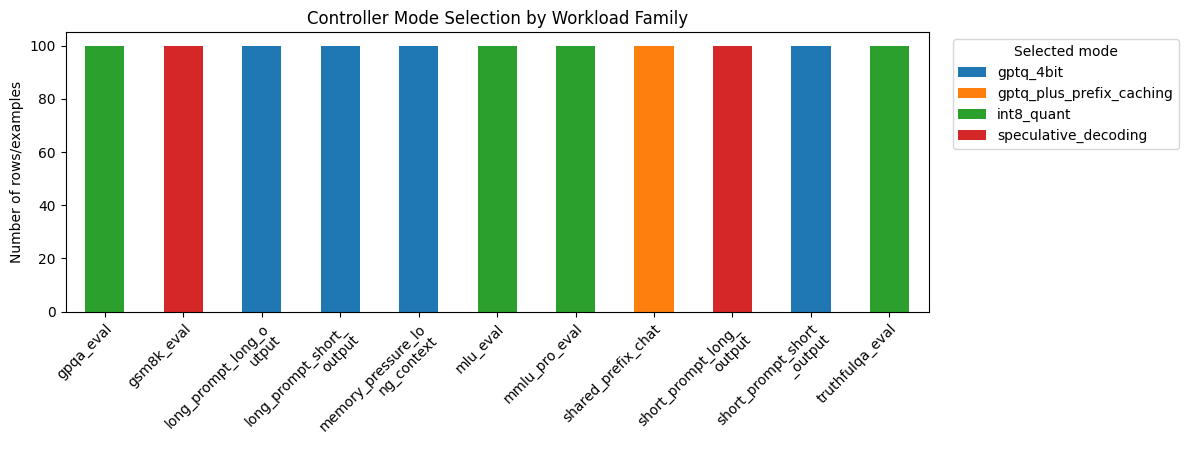

Saved: results/plots/controller_selection/mode_selection_by_workload_family.png


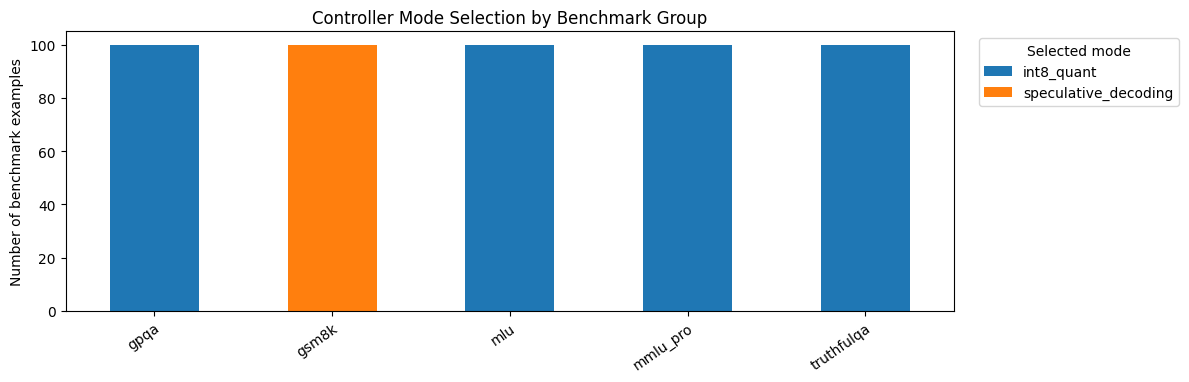

Saved: results/plots/controller_selection/mode_selection_by_benchmark_group.png


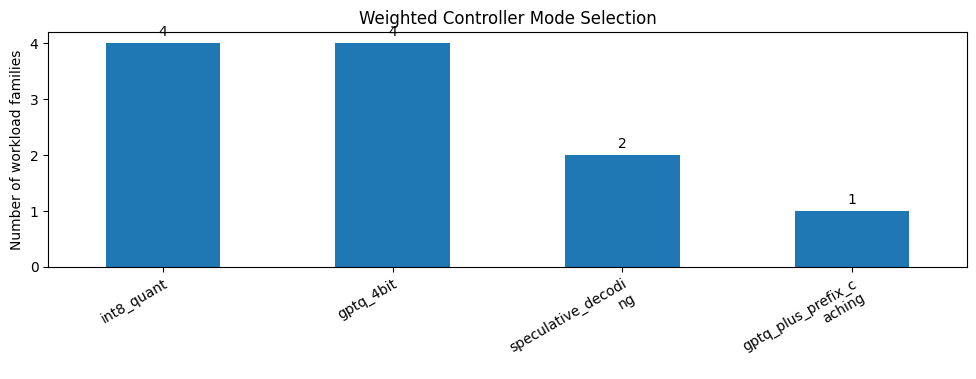

Saved: results/plots/controller_selection/weighted_mode_selection_one_vote_per_family.png


,base_workload_name,selected_mode,raw_rows
0,gpqa_eval,int8_quant,100
1,gsm8k_eval,speculative_decoding,100
2,long_prompt_long_output,gptq_4bit,100
3,long_prompt_short_output,gptq_4bit,100
4,memory_pressure_long_context,gptq_4bit,100
5,mlu_eval,int8_quant,100
6,mmlu_pro_eval,int8_quant,100
7,shared_prefix_chat,gptq_plus_prefix_caching,100
8,short_prompt_long_output,speculative_decoding,100
9,short_prompt_short_output,gptq_4bit,100


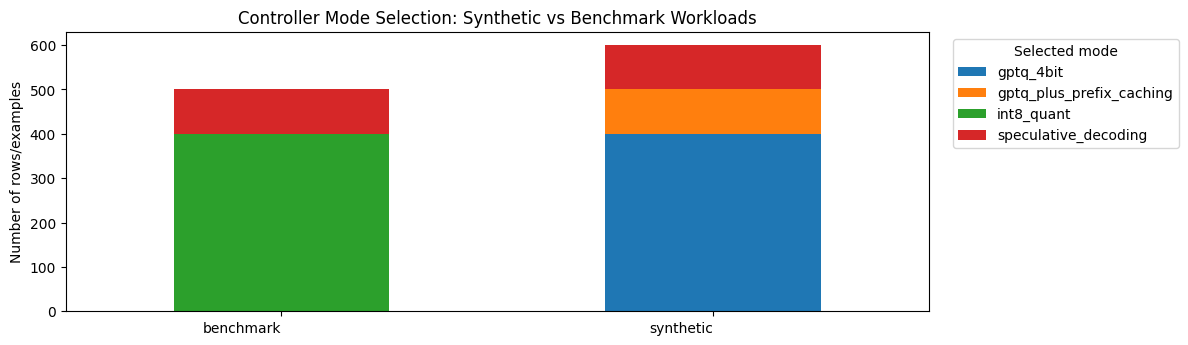

Saved: results/plots/controller_selection/mode_selection_synthetic_vs_benchmark.png


In [47]:
# ============================================================
# Better controller mode-selection figures
# ============================================================

import re
import textwrap
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ------------------------------------------------------------
# Pick the controller dataframe.
# Change this line if your dataframe has a different name.
# It must contain at least:
#   workload_name
#   controller_selected_mode_name
# ------------------------------------------------------------

controller_df = online_plan_df.copy()
controller_df = controller_df.rename(columns={"selected_mode_name": "controller_selected_mode_name"})

PLOT_DIR = Path("results/plots/controller_selection")
PLOT_DIR.mkdir(parents=True, exist_ok=True)


def base_workload_name(name):
    """
    Collapse sidecar-expanded and synthetic-variant workload names.

    Examples:
    mmlu_pro_eval__q0001 -> mmlu_pro_eval
    shared_prefix_chat_v17 -> shared_prefix_chat
    memory_pressure_long_context_v03 -> memory_pressure_long_context
    """
    name = str(name)

    if "__" in name:
        name = name.split("__", 1)[0]

    name = re.sub(r"_v\d+$", "", name)

    return name


def infer_workload_group(row):
    """
    Give each row a clean project-level group label.
    """
    workload = row["base_workload_name"]

    synthetic_workloads = {
        "short_prompt_short_output",
        "short_prompt_long_output",
        "long_prompt_short_output",
        "long_prompt_long_output",
        "shared_prefix_chat",
        "memory_pressure_long_context",
    }

    if workload in synthetic_workloads:
        return "synthetic"

    return "benchmark"


def infer_benchmark_group(row):
    """
    Prefer benchmark_suite if available; otherwise infer from workload name.
    """
    if "benchmark_suite" in row and pd.notna(row["benchmark_suite"]):
        return str(row["benchmark_suite"])

    workload = row["base_workload_name"]

    mapping = {
        "mmlu_pro_eval": "mmlu_pro",
        "gsm8k_eval": "gsm8k",
        "truthfulqa_eval": "truthfulqa",
        "gpqa_eval": "gpqa",
        "mlu_eval": "mlu",
        "mt_bench_eval": "mt_bench",
        "alpacaeval2_lc_eval": "alpacaeval2_lc",
    }

    return mapping.get(workload, workload)


# ------------------------------------------------------------
# Clean controller table
# ------------------------------------------------------------

plot_df = controller_df.copy()

plot_df["selected_mode"] = plot_df["controller_selected_mode_name"].fillna(
    plot_df.get("mode_name", "unknown")
)

plot_df["base_workload_name"] = plot_df["workload_name"].apply(base_workload_name)
plot_df["workload_group"] = plot_df.apply(infer_workload_group, axis=1)
plot_df["benchmark_group"] = plot_df.apply(infer_benchmark_group, axis=1)

display(plot_df[[
    "workload_name",
    "base_workload_name",
    "workload_group",
    "benchmark_group",
    "selected_mode",
]].head())


# ------------------------------------------------------------
# Helper plotting function
# ------------------------------------------------------------

def save_bar_plot(series, title, ylabel, filename, rotation=35):
    ax = series.plot(kind="bar", figsize=(10, 4))
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=rotation)

    wrapped_labels = [
        textwrap.fill(str(label), width=18)
        for label in series.index
    ]
    ax.set_xticklabels(
        wrapped_labels,
        rotation=rotation,
        ha="right",
        rotation_mode="anchor",
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=3)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.32)
    path = PLOT_DIR / filename
    plt.savefig(path, dpi=250, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


def save_stacked_bar_plot(table, title, ylabel, filename, rotation=35):
    ax = table.plot(kind="bar", stacked=True, figsize=(12, 4.8))
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")

    wrapped_labels = [
        textwrap.fill(str(label), width=18)
        for label in table.index
    ]
    ax.set_xticklabels(
        wrapped_labels,
        rotation=rotation,
        ha="right",
        rotation_mode="anchor",
    )
    ax.legend(title="Selected mode", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.34)
    path = PLOT_DIR / filename
    plt.savefig(path, dpi=250, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


# ============================================================
# Figure 1: Mode selection by workload family
# ============================================================

family_table = pd.crosstab(
    plot_df["base_workload_name"],
    plot_df["selected_mode"],
)

save_stacked_bar_plot(
    family_table,
    "Controller Mode Selection by Workload Family",
    "Number of rows/examples",
    "mode_selection_by_workload_family.png",
    rotation=45,
)


# ============================================================
# Figure 2: Mode selection by benchmark group
# ============================================================

benchmark_df = plot_df[plot_df["workload_group"] == "benchmark"].copy()

benchmark_table = pd.crosstab(
    benchmark_df["benchmark_group"],
    benchmark_df["selected_mode"],
)

save_stacked_bar_plot(
    benchmark_table,
    "Controller Mode Selection by Benchmark Group",
    "Number of benchmark examples",
    "mode_selection_by_benchmark_group.png",
    rotation=35,
)


# ============================================================
# Figure 3: Weighted mode selection
# One workload family = one vote
# ============================================================

weighted_rows = []

for family, group in plot_df.groupby("base_workload_name"):
    selected_mode = group["selected_mode"].mode().iloc[0]
    weighted_rows.append({
        "base_workload_name": family,
        "selected_mode": selected_mode,
        "raw_rows": len(group),
    })

weighted_df = pd.DataFrame(weighted_rows)

weighted_counts = weighted_df["selected_mode"].value_counts()

save_bar_plot(
    weighted_counts,
    "Weighted Controller Mode Selection",
    "Number of workload families",
    "weighted_mode_selection_one_vote_per_family.png",
    rotation=30,
)

display(weighted_df.sort_values("base_workload_name"))


# ============================================================
# Figure 4: Separate synthetic vs benchmark routing
# ============================================================

group_table = pd.crosstab(
    plot_df["workload_group"],
    plot_df["selected_mode"],
)

save_stacked_bar_plot(
    group_table,
    "Controller Mode Selection: Synthetic vs Benchmark Workloads",
    "Number of rows/examples",
    "mode_selection_synthetic_vs_benchmark.png",
    rotation=0,
)

In [33]:
family_counts = (
    plot_df
    .groupby("base_workload_name")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="num_rows")
)

display(family_counts)

,base_workload_name,num_rows
0,gpqa_eval,100
1,gsm8k_eval,100
2,long_prompt_long_output,100
3,long_prompt_short_output,100
4,memory_pressure_long_context,100
5,mlu_eval,100
6,mmlu_pro_eval,100
7,shared_prefix_chat,100
8,short_prompt_long_output,100
9,short_prompt_short_output,100


In [35]:
# ============================================================
# Recovery Cell A: Pin the exact run to recover
# ============================================================

from pathlib import Path
import json
import pandas as pd
import numpy as np
from IPython.display import display

from reporter import generate_full_report

PROJECT_ROOT = Path("/scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM")
RAW_RESULTS_DIR = PROJECT_ROOT / "results" / "raw"

DENSE_STAMP = "20260506_024532"
ONLINE_STAMP = "20260506_033243"

dense_json_path = RAW_RESULTS_DIR / f"dense_final_prejudge_results_{DENSE_STAMP}.json"
online_json_path = RAW_RESULTS_DIR / f"online_controller_results_{ONLINE_STAMP}.json"

dense_report_dir = RAW_RESULTS_DIR / f"dense_final_report_{DENSE_STAMP}"
combined_json_path = RAW_RESULTS_DIR / f"dense_final_plus_online_controller_{DENSE_STAMP}_{ONLINE_STAMP}.json"
combined_report_dir = RAW_RESULTS_DIR / f"dense_final_plus_online_controller_report_{DENSE_STAMP}_{ONLINE_STAMP}"

print("Dense JSON:", dense_json_path, dense_json_path.exists())
print("Online JSON:", online_json_path, online_json_path.exists())
print("Dense report:", dense_report_dir, dense_report_dir.exists())
print("Combined JSON:", combined_json_path, combined_json_path.exists())
print("Combined report:", combined_report_dir, combined_report_dir.exists())

if not dense_json_path.exists():
    raise FileNotFoundError(dense_json_path)

if not online_json_path.exists():
    raise FileNotFoundError(online_json_path)

Dense JSON: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_prejudge_results_20260506_024532.json True
Online JSON: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/online_controller_results_20260506_033243.json True
Dense report: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_report_20260506_024532 True
Combined JSON: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_plus_online_controller_20260506_024532_20260506_033243.json True
Combined report: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_plus_online_controller_report_20260506_024532_20260506_033243 True


In [36]:
# ============================================================
# Recovery Cell B: Load exact raw result rows
# ============================================================

with open(dense_json_path, "r", encoding="utf-8") as f:
    dense_raw_rows = json.load(f)

with open(online_json_path, "r", encoding="utf-8") as f:
    online_raw_rows = json.load(f)

dense_raw_df = pd.DataFrame(dense_raw_rows)
online_controller_df = pd.DataFrame(online_raw_rows)

print("Dense raw rows:", len(dense_raw_df))
print("Online controller raw rows:", len(online_controller_df))

display(dense_raw_df[["mode_name", "workload_name", "trial_index", "success"]].head())
display(online_controller_df[[
    "mode_name",
    "controller_selected_mode_name",
    "workload_name",
    "trial_index",
    "success",
]].head())

Dense raw rows: 27260
Online controller raw rows: 5920


,mode_name,workload_name,trial_index,success
0,fp16_baseline,short_prompt_short_output,0,True
1,fp16_baseline,short_prompt_short_output,1,True
2,fp16_baseline,short_prompt_short_output,2,True
3,fp16_baseline,short_prompt_short_output,3,True
4,fp16_baseline,short_prompt_short_output,4,True


,mode_name,controller_selected_mode_name,workload_name,trial_index,success
0,online_request_boundary_controller,speculative_decoding,short_prompt_short_output,0,True
1,online_request_boundary_controller,speculative_decoding,short_prompt_short_output,1,True
2,online_request_boundary_controller,speculative_decoding,short_prompt_short_output,2,True
3,online_request_boundary_controller,speculative_decoding,short_prompt_short_output,3,True
4,online_request_boundary_controller,speculative_decoding,short_prompt_short_output,4,True


In [37]:
# ============================================================
# Recovery Cell C: Rebuild combined JSON/report if needed
# ============================================================

ONLINE_CONTROLLER_MODE_NAME = "online_request_boundary_controller"

if not combined_json_path.exists():
    with open(combined_json_path, "w", encoding="utf-8") as f:
        json.dump(dense_raw_rows + online_raw_rows, f, indent=2, ensure_ascii=False)

    print("Recreated combined JSON:", combined_json_path)
else:
    print("Combined JSON already exists:", combined_json_path)

if not combined_report_dir.exists():
    combined_report_dir = Path(generate_full_report(
        input_path=combined_json_path,
        output_dir=combined_report_dir,
        quality_metric="auto",
    ))
    print("Recreated combined report:", combined_report_dir)
else:
    combined_report_dir = Path(combined_report_dir)
    print("Using existing combined report:", combined_report_dir)

combined_agg_df = pd.read_csv(combined_report_dir / "aggregated.csv")
combined_phase_df = pd.read_csv(combined_report_dir / "phase_dominance.csv")
combined_failure_df = pd.read_csv(combined_report_dir / "failure_summary.csv")

online_agg_df = combined_agg_df[
    combined_agg_df["mode_name"] == ONLINE_CONTROLLER_MODE_NAME
].copy()

print("Combined aggregated rows:", len(combined_agg_df))
print("Online controller aggregated rows:", len(online_agg_df))

display(online_agg_df[["mode_name", "workload_name", "n", "total_latency_ms_mean", "tokens_per_second_mean"]].head())

Combined JSON already exists: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_plus_online_controller_20260506_024532_20260506_033243.json
Using existing combined report: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/raw/dense_final_plus_online_controller_report_20260506_024532_20260506_033243
Combined aggregated rows: 276
Online controller aggregated rows: 59


,mode_name,workload_name,n,total_latency_ms_mean,tokens_per_second_mean
3,online_request_boundary_controller,gpqa_eval,500,50.589815,19.876880
9,online_request_boundary_controller,gsm8k_eval,1000,1274.175268,122.327429
18,online_request_boundary_controller,long_prompt_long_output,30,1432.999503,89.856469
27,online_request_boundary_controller,long_prompt_short_output,30,443.841363,72.105904
36,online_request_boundary_controller,memory_pressure_long_context_v0,30,1183.054908,108.203639


In [38]:
# ============================================================
# Recovery Cell D: Rebuild exact online-controller vs FP16 table
# ============================================================

fp16_combined_df = (
    combined_agg_df[combined_agg_df["mode_name"] == "fp16_baseline"]
    [[
        "workload_name",
        "total_latency_ms_mean",
        "tokens_per_second_mean",
        "energy_per_token_j_mean",
        "peak_gpu_memory_mb_mean",
    ]]
    .rename(columns={
        "total_latency_ms_mean": "fp16_total_latency_ms_mean",
        "tokens_per_second_mean": "fp16_tokens_per_second_mean",
        "energy_per_token_j_mean": "fp16_energy_per_token_j_mean",
        "peak_gpu_memory_mb_mean": "fp16_peak_gpu_memory_mb_mean",
    })
)

online_compare_df = online_agg_df.merge(
    fp16_combined_df,
    on="workload_name",
    how="inner",
)

routing_col = "controller_routing_overhead_ms_mean"
if routing_col not in online_compare_df.columns:
    online_compare_df[routing_col] = 0.0

online_compare_df["controller_total_latency_with_routing_ms_mean"] = (
    online_compare_df["total_latency_ms_mean"]
    + online_compare_df[routing_col].fillna(0.0)
)

online_compare_df["latency_speedup_with_routing"] = (
    online_compare_df["fp16_total_latency_ms_mean"]
    / online_compare_df["controller_total_latency_with_routing_ms_mean"]
)

online_compare_df["throughput_ratio"] = (
    online_compare_df["tokens_per_second_mean"]
    / online_compare_df["fp16_tokens_per_second_mean"]
)

online_compare_df["energy_ratio"] = (
    online_compare_df["energy_per_token_j_mean"]
    / online_compare_df["fp16_energy_per_token_j_mean"]
)

online_compare_df["memory_ratio"] = (
    online_compare_df["peak_gpu_memory_mb_mean"]
    / online_compare_df["fp16_peak_gpu_memory_mb_mean"]
)

online_compare_df = online_compare_df.sort_values(
    "latency_speedup_with_routing",
    ascending=False,
).reset_index(drop=True)

display(online_compare_df[[
    "workload_name",
    "controller_total_latency_with_routing_ms_mean",
    "fp16_total_latency_ms_mean",
    "latency_speedup_with_routing",
    "throughput_ratio",
    "energy_ratio",
    "memory_ratio",
]])

,workload_name,controller_total_latency_with_routing_ms_mean,fp16_total_latency_ms_mean,latency_speedup_with_routing,throughput_ratio,energy_ratio,memory_ratio
0,shared_prefix_chat_v5,507.000855,1406.517691,2.774192,2.774238,0.290360,1.007590
1,shared_prefix_chat_v2,514.093164,1416.706009,2.755738,2.758344,0.293286,1.007660
2,shared_prefix_chat_v7,506.257621,1394.329268,2.754189,2.754643,0.288842,1.007507
3,shared_prefix_chat_v3,510.319245,1402.146788,2.747588,2.747448,0.297960,1.007507
4,shared_prefix_chat_v6,511.011641,1401.172643,2.741958,2.741944,0.293386,1.007552
5,shared_prefix_chat_v4,509.007485,1392.356068,2.735433,2.735525,0.301691,1.007507
6,shared_prefix_chat_v1,515.714935,1409.486694,2.733073,2.735861,0.291840,1.007697
7,shared_prefix_chat_v0,515.178767,1405.438577,2.728060,2.730515,0.298959,1.007620
8,shared_prefix_chat_v8,508.716500,1377.621781,2.708034,2.707672,0.298614,1.007507
9,shared_prefix_chat_v9,510.261020,1367.599760,2.680196,2.680149,0.287493,1.007590


In [39]:
# ============================================================
# Recovery Cell E: Rebuild collapsed final summary
# ============================================================

def collapse_repeated_workload_name_for_tables(workload_name):
    return collapse_report_workload_name(workload_name)

def collapse_online_compare_for_summary(df):
    collapsed_df = df.copy()

    collapsed_df["collapsed_workload_name"] = collapsed_df["workload_name"].apply(
        collapse_repeated_workload_name_for_tables
    )

    numeric_cols = collapsed_df.select_dtypes(include=[np.number]).columns.tolist()

    return (
        collapsed_df
        .groupby("collapsed_workload_name", as_index=False)[numeric_cols]
        .mean()
        .rename(columns={"collapsed_workload_name": "workload_name"})
    )


online_compare_summary_df = collapse_online_compare_for_summary(online_compare_df)

online_headline_summary_df = pd.DataFrame([{
    "controller_evaluation_type": "online_request_boundary_routing_with_measured_routing_overhead",
    "num_logical_workloads": len(online_compare_summary_df),
    "mean_controller_total_latency_with_routing_ms": online_compare_summary_df["controller_total_latency_with_routing_ms_mean"].mean(),
    "mean_fp16_total_latency_ms": online_compare_summary_df["fp16_total_latency_ms_mean"].mean(),
    "mean_routing_overhead_ms": online_compare_summary_df["controller_routing_overhead_ms_mean"].mean(),
    "mean_latency_speedup_with_routing": online_compare_summary_df["latency_speedup_with_routing"].mean(),
    "mean_throughput_ratio": online_compare_summary_df["throughput_ratio"].mean(),
    "mean_energy_ratio": online_compare_summary_df["energy_ratio"].mean(),
    "mean_energy_reduction_pct": 100.0 * (1.0 - online_compare_summary_df["energy_ratio"].mean()),
    "mean_memory_ratio": online_compare_summary_df["memory_ratio"].mean(),
}])

online_paper_summary_display = pd.DataFrame([
    {
        "Metric": "Mean latency speedup vs FP16",
        "Value": f"{online_headline_summary_df.iloc[0]['mean_latency_speedup_with_routing']:.2f}×",
    },
    {
        "Metric": "Mean controller latency including routing",
        "Value": f"{online_headline_summary_df.iloc[0]['mean_controller_total_latency_with_routing_ms']:.2f} ms",
    },
    {
        "Metric": "Mean FP16 latency",
        "Value": f"{online_headline_summary_df.iloc[0]['mean_fp16_total_latency_ms']:.2f} ms",
    },
    {
        "Metric": "Mean routing overhead",
        "Value": f"{online_headline_summary_df.iloc[0]['mean_routing_overhead_ms']:.4f} ms",
    },
    {
        "Metric": "Mean throughput ratio vs FP16",
        "Value": f"{online_headline_summary_df.iloc[0]['mean_throughput_ratio']:.2f}×",
    },
    {
        "Metric": "Mean energy ratio vs FP16",
        "Value": (
            f"{online_headline_summary_df.iloc[0]['mean_energy_ratio']:.2f}× "
            f"({online_headline_summary_df.iloc[0]['mean_energy_reduction_pct']:.1f}% lower)"
        ),
    },
    {
        "Metric": "Mean GPU memory ratio vs FP16",
        "Value": f"{online_headline_summary_df.iloc[0]['mean_memory_ratio']:.3f}×",
    },
])

display(online_paper_summary_display)
display(online_compare_summary_df[[
    "workload_name",
    "controller_total_latency_with_routing_ms_mean",
    "fp16_total_latency_ms_mean",
    "latency_speedup_with_routing",
    "throughput_ratio",
    "energy_ratio",
    "memory_ratio",
]])

,Metric,Value
0,Mean latency speedup vs FP16,1.74×
1,Mean controller latency including routing,613.53 ms
2,Mean FP16 latency,1295.80 ms
3,Mean routing overhead,0.0000 ms
4,Mean throughput ratio vs FP16,1.74×
5,Mean energy ratio vs FP16,0.59× (41.3% lower)
6,Mean GPU memory ratio vs FP16,1.007×


,workload_name,controller_total_latency_with_routing_ms_mean,fp16_total_latency_ms_mean,latency_speedup_with_routing,throughput_ratio,energy_ratio,memory_ratio
0,gpqa_eval,50.589815,53.611072,1.059721,1.043481,0.762398,1.006294
1,gsm8k_eval,1274.175268,3097.149247,2.430709,2.451578,0.403046,1.006329
2,long_prompt_long_output,1432.999503,2727.091607,1.903065,1.914282,0.540608,1.009284
3,long_prompt_short_output,443.841363,751.536719,1.693255,1.693317,0.551613,1.006263
4,memory_pressure_long_context,1179.321979,2708.885952,2.296999,2.296986,0.464864,1.006636
5,mlu_eval,49.609342,51.108888,1.030227,1.010757,0.810036,1.006667
6,mmlu_pro_eval,49.940471,52.887388,1.059009,1.044950,0.741413,1.006668
7,shared_prefix_chat,510.756123,1397.337528,2.735846,2.736634,0.294243,1.007574
8,short_prompt_long_output,1366.222564,2682.208007,1.963229,1.963102,0.520503,1.009483
9,short_prompt_short_output,343.646821,686.973315,1.999068,2.003811,0.528802,1.009575


Raw selected-mode counts:


,selected_mode,num_routes
0,int8_quant,3330
1,speculative_decoding,1090
2,gptq_plus_prefix_caching,750
3,gptq_4bit,750


One vote per workload family:


,workload_family,selected_mode,raw_rows
0,gpqa_eval,int8_quant,500
1,gsm8k_eval,speculative_decoding,1000
2,long_prompt_long_output,speculative_decoding,30
3,long_prompt_short_output,int8_quant,30
4,memory_pressure_long_context,gptq_4bit,750
5,mlu_eval,int8_quant,1000
6,mmlu_pro_eval,int8_quant,1000
7,shared_prefix_chat,gptq_plus_prefix_caching,750
8,short_prompt_long_output,speculative_decoding,30
9,short_prompt_short_output,speculative_decoding,30


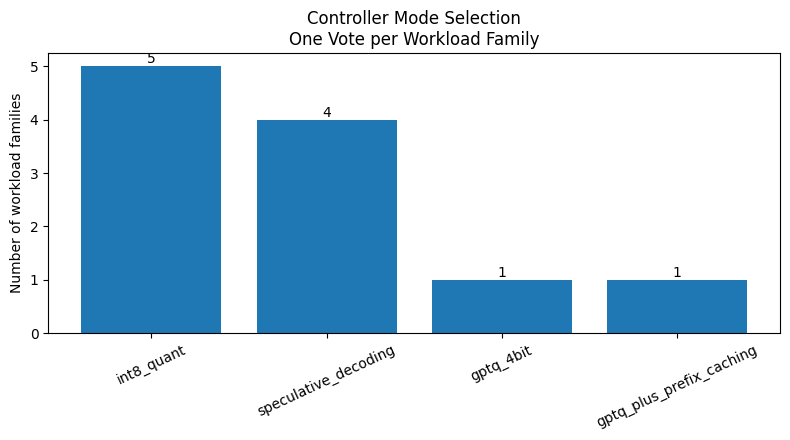

Saved: /scratch/as18181/ModeSwitch-LLM/ModeSwitch-LLM/results/plots/presentation_checks/controller_mode_selection_one_vote_per_family.png


In [40]:
# ============================================================
# Recovery Cell F: Clean controller mode-selection counts
# ============================================================

import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

PRESENTATION_PLOT_DIR = PROJECT_ROOT / "results" / "plots" / "presentation_checks"
PRESENTATION_PLOT_DIR.mkdir(parents=True, exist_ok=True)

# This is the correct dataframe from your recovery cells.
controller_df = online_controller_df.copy()

if "controller_selected_mode_name" not in controller_df.columns:
    raise KeyError("online_controller_df does not have controller_selected_mode_name")

controller_df = controller_df[controller_df["success"] == True].copy()

def base_workload_name(name):
    name = str(name)

    # benchmark examples: gsm8k_eval__gsm8k_0012 -> gsm8k_eval
    if "__" in name:
        name = name.split("__", 1)[0]

    # synthetic variants: shared_prefix_chat_v7 -> shared_prefix_chat
    name = re.sub(r"_v\d+$", "", name)

    return name

synthetic_families = {
    "short_prompt_short_output",
    "short_prompt_long_output",
    "long_prompt_short_output",
    "long_prompt_long_output",
    "shared_prefix_chat",
    "memory_pressure_long_context",
}

controller_df["base_workload_name"] = controller_df["workload_name"].apply(base_workload_name)
controller_df["selected_mode"] = controller_df["controller_selected_mode_name"]
controller_df["workload_type"] = np.where(
    controller_df["base_workload_name"].isin(synthetic_families),
    "synthetic",
    "benchmark",
)

print("Raw selected-mode counts:")
raw_mode_counts = (
    controller_df["selected_mode"]
    .value_counts()
    .rename_axis("selected_mode")
    .reset_index(name="num_routes")
)
display(raw_mode_counts)

print("One vote per workload family:")
weighted_rows = []
for workload_family, group in controller_df.groupby("base_workload_name"):
    weighted_rows.append({
        "workload_family": workload_family,
        "selected_mode": group["selected_mode"].mode().iloc[0],
        "raw_rows": len(group),
    })

weighted_mode_df = pd.DataFrame(weighted_rows).sort_values("workload_family")
display(weighted_mode_df)

weighted_counts = (
    weighted_mode_df["selected_mode"]
    .value_counts()
    .rename_axis("selected_mode")
    .reset_index(name="num_workload_families")
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(weighted_counts["selected_mode"], weighted_counts["num_workload_families"])
ax.set_title("Controller Mode Selection\nOne Vote per Workload Family")
ax.set_ylabel("Number of workload families")
ax.tick_params(axis="x", rotation=25)

for i, value in enumerate(weighted_counts["num_workload_families"]):
    ax.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
save_path = PRESENTATION_PLOT_DIR / "controller_mode_selection_one_vote_per_family.png"
plt.savefig(save_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

In [41]:
# ============================================================
# Recovery Cell G: Accuracy-aware oracle check
# ============================================================

QUALITY_DROP_TOLERANCE_PTS = 1.5

AUTOMATIC_BENCHMARK_METRIC_MAP = {
    "mmlu_pro_eval": "mmlu_pro_accuracy_mean",
    "gsm8k_eval": "gsm8k_exact_match_accuracy_mean",
    "truthfulqa_eval": "truthfulqa_accuracy_mean",
    "gpqa_eval": "gpqa_accuracy_mean",
    "mlu_eval": "mlu_accuracy_mean",
}

oracle_rows = []

for workload_name, metric_col in AUTOMATIC_BENCHMARK_METRIC_MAP.items():
    sub = combined_agg_df[combined_agg_df["workload_name"] == workload_name].copy()

    fixed_sub = sub[sub["mode_name"] != ONLINE_CONTROLLER_MODE_NAME].copy()
    online_sub = sub[sub["mode_name"] == ONLINE_CONTROLLER_MODE_NAME].copy()

    if len(fixed_sub) == 0 or len(online_sub) == 0:
        print("Skipping missing workload:", workload_name)
        continue

    if metric_col not in fixed_sub.columns:
        print("Skipping missing metric:", metric_col)
        continue

    fp16_row = fixed_sub[fixed_sub["mode_name"] == "fp16_baseline"].iloc[0]
    online_row = online_sub.iloc[0]

    # selected mode from raw online rows
    raw_selected = controller_df[
        controller_df["base_workload_name"] == workload_name
    ]["selected_mode"]

    selected_mode = raw_selected.mode().iloc[0] if len(raw_selected) else "unknown"

    fp16_accuracy_pct = 100.0 * float(fp16_row[metric_col])
    online_accuracy_pct = 100.0 * float(online_row[metric_col])

    fixed_sub["accuracy_pct"] = 100.0 * fixed_sub[metric_col].astype(float)
    fixed_sub["accuracy_delta_vs_fp16_pts"] = fixed_sub["accuracy_pct"] - fp16_accuracy_pct

    # Unconstrained oracle: fastest mode, even if accuracy drops.
    latency_oracle = fixed_sub.sort_values("total_latency_ms_mean").iloc[0]
    energy_oracle = fixed_sub.sort_values("energy_per_token_j_mean").iloc[0]

    # Accuracy-aware oracle: fastest/lowest-energy mode that stays within 1.5 pts of FP16.
    quality_safe_sub = fixed_sub[
        fixed_sub["accuracy_delta_vs_fp16_pts"] >= -QUALITY_DROP_TOLERANCE_PTS
    ].copy()

    if len(quality_safe_sub) == 0:
        quality_safe_latency_oracle = latency_oracle
        quality_safe_energy_oracle = energy_oracle
    else:
        quality_safe_latency_oracle = quality_safe_sub.sort_values("total_latency_ms_mean").iloc[0]
        quality_safe_energy_oracle = quality_safe_sub.sort_values("energy_per_token_j_mean").iloc[0]

    oracle_rows.append({
        "workload_name": workload_name,
        "selected_mode": selected_mode,

        "fp16_accuracy_pct": fp16_accuracy_pct,
        "online_accuracy_pct": online_accuracy_pct,
        "online_accuracy_delta_pts": online_accuracy_pct - fp16_accuracy_pct,

        "online_latency_ms": online_row["total_latency_ms_mean"],
        "fp16_latency_ms": fp16_row["total_latency_ms_mean"],
        "online_speedup_vs_fp16": fp16_row["total_latency_ms_mean"] / online_row["total_latency_ms_mean"],

        "unconstrained_latency_oracle_mode": latency_oracle["mode_name"],
        "unconstrained_latency_oracle_accuracy_delta_pts": latency_oracle["accuracy_delta_vs_fp16_pts"],
        "unconstrained_latency_oracle_speedup_vs_fp16": fp16_row["total_latency_ms_mean"] / latency_oracle["total_latency_ms_mean"],

        "quality_safe_latency_oracle_mode": quality_safe_latency_oracle["mode_name"],
        "quality_safe_latency_oracle_accuracy_delta_pts": quality_safe_latency_oracle["accuracy_delta_vs_fp16_pts"],
        "quality_safe_latency_oracle_speedup_vs_fp16": fp16_row["total_latency_ms_mean"] / quality_safe_latency_oracle["total_latency_ms_mean"],
        "controller_latency_vs_quality_safe_oracle": online_row["total_latency_ms_mean"] / quality_safe_latency_oracle["total_latency_ms_mean"],

        "online_energy_ratio_vs_fp16": online_row["energy_per_token_j_mean"] / fp16_row["energy_per_token_j_mean"],
        "quality_safe_energy_oracle_mode": quality_safe_energy_oracle["mode_name"],
        "quality_safe_energy_oracle_ratio_vs_fp16": quality_safe_energy_oracle["energy_per_token_j_mean"] / fp16_row["energy_per_token_j_mean"],
        "controller_energy_vs_quality_safe_oracle": online_row["energy_per_token_j_mean"] / quality_safe_energy_oracle["energy_per_token_j_mean"],
    })

quality_oracle_df = pd.DataFrame(oracle_rows)

display(quality_oracle_df)

print("Mean online speedup vs FP16:", quality_oracle_df["online_speedup_vs_fp16"].mean())
print("Mean quality-safe oracle speedup vs FP16:", quality_oracle_df["quality_safe_latency_oracle_speedup_vs_fp16"].mean())
print("Mean controller latency / quality-safe oracle latency:", quality_oracle_df["controller_latency_vs_quality_safe_oracle"].mean())

,workload_name,selected_mode,fp16_accuracy_pct,online_accuracy_pct,online_accuracy_delta_pts,online_latency_ms,fp16_latency_ms,online_speedup_vs_fp16,unconstrained_latency_oracle_mode,unconstrained_latency_oracle_accuracy_delta_pts,unconstrained_latency_oracle_speedup_vs_fp16,quality_safe_latency_oracle_mode,quality_safe_latency_oracle_accuracy_delta_pts,quality_safe_latency_oracle_speedup_vs_fp16,controller_latency_vs_quality_safe_oracle,online_energy_ratio_vs_fp16,quality_safe_energy_oracle_mode,quality_safe_energy_oracle_ratio_vs_fp16,controller_energy_vs_quality_safe_oracle
0,mmlu_pro_eval,int8_quant,34.6,34.900,0.300,49.940471,52.887388,1.059009,int8_quant,0.3,1.092611,int8_quant,0.3,1.092611,1.031730,0.741413,int8_quant,0.777395,0.953715
1,gsm8k_eval,speculative_decoding,83.1,83.100,0.000,1274.175268,3097.149247,2.430709,gptq_4bit,-2.5,2.868821,speculative_decoding,0.0,2.484247,1.022026,0.403046,speculative_decoding,0.413538,0.974627
2,truthfulqa_eval,int8_quant,56.0,55.625,-0.375,47.698746,45.029365,0.944037,fp16_baseline,0.0,1.000000,fp16_baseline,0.0,1.000000,1.059281,0.841850,int8_quant,0.829822,1.014495
3,gpqa_eval,int8_quant,27.4,28.000,0.600,50.589815,53.611072,1.059721,int8_quant,0.6,1.100377,int8_quant,0.6,1.100377,1.038365,0.762398,int8_quant,0.761147,1.001643
4,mlu_eval,int8_quant,48.2,48.500,0.300,49.609342,51.108888,1.030227,int8_quant,0.3,1.056925,int8_quant,0.3,1.056925,1.025914,0.810036,int8_quant,0.816451,0.992144


Mean online speedup vs FP16: 1.3047403932440644
Mean quality-safe oracle speedup vs FP16: 1.3468321248716364
Mean controller latency / quality-safe oracle latency: 1.0354633554384092


,workload_name,quality_type,selected_mode,online_speedup_vs_fp16,online_energy_reduction_pct,online_memory_ratio_vs_fp16,online_constraint_safe,constraint_oracle_mode,constraint_oracle_speedup_vs_fp16,constraint_oracle_energy_reduction_pct,constraint_oracle_memory_ratio_vs_fp16,controller_latency_vs_constraint_oracle,controller_energy_vs_constraint_oracle
0,shared_prefix_avg,synthetic ROUGE proxy,gptq_plus_prefix_caching,2.741280,70.600086,1.007554,True,gptq_plus_prefix_caching,2.851062,71.597386,1.007025,1.040048,1.035113
1,gsm8k_eval,benchmark accuracy,NaN,2.430709,59.695432,1.006329,True,speculative_decoding,2.484247,58.646179,1.006837,1.022026,0.974627
2,memory_pressure_avg,synthetic ROUGE proxy,gptq_4bit,2.300629,53.535784,1.006630,True,gptq_4bit,2.384389,52.708916,1.005265,1.036408,0.982515
3,short_prompt_short_output,synthetic ROUGE proxy,speculative_decoding,1.999068,47.119777,1.009575,True,speculative_decoding,1.990196,47.435838,1.006923,0.995562,1.006013
4,short_prompt_long_output,synthetic ROUGE proxy,speculative_decoding,1.963229,47.949671,1.009483,True,gptq_4bit,2.872115,61.682906,1.009418,1.462954,1.358410
5,long_prompt_long_output,synthetic ROUGE proxy,speculative_decoding,1.903065,45.939159,1.009284,True,gptq_4bit,2.641278,57.007828,1.008099,1.387907,1.257458
6,long_prompt_short_output,synthetic ROUGE proxy,int8_quant,1.693255,44.838675,1.006263,False,gptq_4bit,2.154126,45.393285,1.008099,1.272180,1.010156
7,gpqa_eval,benchmark accuracy,NaN,1.059721,23.760227,1.006294,True,int8_quant,1.100377,23.885268,1.005308,1.038365,1.001643
8,mmlu_pro_eval,benchmark accuracy,NaN,1.059009,25.858667,1.006668,True,int8_quant,1.092611,22.260463,1.005310,1.031730,0.953715
9,mlu_eval,benchmark accuracy,NaN,1.030227,18.996359,1.006667,True,int8_quant,1.056925,18.354940,1.005308,1.025914,0.992144


Mean online speedup vs FP16: 1.7385662169624916
Mean constraint-aware oracle speedup vs FP16: 1.9661205889305904
Mean online energy reduction %: 41.28261730148634
Mean constraint-aware oracle energy reduction %: 41.72481902340391
Mean controller latency / constraint-aware oracle latency: 1.124761441387269


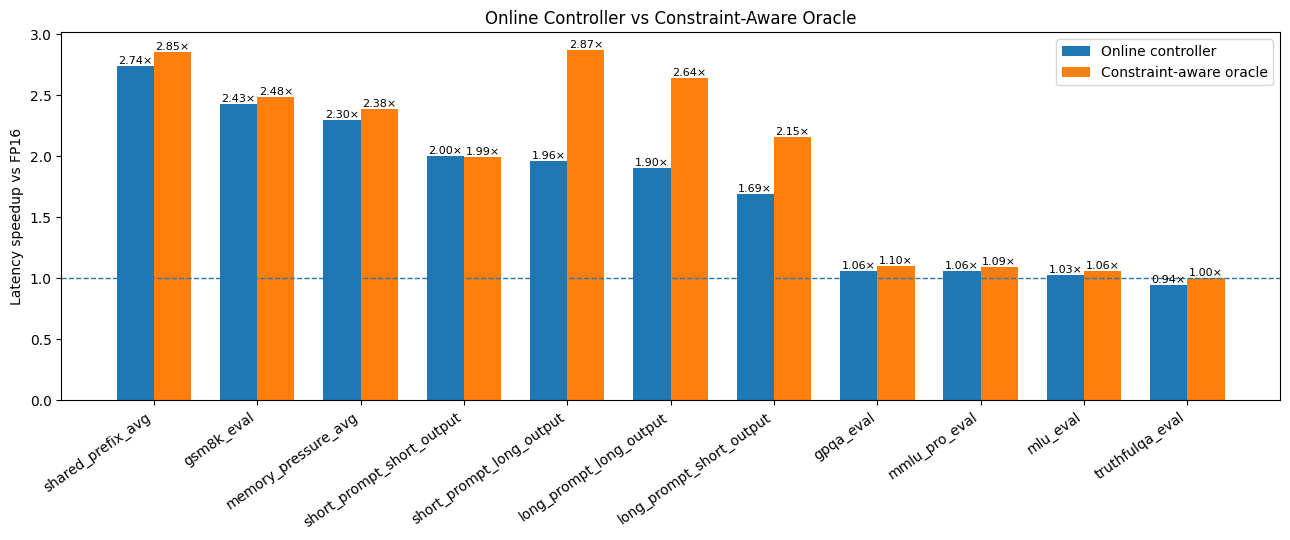

Saved: results/plots/presentation/online_controller_vs_constraint_aware_oracle_latency.png


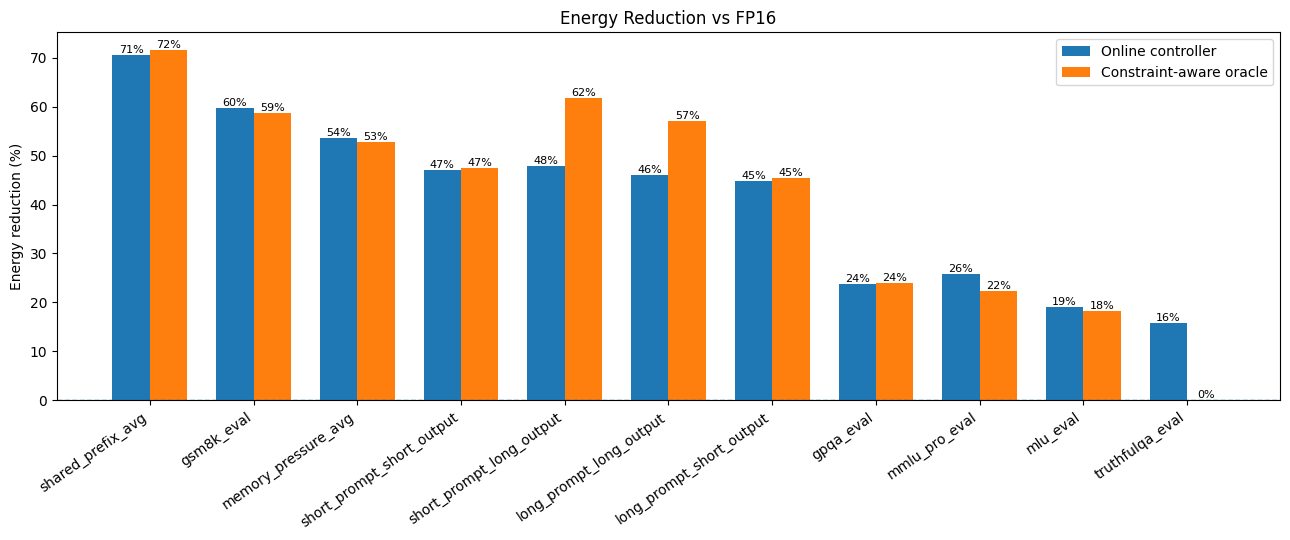

Saved: results/plots/presentation/online_controller_vs_constraint_aware_oracle_energy.png


In [42]:
# ============================================================
# Constraint-aware oracle for ALL workloads
# Checks: quality + energy + memory, then picks fastest mode
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PRESENTATION_PLOT_DIR = Path("results/plots/presentation")
PRESENTATION_PLOT_DIR.mkdir(parents=True, exist_ok=True)

ONLINE_CONTROLLER_MODE_NAME = "online_request_boundary_controller"

# -----------------------------
# Constraint thresholds
# -----------------------------
MAX_BENCHMARK_ACCURACY_DROP_PTS = 1.5

MIN_SYNTHETIC_SIMILARITY_TO_FP16 = 0.80
MAX_SYNTHETIC_REFERENCE_ROUGE_DROP = 0.02

# Energy must not be worse than FP16
MAX_ENERGY_RATIO_VS_FP16 = 1.00

# Memory must stay close to FP16
MAX_MEMORY_RATIO_VS_FP16 = 1.02

BENCHMARK_METRIC_MAP = {
    "mmlu_pro_eval": "mmlu_pro_accuracy_mean",
    "gsm8k_eval": "gsm8k_exact_match_accuracy_mean",
    "truthfulqa_eval": "truthfulqa_accuracy_mean",
    "gpqa_eval": "gpqa_accuracy_mean",
    "mlu_eval": "mlu_accuracy_mean",
}


def collapse_workload_name(name):
    name = str(name)

    if name.startswith("shared_prefix_chat"):
        return "shared_prefix_avg"

    if name.startswith("memory_pressure_long_context"):
        return "memory_pressure_avg"

    return name


def mode_of_series(s):
    s = s.dropna()
    if len(s) == 0:
        return "unknown"
    return s.mode().iloc[0]


# ============================================================
# 1. Collapse fixed-mode results
# ============================================================

fixed_df = combined_agg_df[
    combined_agg_df["mode_name"] != ONLINE_CONTROLLER_MODE_NAME
].copy()

fixed_df["workload_clean"] = fixed_df["workload_name"].apply(collapse_workload_name)

fixed_numeric_cols = fixed_df.select_dtypes(include=[np.number]).columns.tolist()

fixed_collapsed_df = (
    fixed_df
    .groupby(["workload_clean", "mode_name"], as_index=False)[fixed_numeric_cols]
    .mean()
)


# ============================================================
# 2. Collapse online-controller results
# ============================================================

online_agg_df = combined_agg_df[
    combined_agg_df["mode_name"] == ONLINE_CONTROLLER_MODE_NAME
].copy()

online_agg_df["workload_clean"] = online_agg_df["workload_name"].apply(collapse_workload_name)

online_numeric_cols = online_agg_df.select_dtypes(include=[np.number]).columns.tolist()

online_collapsed_df = (
    online_agg_df
    .groupby("workload_clean", as_index=False)[online_numeric_cols]
    .mean()
)

if "online_controller_df" in globals() and "controller_selected_mode_name" in online_controller_df.columns:
    selected_mode_df = online_controller_df.copy()
    selected_mode_df["workload_clean"] = selected_mode_df["workload_name"].apply(collapse_workload_name)

    selected_mode_df = (
        selected_mode_df
        .groupby("workload_clean")["controller_selected_mode_name"]
        .agg(mode_of_series)
        .reset_index()
        .rename(columns={"controller_selected_mode_name": "selected_mode"})
    )

    online_collapsed_df = online_collapsed_df.merge(
        selected_mode_df,
        on="workload_clean",
        how="left",
    )
else:
    online_collapsed_df["selected_mode"] = "online_controller"


# ============================================================
# 3. Build constraint-aware oracle
# ============================================================

rows = []

all_workloads = sorted(
    set(fixed_collapsed_df["workload_clean"])
    & set(online_collapsed_df["workload_clean"])
)

for workload_name in all_workloads:
    candidates = fixed_collapsed_df[
        fixed_collapsed_df["workload_clean"] == workload_name
    ].copy()

    online_row = online_collapsed_df[
        online_collapsed_df["workload_clean"] == workload_name
    ]

    fp16_row = candidates[candidates["mode_name"] == "fp16_baseline"]

    if len(candidates) == 0 or len(online_row) == 0 or len(fp16_row) == 0:
        continue

    online_row = online_row.iloc[0]
    fp16_row = fp16_row.iloc[0]

    fp16_latency = fp16_row["total_latency_ms_mean"]
    fp16_energy = fp16_row["energy_per_token_j_mean"]
    fp16_memory = fp16_row["peak_gpu_memory_mb_mean"]

    online_latency = online_row["total_latency_ms_mean"]
    online_energy = online_row["energy_per_token_j_mean"]
    online_memory = online_row["peak_gpu_memory_mb_mean"]

    # --------------------------------------------------------
    # Energy + memory constraints for candidates
    # --------------------------------------------------------
    candidates["energy_ratio_vs_fp16"] = (
        candidates["energy_per_token_j_mean"] / fp16_energy
    )

    candidates["memory_ratio_vs_fp16"] = (
        candidates["peak_gpu_memory_mb_mean"] / fp16_memory
    )

    candidates["energy_safe"] = (
        candidates["energy_ratio_vs_fp16"] <= MAX_ENERGY_RATIO_VS_FP16
    )

    candidates["memory_safe"] = (
        candidates["memory_ratio_vs_fp16"] <= MAX_MEMORY_RATIO_VS_FP16
    )

    online_energy_ratio = online_energy / fp16_energy
    online_memory_ratio = online_memory / fp16_memory

    online_energy_safe = online_energy_ratio <= MAX_ENERGY_RATIO_VS_FP16
    online_memory_safe = online_memory_ratio <= MAX_MEMORY_RATIO_VS_FP16

    # --------------------------------------------------------
    # Quality constraint
    # --------------------------------------------------------
    if workload_name in BENCHMARK_METRIC_MAP:
        metric_col = BENCHMARK_METRIC_MAP[workload_name]
        quality_type = "benchmark accuracy"

        fp16_quality_pct = 100.0 * fp16_row[metric_col]

        candidates["quality_value"] = 100.0 * candidates[metric_col]
        candidates["quality_delta_vs_fp16"] = (
            candidates["quality_value"] - fp16_quality_pct
        )

        candidates["quality_safe"] = (
            candidates["quality_delta_vs_fp16"] >= -MAX_BENCHMARK_ACCURACY_DROP_PTS
        )

        online_quality_value = 100.0 * online_row[metric_col]
        online_quality_delta = online_quality_value - fp16_quality_pct
        online_quality_safe = online_quality_delta >= -MAX_BENCHMARK_ACCURACY_DROP_PTS

    else:
        quality_type = "synthetic ROUGE proxy"

        sim_col = "baseline_similarity_rouge_l_f1_mean"
        ref_col = "reference_rouge_l_f1_mean"

        has_sim = sim_col in candidates.columns and candidates[sim_col].notna().any()
        has_ref = ref_col in candidates.columns and pd.notna(fp16_row.get(ref_col, np.nan))

        if has_sim:
            candidates["similarity_to_fp16"] = candidates[sim_col]
        else:
            candidates["similarity_to_fp16"] = np.nan

        if has_ref:
            fp16_ref_rouge = fp16_row[ref_col]
            candidates["reference_rouge_delta_vs_fp16"] = (
                candidates[ref_col] - fp16_ref_rouge
            )
        else:
            candidates["reference_rouge_delta_vs_fp16"] = np.nan

        if has_sim and has_ref:
            candidates["quality_safe"] = (
                (candidates["similarity_to_fp16"] >= MIN_SYNTHETIC_SIMILARITY_TO_FP16)
                &
                (candidates["reference_rouge_delta_vs_fp16"] >= -MAX_SYNTHETIC_REFERENCE_ROUGE_DROP)
            )
        elif has_sim:
            candidates["quality_safe"] = (
                candidates["similarity_to_fp16"] >= MIN_SYNTHETIC_SIMILARITY_TO_FP16
            )
        elif has_ref:
            candidates["quality_safe"] = (
                candidates["reference_rouge_delta_vs_fp16"] >= -MAX_SYNTHETIC_REFERENCE_ROUGE_DROP
            )
        else:
            candidates["quality_safe"] = candidates["mode_name"].eq("fp16_baseline")

        candidates["quality_value"] = candidates["similarity_to_fp16"]
        candidates["quality_delta_vs_fp16"] = candidates["reference_rouge_delta_vs_fp16"]

        online_quality_value = online_row.get(sim_col, np.nan)
        online_ref_rouge = online_row.get(ref_col, np.nan)

        if has_ref and pd.notna(online_ref_rouge):
            online_quality_delta = online_ref_rouge - fp16_ref_rouge
        else:
            online_quality_delta = np.nan

        if has_sim and has_ref:
            online_quality_safe = (
                pd.notna(online_quality_value)
                and online_quality_value >= MIN_SYNTHETIC_SIMILARITY_TO_FP16
                and pd.notna(online_quality_delta)
                and online_quality_delta >= -MAX_SYNTHETIC_REFERENCE_ROUGE_DROP
            )
        elif has_sim:
            online_quality_safe = (
                pd.notna(online_quality_value)
                and online_quality_value >= MIN_SYNTHETIC_SIMILARITY_TO_FP16
            )
        elif has_ref:
            online_quality_safe = (
                pd.notna(online_quality_delta)
                and online_quality_delta >= -MAX_SYNTHETIC_REFERENCE_ROUGE_DROP
            )
        else:
            online_quality_safe = False

    # --------------------------------------------------------
    # Final constraint-aware oracle
    # --------------------------------------------------------
    candidates["constraint_safe"] = (
        candidates["quality_safe"]
        & candidates["energy_safe"]
        & candidates["memory_safe"]
    )

    safe_candidates = candidates[candidates["constraint_safe"]].copy()

    if len(safe_candidates) == 0:
        # FP16 should normally satisfy all constraints, but this is safe fallback.
        safe_candidates = candidates[candidates["mode_name"] == "fp16_baseline"].copy()

    oracle_row = (
        safe_candidates
        .sort_values("total_latency_ms_mean", ascending=True)
        .iloc[0]
    )

    online_constraint_safe = (
        online_quality_safe
        and online_energy_safe
        and online_memory_safe
    )

    rows.append({
        "workload_name": workload_name,
        "quality_type": quality_type,

        "selected_mode": online_row.get("selected_mode", "online_controller"),

        "fp16_latency_ms": fp16_latency,
        "fp16_energy": fp16_energy,
        "fp16_memory": fp16_memory,

        "online_latency_ms": online_latency,
        "online_speedup_vs_fp16": fp16_latency / online_latency,
        "online_energy_ratio_vs_fp16": online_energy_ratio,
        "online_energy_reduction_pct": 100.0 * (1.0 - online_energy_ratio),
        "online_memory_ratio_vs_fp16": online_memory_ratio,

        "online_quality_value": online_quality_value,
        "online_quality_delta_vs_fp16": online_quality_delta,
        "online_quality_safe": online_quality_safe,
        "online_energy_safe": online_energy_safe,
        "online_memory_safe": online_memory_safe,
        "online_constraint_safe": online_constraint_safe,

        "constraint_oracle_mode": oracle_row["mode_name"],
        "constraint_oracle_latency_ms": oracle_row["total_latency_ms_mean"],
        "constraint_oracle_speedup_vs_fp16": fp16_latency / oracle_row["total_latency_ms_mean"],
        "constraint_oracle_energy_ratio_vs_fp16": oracle_row["energy_ratio_vs_fp16"],
        "constraint_oracle_energy_reduction_pct": 100.0 * (1.0 - oracle_row["energy_ratio_vs_fp16"]),
        "constraint_oracle_memory_ratio_vs_fp16": oracle_row["memory_ratio_vs_fp16"],
        "constraint_oracle_quality_value": oracle_row.get("quality_value", np.nan),
        "constraint_oracle_quality_delta_vs_fp16": oracle_row.get("quality_delta_vs_fp16", np.nan),

        "controller_latency_vs_constraint_oracle": online_latency / oracle_row["total_latency_ms_mean"],
        "controller_energy_vs_constraint_oracle": online_energy_ratio / oracle_row["energy_ratio_vs_fp16"],
    })


constraint_oracle_all_df = pd.DataFrame(rows)


# ============================================================
# 4. Order and display
# ============================================================

workload_order = [
    "shared_prefix_avg",
    "gsm8k_eval",
    "memory_pressure_avg",
    "short_prompt_short_output",
    "short_prompt_long_output",
    "long_prompt_long_output",
    "long_prompt_short_output",
    "gpqa_eval",
    "mmlu_pro_eval",
    "mlu_eval",
    "truthfulqa_eval",
]

constraint_oracle_all_df["order"] = constraint_oracle_all_df["workload_name"].apply(
    lambda x: workload_order.index(x) if x in workload_order else 999
)

constraint_oracle_all_df = (
    constraint_oracle_all_df
    .sort_values("order")
    .reset_index(drop=True)
)

display_cols = [
    "workload_name",
    "quality_type",
    "selected_mode",
    "online_speedup_vs_fp16",
    "online_energy_reduction_pct",
    "online_memory_ratio_vs_fp16",
    "online_constraint_safe",
    "constraint_oracle_mode",
    "constraint_oracle_speedup_vs_fp16",
    "constraint_oracle_energy_reduction_pct",
    "constraint_oracle_memory_ratio_vs_fp16",
    "controller_latency_vs_constraint_oracle",
    "controller_energy_vs_constraint_oracle",
]

display(constraint_oracle_all_df[display_cols])

print("Mean online speedup vs FP16:",
      constraint_oracle_all_df["online_speedup_vs_fp16"].mean())

print("Mean constraint-aware oracle speedup vs FP16:",
      constraint_oracle_all_df["constraint_oracle_speedup_vs_fp16"].mean())

print("Mean online energy reduction %:",
      constraint_oracle_all_df["online_energy_reduction_pct"].mean())

print("Mean constraint-aware oracle energy reduction %:",
      constraint_oracle_all_df["constraint_oracle_energy_reduction_pct"].mean())

print("Mean controller latency / constraint-aware oracle latency:",
      constraint_oracle_all_df["controller_latency_vs_constraint_oracle"].mean())


# ============================================================
# 5. Plot 1: latency speedup comparison
# ============================================================

plot_df = constraint_oracle_all_df.copy()

x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.bar(
    x - width / 2,
    plot_df["online_speedup_vs_fp16"],
    width,
    label="Online controller",
)

ax.bar(
    x + width / 2,
    plot_df["constraint_oracle_speedup_vs_fp16"],
    width,
    label="Constraint-aware oracle",
)

ax.axhline(1.0, linestyle="--", linewidth=1)

ax.set_title("Online Controller vs Constraint-Aware Oracle")
ax.set_ylabel("Latency speedup vs FP16")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["workload_name"], rotation=35, ha="right")
ax.legend()

for i, value in enumerate(plot_df["online_speedup_vs_fp16"]):
    ax.text(i - width / 2, value, f"{value:.2f}×", ha="center", va="bottom", fontsize=8)

for i, value in enumerate(plot_df["constraint_oracle_speedup_vs_fp16"]):
    ax.text(i + width / 2, value, f"{value:.2f}×", ha="center", va="bottom", fontsize=8)

plt.tight_layout()

save_path = PRESENTATION_PLOT_DIR / "online_controller_vs_constraint_aware_oracle_latency.png"
plt.savefig(save_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", save_path)


# ============================================================
# 6. Plot 2: energy reduction comparison
# ============================================================

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.bar(
    x - width / 2,
    plot_df["online_energy_reduction_pct"],
    width,
    label="Online controller",
)

ax.bar(
    x + width / 2,
    plot_df["constraint_oracle_energy_reduction_pct"],
    width,
    label="Constraint-aware oracle",
)

ax.axhline(0.0, linestyle="--", linewidth=1)

ax.set_title("Energy Reduction vs FP16")
ax.set_ylabel("Energy reduction (%)")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["workload_name"], rotation=35, ha="right")
ax.legend()

for i, value in enumerate(plot_df["online_energy_reduction_pct"]):
    ax.text(i - width / 2, value, f"{value:.0f}%", ha="center", va="bottom", fontsize=8)

for i, value in enumerate(plot_df["constraint_oracle_energy_reduction_pct"]):
    ax.text(i + width / 2, value, f"{value:.0f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()

save_path = PRESENTATION_PLOT_DIR / "online_controller_vs_constraint_aware_oracle_energy.png"
plt.savefig(save_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

,workload_name,selected_mode,constraint_oracle_mode,online_weighted_score,oracle_weighted_score,online_speedup_vs_fp16,constraint_oracle_speedup_vs_fp16,online_energy_reduction_pct,constraint_oracle_energy_reduction_pct,online_memory_ratio_vs_fp16,constraint_oracle_memory_ratio_vs_fp16,online_quality_safe
0,shared_prefix_avg,gptq_plus_prefix_caching,gptq_plus_prefix_caching,98.037070,99.758115,2.741280,2.851062,70.600086,71.597386,1.007554,1.007025,True
1,gsm8k_eval,NaN,speculative_decoding,89.442604,89.574136,2.430709,2.484247,59.695432,58.646179,1.006329,1.006837,True
2,memory_pressure_avg,gptq_4bit,gptq_4bit,85.108964,85.690240,2.300629,2.384389,53.535784,52.708916,1.006630,1.005265,True
3,short_prompt_short_output,speculative_decoding,speculative_decoding,78.686883,78.730623,1.999068,1.990196,47.119777,47.435838,1.009575,1.006923,True
4,short_prompt_long_output,speculative_decoding,gptq_4bit,78.657611,95.430310,1.963229,2.872115,47.949671,61.682906,1.009483,1.009418,True
5,long_prompt_long_output,speculative_decoding,gptq_4bit,77.039674,90.623250,1.903065,2.641278,45.939159,57.007828,1.009284,1.008099,True
6,long_prompt_short_output,int8_quant,gptq_4bit,40.121776,79.672709,1.693255,2.154126,44.838675,45.393285,1.006263,1.008099,False
7,gpqa_eval,NaN,int8_quant,57.127313,57.652082,1.059721,1.100377,23.760227,23.885268,1.006294,1.005308,True
8,mmlu_pro_eval,NaN,int8_quant,58.086325,56.813963,1.059009,1.092611,25.858667,22.260463,1.006668,1.005310,True
9,mlu_eval,NaN,int8_quant,54.592720,54.603833,1.030227,1.056925,18.996359,18.354940,1.006667,1.005308,True


Mean online weighted score: 69.91
Mean oracle weighted score: 75.82


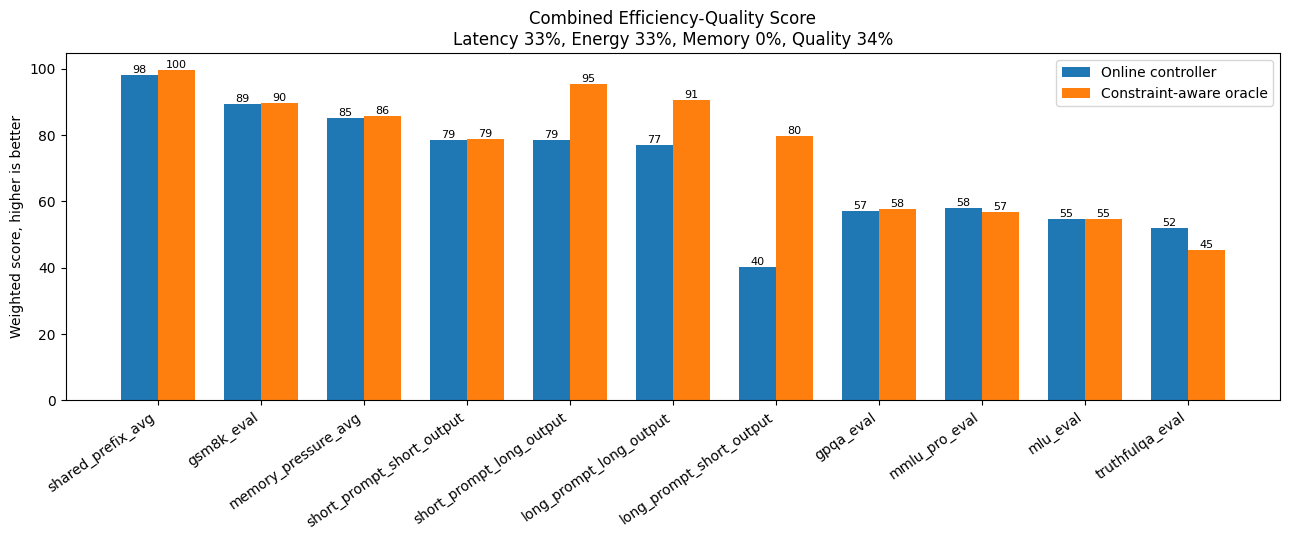

Saved: results/plots/presentation/combined_efficiency_quality_score.png


In [43]:
# ============================================================
# One combined weighted score plot
# Online controller vs constraint-aware oracle
# Combines latency + energy + memory + quality
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PRESENTATION_PLOT_DIR = Path("results/plots/presentation")
PRESENTATION_PLOT_DIR.mkdir(parents=True, exist_ok=True)

if "constraint_oracle_all_df" not in globals():
    raise RuntimeError("Run the constraint-aware oracle cell first.")

df = constraint_oracle_all_df.copy()

# ------------------------------------------------------------
# Weights for the combined score
# ------------------------------------------------------------
LATENCY_WEIGHT = 0.33
ENERGY_WEIGHT = 0.33
MEMORY_WEIGHT = 0.00
QUALITY_WEIGHT = 0.34

# Memory is not part of the main score.
# It is only used as a safety constraint/caveat because memory barely changes.
MEMORY_SAFE_RATIO = 1.02

# ------------------------------------------------------------
# Normalize latency and energy relative to the best observed values
# ------------------------------------------------------------
max_speedup = max(
    df["online_speedup_vs_fp16"].max(),
    df["constraint_oracle_speedup_vs_fp16"].max(),
)

max_energy_reduction = max(
    df["online_energy_reduction_pct"].max(),
    df["constraint_oracle_energy_reduction_pct"].max(),
)

def latency_score(speedup):
    return np.clip(speedup / max_speedup, 0, 1)

def energy_score(energy_reduction_pct):
    # Negative energy reduction gets 0 score.
    return np.clip(energy_reduction_pct / max_energy_reduction, 0, 1)

def memory_score(memory_ratio):
    # Full credit if memory is within 2% of FP16.
    # If worse than 2%, linearly penalize.
    if pd.isna(memory_ratio):
        return 0
    if memory_ratio <= MEMORY_SAFE_RATIO:
        return 1.0
    return max(0.0, 1.0 - (memory_ratio - MEMORY_SAFE_RATIO) / 0.03)

def quality_score(is_quality_safe):
    return 1.0 if bool(is_quality_safe) else 0.0

# ------------------------------------------------------------
# Online controller component scores
# ------------------------------------------------------------
df["online_latency_score"] = df["online_speedup_vs_fp16"].apply(latency_score)
df["online_energy_score"] = df["online_energy_reduction_pct"].apply(energy_score)
df["online_memory_score"] = df["online_memory_ratio_vs_fp16"].apply(memory_score)
df["online_quality_score"] = df["online_quality_safe"].apply(quality_score)

df["online_weighted_score"] = 100.0 * (
    LATENCY_WEIGHT * df["online_latency_score"]
    + ENERGY_WEIGHT * df["online_energy_score"]
    + MEMORY_WEIGHT * df["online_memory_score"]
    + QUALITY_WEIGHT * df["online_quality_score"]
)

# ------------------------------------------------------------
# Constraint-aware oracle component scores
# ------------------------------------------------------------
df["oracle_latency_score"] = df["constraint_oracle_speedup_vs_fp16"].apply(latency_score)
df["oracle_energy_score"] = df["constraint_oracle_energy_reduction_pct"].apply(energy_score)
df["oracle_memory_score"] = df["constraint_oracle_memory_ratio_vs_fp16"].apply(memory_score)

# Oracle is constraint-aware, so it is quality-safe by construction.
df["oracle_quality_score"] = 1.0

df["oracle_weighted_score"] = 100.0 * (
    LATENCY_WEIGHT * df["oracle_latency_score"]
    + ENERGY_WEIGHT * df["oracle_energy_score"]
    + MEMORY_WEIGHT * df["oracle_memory_score"]
    + QUALITY_WEIGHT * df["oracle_quality_score"]
)

# ------------------------------------------------------------
# Display score table
# ------------------------------------------------------------
score_cols = [
    "workload_name",
    "selected_mode",
    "constraint_oracle_mode",
    "online_weighted_score",
    "oracle_weighted_score",
    "online_speedup_vs_fp16",
    "constraint_oracle_speedup_vs_fp16",
    "online_energy_reduction_pct",
    "constraint_oracle_energy_reduction_pct",
    "online_memory_ratio_vs_fp16",
    "constraint_oracle_memory_ratio_vs_fp16",
    "online_quality_safe",
]

display(df[score_cols])

print("Mean online weighted score:", round(df["online_weighted_score"].mean(), 2))
print("Mean oracle weighted score:", round(df["oracle_weighted_score"].mean(), 2))

# ------------------------------------------------------------
# Plot one combined score chart
# ------------------------------------------------------------
plot_df = df.copy()

x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.bar(
    x - width / 2,
    plot_df["online_weighted_score"],
    width,
    label="Online controller",
)

ax.bar(
    x + width / 2,
    plot_df["oracle_weighted_score"],
    width,
    label="Constraint-aware oracle",
)

ax.set_title(
    "Combined Efficiency-Quality Score\n"
    f"Latency {LATENCY_WEIGHT:.0%}, Energy {ENERGY_WEIGHT:.0%}, "
    f"Memory {MEMORY_WEIGHT:.0%}, Quality {QUALITY_WEIGHT:.0%}"
)
ax.set_ylabel("Weighted score, higher is better")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["workload_name"], rotation=35, ha="right")
ax.legend()

for i, value in enumerate(plot_df["online_weighted_score"]):
    ax.text(i - width / 2, value, f"{value:.0f}", ha="center", va="bottom", fontsize=8)

for i, value in enumerate(plot_df["oracle_weighted_score"]):
    ax.text(i + width / 2, value, f"{value:.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()

save_path = PRESENTATION_PLOT_DIR / "combined_efficiency_quality_score.png"
plt.savefig(save_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

In [44]:
row = df[df["workload_name"] == "long_prompt_short_output"]

display(row[[
    "workload_name",
    "selected_mode",
    "constraint_oracle_mode",
    "online_weighted_score",
    "oracle_weighted_score",
    "online_speedup_vs_fp16",
    "constraint_oracle_speedup_vs_fp16",
    "online_energy_reduction_pct",
    "constraint_oracle_energy_reduction_pct",
    "online_memory_ratio_vs_fp16",
    "constraint_oracle_memory_ratio_vs_fp16",
    "online_quality_safe",
    "online_quality_value",
    "online_quality_delta_vs_fp16",
]])

,workload_name,selected_mode,constraint_oracle_mode,online_weighted_score,oracle_weighted_score,online_speedup_vs_fp16,constraint_oracle_speedup_vs_fp16,online_energy_reduction_pct,constraint_oracle_energy_reduction_pct,online_memory_ratio_vs_fp16,constraint_oracle_memory_ratio_vs_fp16,online_quality_safe,online_quality_value,online_quality_delta_vs_fp16
6,long_prompt_short_output,int8_quant,gptq_4bit,40.121776,79.672709,1.693255,2.154126,44.838675,45.393285,1.006263,1.008099,False,NaN,-0.024715


,workload_name,selected_mode,constraint_oracle_mode,online_weighted_score,oracle_weighted_score,online_speedup_vs_fp16,constraint_oracle_speedup_vs_fp16,online_energy_reduction_pct,constraint_oracle_energy_reduction_pct,online_memory_ratio_vs_fp16,constraint_oracle_memory_ratio_vs_fp16,online_quality_delta_vs_fp16,constraint_oracle_quality_delta_vs_fp16,online_quality_score,oracle_quality_score
0,shared_prefix_avg,gptq_plus_prefix_caching,gptq_plus_prefix_caching,98.215518,99.780105,2.741280,2.851062,70.600086,71.597386,1.007554,1.007025,-0.015192,-0.008510,1.000000,1.0
1,gsm8k_eval,NaN,speculative_decoding,90.402367,90.521942,2.430709,2.484247,59.695432,58.646179,1.006329,1.006837,0.000000,0.000000,1.000000,1.0
2,memory_pressure_avg,gptq_4bit,gptq_4bit,86.462695,86.991127,2.300629,2.384389,53.535784,52.708916,1.006630,1.005265,0.004512,0.007971,1.000000,1.0
3,short_prompt_short_output,speculative_decoding,speculative_decoding,80.624439,80.664203,1.999068,1.990196,47.119777,47.435838,1.009575,1.006923,0.000000,0.000000,1.000000,1.0
4,short_prompt_long_output,speculative_decoding,gptq_4bit,80.597828,95.845737,1.963229,2.872115,47.949671,61.682906,1.009483,1.009418,-0.000027,0.036929,1.000000,1.0
5,long_prompt_long_output,speculative_decoding,gptq_4bit,79.126976,91.475682,1.903065,2.641278,45.939159,57.007828,1.009284,1.008099,0.000056,0.034894,1.000000,1.0
6,long_prompt_short_output,int8_quant,gptq_4bit,74.706241,81.520645,1.693255,2.154126,44.838675,45.393285,1.006263,1.008099,-0.024715,-0.015176,0.941063,1.0
7,gpqa_eval,NaN,int8_quant,61.024830,61.501892,1.059721,1.100377,23.760227,23.885268,1.006294,1.005308,0.600000,0.600000,1.000000,1.0
8,mmlu_pro_eval,NaN,int8_quant,61.896659,60.739966,1.059009,1.092611,25.858667,22.260463,1.006668,1.005310,0.300000,0.300000,1.000000,1.0
9,mlu_eval,NaN,int8_quant,58.720655,58.730757,1.030227,1.056925,18.996359,18.354940,1.006667,1.005308,0.300000,0.300000,1.000000,1.0


Mean online weighted score: 75.3
Mean oracle weighted score: 78.02


,workload_name,selected_mode,constraint_oracle_mode,online_weighted_score,oracle_weighted_score,online_quality_delta_vs_fp16,online_quality_score,online_speedup_vs_fp16,online_energy_reduction_pct,online_memory_ratio_vs_fp16
6,long_prompt_short_output,int8_quant,gptq_4bit,74.706241,81.520645,-0.024715,0.941063,1.693255,44.838675,1.006263


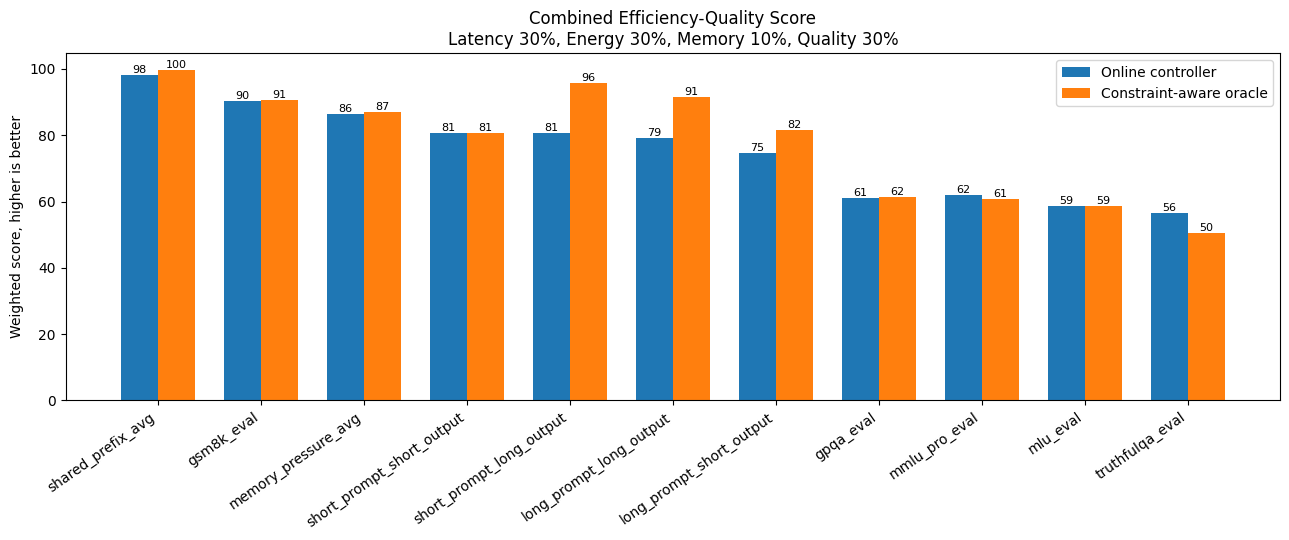

Saved: results/plots/presentation/combined_efficiency_quality_score_soft_quality.png


In [45]:
# ============================================================
# Softer combined weighted score plot
# Online controller vs constraint-aware oracle
# Uses soft quality penalty instead of hard pass/fail
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PRESENTATION_PLOT_DIR = Path("results/plots/presentation")
PRESENTATION_PLOT_DIR.mkdir(parents=True, exist_ok=True)

if "constraint_oracle_all_df" not in globals():
    raise RuntimeError("Run the constraint-aware oracle cell first.")

df = constraint_oracle_all_df.copy()

# ------------------------------------------------------------
# Weights: latency, energy, and quality are almost equal.
# Memory matters, but mainly as a constraint.
# ------------------------------------------------------------

LATENCY_WEIGHT = 0.30
ENERGY_WEIGHT = 0.30
MEMORY_WEIGHT = 0.10
QUALITY_WEIGHT = 0.30

MEMORY_SAFE_RATIO = 1.02

# Quality thresholds
MAX_BENCHMARK_ACCURACY_DROP_PTS = 1.5
BENCHMARK_ZERO_CREDIT_DROP_PTS = 5.0

MAX_SYNTHETIC_REFERENCE_ROUGE_DROP = 0.02
SYNTHETIC_ZERO_CREDIT_DROP = 0.10

MIN_SYNTHETIC_SIMILARITY_TO_FP16 = 0.80
SYNTHETIC_ZERO_CREDIT_SIMILARITY = 0.60


# ------------------------------------------------------------
# Normalize latency and energy
# ------------------------------------------------------------

max_speedup = max(
    df["online_speedup_vs_fp16"].max(),
    df["constraint_oracle_speedup_vs_fp16"].max(),
)

max_energy_reduction = max(
    df["online_energy_reduction_pct"].max(),
    df["constraint_oracle_energy_reduction_pct"].max(),
)

def latency_score(speedup):
    return np.clip(speedup / max_speedup, 0, 1)

def energy_score(energy_reduction_pct):
    return np.clip(energy_reduction_pct / max_energy_reduction, 0, 1)

def memory_score(memory_ratio):
    if pd.isna(memory_ratio):
        return 0.0

    # Full credit if memory is within 2% of FP16.
    if memory_ratio <= MEMORY_SAFE_RATIO:
        return 1.0

    # Soft penalty if memory is slightly above the target.
    return np.clip(1.0 - (memory_ratio - MEMORY_SAFE_RATIO) / 0.05, 0, 1)


def soft_quality_score(quality_type, quality_delta, quality_value):
    """
    Quality is no longer binary.
    A tiny threshold miss should not destroy the full score.
    """

    quality_type = str(quality_type)

    # Benchmark workloads: delta is accuracy points vs FP16.
    if "benchmark" in quality_type:
        if pd.isna(quality_delta):
            return 0.0

        # Full credit if accuracy drop is within allowed threshold.
        if quality_delta >= -MAX_BENCHMARK_ACCURACY_DROP_PTS:
            return 1.0

        # Zero credit only if the accuracy drop is large.
        if quality_delta <= -BENCHMARK_ZERO_CREDIT_DROP_PTS:
            return 0.0

        # Linear partial credit between those two.
        return (
            quality_delta + BENCHMARK_ZERO_CREDIT_DROP_PTS
        ) / (
            BENCHMARK_ZERO_CREDIT_DROP_PTS - MAX_BENCHMARK_ACCURACY_DROP_PTS
        )

    # Synthetic workloads: prefer reference ROUGE delta if available.
    if pd.notna(quality_delta):
        # Full credit if ROUGE drop is within allowed threshold.
        if quality_delta >= -MAX_SYNTHETIC_REFERENCE_ROUGE_DROP:
            return 1.0

        # Zero credit only if the ROUGE drop is large.
        if quality_delta <= -SYNTHETIC_ZERO_CREDIT_DROP:
            return 0.0

        # Linear partial credit between those two.
        return (
            quality_delta + SYNTHETIC_ZERO_CREDIT_DROP
        ) / (
            SYNTHETIC_ZERO_CREDIT_DROP - MAX_SYNTHETIC_REFERENCE_ROUGE_DROP
        )

    # Fallback: use similarity to FP16 if available.
    if pd.notna(quality_value):
        if quality_value >= MIN_SYNTHETIC_SIMILARITY_TO_FP16:
            return 1.0

        if quality_value <= SYNTHETIC_ZERO_CREDIT_SIMILARITY:
            return 0.0

        return (
            quality_value - SYNTHETIC_ZERO_CREDIT_SIMILARITY
        ) / (
            MIN_SYNTHETIC_SIMILARITY_TO_FP16 - SYNTHETIC_ZERO_CREDIT_SIMILARITY
        )

    return 0.0


# ------------------------------------------------------------
# Online controller component scores
# ------------------------------------------------------------

df["online_latency_score"] = df["online_speedup_vs_fp16"].apply(latency_score)
df["online_energy_score"] = df["online_energy_reduction_pct"].apply(energy_score)
df["online_memory_score"] = df["online_memory_ratio_vs_fp16"].apply(memory_score)

df["online_quality_score"] = df.apply(
    lambda row: soft_quality_score(
        row["quality_type"],
        row["online_quality_delta_vs_fp16"],
        row["online_quality_value"],
    ),
    axis=1,
)

df["online_weighted_score"] = 100.0 * (
    LATENCY_WEIGHT * df["online_latency_score"]
    + ENERGY_WEIGHT * df["online_energy_score"]
    + MEMORY_WEIGHT * df["online_memory_score"]
    + QUALITY_WEIGHT * df["online_quality_score"]
)


# ------------------------------------------------------------
# Constraint-aware oracle component scores
# ------------------------------------------------------------

df["oracle_latency_score"] = df["constraint_oracle_speedup_vs_fp16"].apply(latency_score)
df["oracle_energy_score"] = df["constraint_oracle_energy_reduction_pct"].apply(energy_score)
df["oracle_memory_score"] = df["constraint_oracle_memory_ratio_vs_fp16"].apply(memory_score)

df["oracle_quality_score"] = df.apply(
    lambda row: soft_quality_score(
        row["quality_type"],
        row["constraint_oracle_quality_delta_vs_fp16"],
        row["constraint_oracle_quality_value"],
    ),
    axis=1,
)

df["oracle_weighted_score"] = 100.0 * (
    LATENCY_WEIGHT * df["oracle_latency_score"]
    + ENERGY_WEIGHT * df["oracle_energy_score"]
    + MEMORY_WEIGHT * df["oracle_memory_score"]
    + QUALITY_WEIGHT * df["oracle_quality_score"]
)


# ------------------------------------------------------------
# Display table
# ------------------------------------------------------------

score_cols = [
    "workload_name",
    "selected_mode",
    "constraint_oracle_mode",
    "online_weighted_score",
    "oracle_weighted_score",
    "online_speedup_vs_fp16",
    "constraint_oracle_speedup_vs_fp16",
    "online_energy_reduction_pct",
    "constraint_oracle_energy_reduction_pct",
    "online_memory_ratio_vs_fp16",
    "constraint_oracle_memory_ratio_vs_fp16",
    "online_quality_delta_vs_fp16",
    "constraint_oracle_quality_delta_vs_fp16",
    "online_quality_score",
    "oracle_quality_score",
]

display(df[score_cols])

print("Mean online weighted score:", round(df["online_weighted_score"].mean(), 2))
print("Mean oracle weighted score:", round(df["oracle_weighted_score"].mean(), 2))

# Check the problematic row directly
display(
    df[df["workload_name"] == "long_prompt_short_output"][[
        "workload_name",
        "selected_mode",
        "constraint_oracle_mode",
        "online_weighted_score",
        "oracle_weighted_score",
        "online_quality_delta_vs_fp16",
        "online_quality_score",
        "online_speedup_vs_fp16",
        "online_energy_reduction_pct",
        "online_memory_ratio_vs_fp16",
    ]]
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plot_df = df.copy()

x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.bar(
    x - width / 2,
    plot_df["online_weighted_score"],
    width,
    label="Online controller",
)

ax.bar(
    x + width / 2,
    plot_df["oracle_weighted_score"],
    width,
    label="Constraint-aware oracle",
)

ax.set_title(
    "Combined Efficiency-Quality Score\n"
    f"Latency {LATENCY_WEIGHT:.0%}, Energy {ENERGY_WEIGHT:.0%}, "
    f"Memory {MEMORY_WEIGHT:.0%}, Quality {QUALITY_WEIGHT:.0%}"
)
ax.set_ylabel("Weighted score, higher is better")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["workload_name"], rotation=35, ha="right")
ax.legend()

for i, value in enumerate(plot_df["online_weighted_score"]):
    ax.text(i - width / 2, value, f"{value:.0f}", ha="center", va="bottom", fontsize=8)

for i, value in enumerate(plot_df["oracle_weighted_score"]):
    ax.text(i + width / 2, value, f"{value:.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()

save_path = PRESENTATION_PLOT_DIR / "combined_efficiency_quality_score_soft_quality.png"
plt.savefig(save_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", save_path)